<a href="https://colab.research.google.com/github/javmencia/HIVElab/blob/main/PCautoencoderFIXED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CLINICAL EARLY WARNING SYSTEM FOR MORTALITY PREDICTION

1. Loading data...
   Loaded 8121 samples with 101 features

Data summary:
  Total samples: 8121
  Death events (os_event=1): 1098
  Missing VISDAY: 65
  DSDAY available: 1265 non-NA values
CLINICAL EARLY WARNING SYSTEM FOR MORTALITY PREDICTION
Prediction horizon: 90 days
Looking for death events within next 90 days

1. Processing temporal data...
----------------------------------------
Removed 65 rows with missing survival data
Using 'RPT' as patient identifier
Calculating time-to-event for each visit...
Processing 526 patients...
  Processed 0/526 patients...
  Processed 200/526 patients...
  Processed 400/526 patients...
Processed 8056 visits from 526 patients
Patients with event: 76
Patients without event: 450
Visits with future event: 0

2. Selecting and preparing features...
----------------------------------------
Found 35 available features out of 56 possible
Preparing features...
Using 35 available features
Processing 34

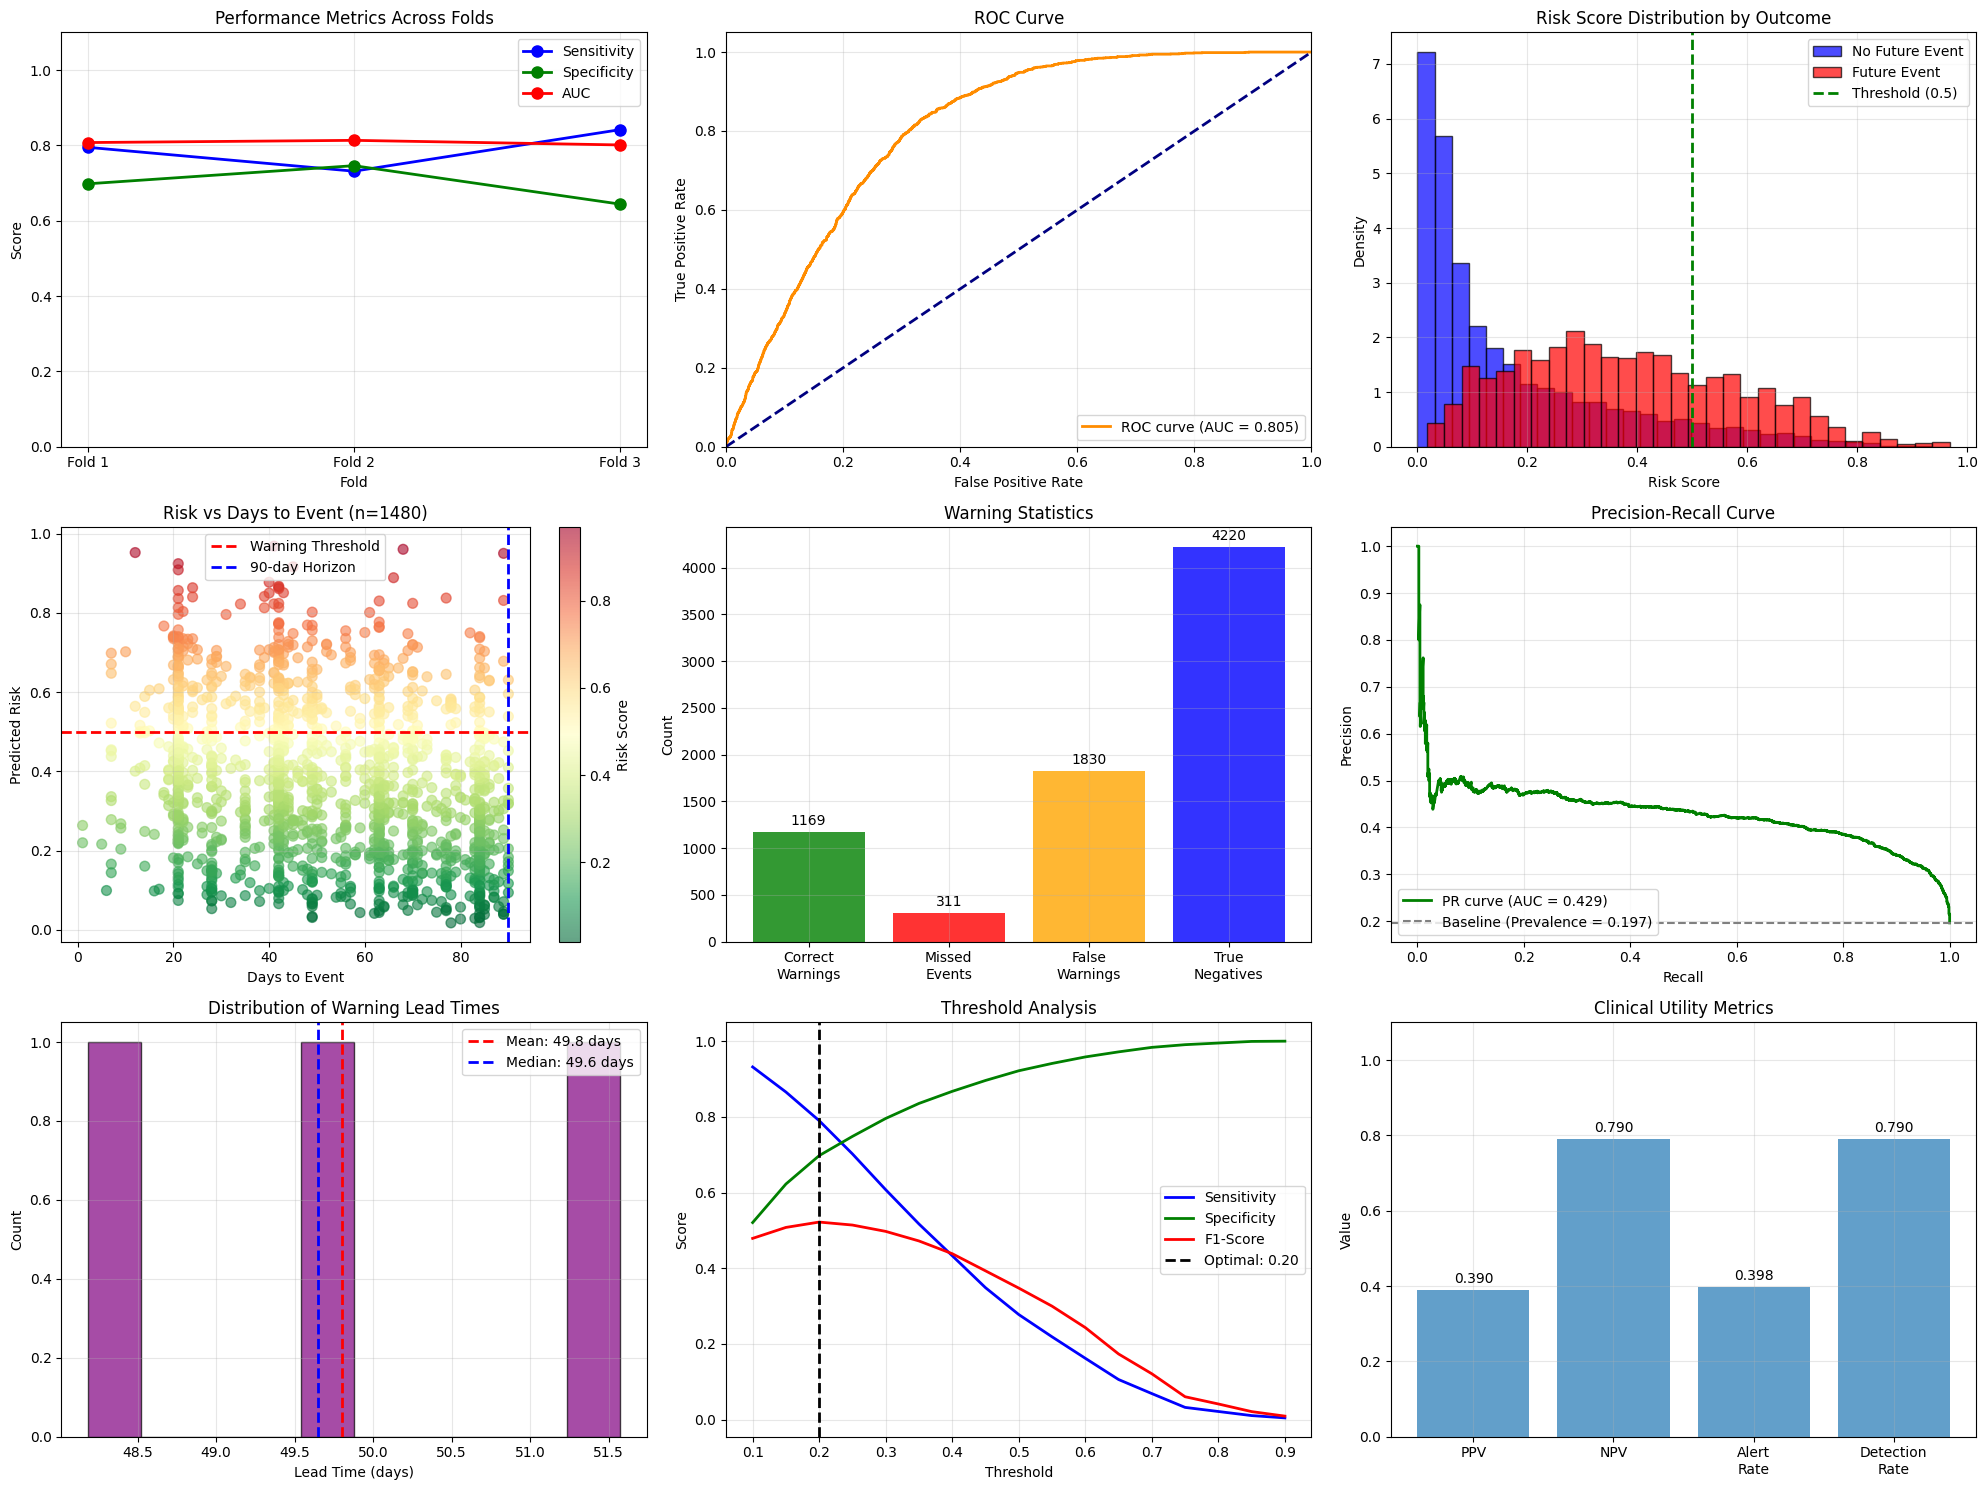


CLINICAL EARLY WARNING SYSTEM COMPLETED!

CLINICAL IMPLICATIONS:
--------------------------------------------------
1. System predicts death within next 90 days
2. Risk scores range from 0 (low risk) to 1 (high risk)
3. Threshold of 0.5 typically used for warnings
4. Lead time = days between warning and actual event

Based on your data:
- 1098 patients died during follow-up
- System trained on 7530 patient sequences
- Prediction horizon: 90 days


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve, accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings('ignore')

class RobustTimeAwareDataProcessor:
    def __init__(self):
        self.scaler = StandardScaler()
        self.label_encoders = {}

    def clean_data(self, df):
        """Clean data by handling infinity, large values, and missing data"""
        df_clean = df.copy()

        # Replace infinity with NaN
        df_clean = df_clean.replace([np.inf, -np.inf], np.nan)

        # Handle extremely large values by capping at 99th percentile
        numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
        for col in numeric_cols:
            if df_clean[col].notna().any():
                # Cap at 99th percentile
                p99 = df_clean[col].quantile(0.99)
                if not np.isnan(p99):
                    df_clean[col] = df_clean[col].clip(upper=p99 * 10)  # Allow some margin

        return df_clean

    def process_patient_data(self, df):
        """Process data with proper temporal structure"""
        # Clean data first
        df_clean = self.clean_data(df)

        # Handle missing survival data
        missing_before = len(df_clean)
        df_clean = df_clean.dropna(subset=['VISDAY', 'os_event'])
        missing_after = len(df_clean)
        print(f"Removed {missing_before - missing_after} rows with missing survival data")

        # Create patient IDs if not present
        if 'patient_id' not in df_clean.columns:
            # Try to find a patient identifier column
            possible_id_cols = ['RPT', 'SUBJID', 'PATIENT', 'patient', 'id', 'ID']
            found_id = False
            for col in possible_id_cols:
                if col in df_clean.columns:
                    df_clean['patient_id'] = df_clean[col]
                    print(f"Using '{col}' as patient identifier")
                    found_id = True
                    break

            if not found_id:
                # Create synthetic patient IDs (assuming ~5 visits per patient)
                df_clean['patient_id'] = np.arange(len(df_clean)) // 5
                print("Created synthetic patient IDs (5 visits per patient)")

        # Sort by patient and visit day
        df_sorted = df_clean.sort_values(['patient_id', 'VISDAY']).reset_index(drop=True)

        # Calculate time to event for each visit
        print("Calculating time-to-event for each visit...")
        df_sorted['time_to_event'] = np.nan
        df_sorted['is_future_event'] = 0

        unique_patients = df_sorted['patient_id'].unique()
        print(f"Processing {len(unique_patients)} patients...")

        for i, pid in enumerate(unique_patients):
            if i % 200 == 0:
                print(f"  Processed {i}/{len(unique_patients)} patients...")

            patient_data = df_sorted[df_sorted['patient_id'] == pid]

            # Check if patient died (os_event = 1)
            patient_events = patient_data['os_event'].values
            if np.any(patient_events == 1):
                # Patient died - find death day
                death_idx = np.where(patient_events == 1)[0]
                if len(death_idx) > 0:
                    death_day = patient_data.iloc[death_idx[0]]['VISDAY']

                    # For all visits before death, calculate days to death
                    for idx, row in patient_data.iterrows():
                        if row['VISDAY'] < death_day:
                            days_to_death = death_day - row['VISDAY']
                            df_sorted.at[idx, 'time_to_event'] = days_to_death
                            df_sorted.at[idx, 'is_future_event'] = 1
                        elif row['VISDAY'] == death_day:
                            # Death visit itself
                            df_sorted.at[idx, 'time_to_event'] = 0
                            df_sorted.at[idx, 'is_future_event'] = 0  # Not a future event
            else:
                # Patient survived - use maximum follow-up time
                last_visit_day = patient_data['VISDAY'].max()

                for idx, row in patient_data.iterrows():
                    days_from_last = last_visit_day - row['VISDAY']
                    df_sorted.at[idx, 'time_to_event'] = days_from_last
                    df_sorted.at[idx, 'is_future_event'] = 0

        # Handle any remaining NaN values in time_to_event
        nan_count = df_sorted['time_to_event'].isna().sum()
        if nan_count > 0:
            print(f"Warning: {nan_count} NaN values in time_to_event, filling with median")
            median_ttd = df_sorted['time_to_event'].median()
            df_sorted['time_to_event'] = df_sorted['time_to_event'].fillna(median_ttd)

        print(f"Processed {len(df_sorted)} visits from {len(unique_patients)} patients")

        # Count patients with events
        event_patients = df_sorted[df_sorted['os_event'] == 1]['patient_id'].unique()
        no_event_patients = df_sorted[df_sorted['os_event'] == 0]['patient_id'].unique()

        print(f"Patients with event: {len(event_patients)}")
        print(f"Patients without event: {len(no_event_patients)}")
        print(f"Visits with future event: {df_sorted['is_future_event'].sum()}")

        return df_sorted

    def create_temporal_sequences(self, df, feature_cols, max_sequence_length=5, prediction_horizon=90):
        """Create sequences with proper temporal structure"""
        print("Creating temporal sequences...")
        sequences = []
        labels = []
        time_intervals = []
        patient_ids = []
        days_to_event_list = []

        unique_patients = df['patient_id'].unique()

        for pid in unique_patients:
            patient_data = df[df['patient_id'] == pid].sort_values('VISDAY')

            if len(patient_data) < 2:
                continue  # Need at least 2 visits

            # Get features and temporal data
            patient_features = patient_data[feature_cols].values
            patient_visdays = patient_data['VISDAY'].values
            patient_time_to_event = patient_data['time_to_event'].values
            patient_has_event = patient_data['is_future_event'].values

            # Create sequences
            for i in range(1, len(patient_data)):  # Start from 1 to have at least one previous visit
                # Determine sequence length (up to max_sequence_length)
                seq_len = min(i, max_sequence_length)
                start_idx = i - seq_len

                # Get sequence data
                seq_features = patient_features[start_idx:i+1]  # Including current visit
                seq_visdays = patient_visdays[start_idx:i+1]

                # Calculate time intervals between visits (in days)
                if len(seq_visdays) > 1:
                    time_diffs = np.diff(seq_visdays)
                    # Add a default 30-day interval for the first gap
                    time_diffs = np.concatenate([[30], time_diffs])
                else:
                    time_diffs = np.array([30])

                # Normalize time intervals (divide by 30 to get approximate months)
                time_diffs_normalized = time_diffs / 30.0

                # Create label: will event occur within prediction horizon?
                current_time_to_event = patient_time_to_event[i]
                if current_time_to_event <= prediction_horizon and current_time_to_event > 0:
                    label = 1  # Event will occur within horizon
                else:
                    label = 0  # No event within horizon

                # Pad sequence if needed
                if seq_len < max_sequence_length:
                    pad_len = max_sequence_length - seq_len
                    seq_features = np.pad(seq_features, ((pad_len, 0), (0, 0)), mode='constant')
                    time_diffs_normalized = np.pad(time_diffs_normalized, (pad_len, 0),
                                                  mode='constant', constant_values=1.0)  # 1 month for padding

                sequences.append(seq_features)
                labels.append(label)
                time_intervals.append(time_diffs_normalized)
                patient_ids.append(pid)
                days_to_event_list.append(current_time_to_event)

        sequences = np.array(sequences)
        labels = np.array(labels)
        time_intervals = np.array(time_intervals)
        patient_ids = np.array(patient_ids)

        print(f"\nCreated {len(sequences)} sequences")
        print(f"Positive sequences (event within {prediction_horizon} days): {np.sum(labels == 1)} ({np.mean(labels == 1)*100:.1f}%)")
        print(f"Negative sequences: {np.sum(labels == 0)}")

        # Analyze positive sequences
        if np.sum(labels == 1) > 0:
            positive_days = np.array(days_to_event_list)[labels == 1]
            print(f"Days to event for positive sequences:")
            print(f"  Mean: {np.mean(positive_days):.1f} days")
            print(f"  Median: {np.median(positive_days):.1f} days")
            print(f"  Range: {np.min(positive_days):.1f} to {np.max(positive_days):.1f} days")

        return sequences, labels, time_intervals, patient_ids, days_to_event_list

    def prepare_features(self, df, feature_names):
        """Prepare features for modeling with robust handling"""
        print("Preparing features...")

        # Select features that exist in dataframe
        available_features = [f for f in feature_names if f in df.columns]
        print(f"Using {len(available_features)} available features")

        # Handle missing values
        df_filled = df[available_features].copy()

        # Replace any remaining infinity values
        df_filled = df_filled.replace([np.inf, -np.inf], np.nan)

        # Fill numeric missing values with median
        numeric_cols = df_filled.select_dtypes(include=[np.number]).columns
        print(f"Processing {len(numeric_cols)} numeric columns...")

        for col in numeric_cols:
            if df_filled[col].isnull().any():
                median_val = df_filled[col].median()
                if pd.isna(median_val):
                    median_val = 0  # Fallback
                df_filled[col] = df_filled[col].fillna(median_val)

        # Fill categorical missing values with mode
        categorical_cols = df_filled.select_dtypes(exclude=[np.number]).columns
        print(f"Processing {len(categorical_cols)} categorical columns...")

        for col in categorical_cols:
            if df_filled[col].isnull().any():
                mode_val = df_filled[col].mode()
                if len(mode_val) > 0:
                    df_filled[col] = df_filled[col].fillna(mode_val[0])
                else:
                    df_filled[col] = df_filled[col].fillna('missing')

        # Encode categorical variables
        print("Encoding categorical variables...")
        for col in categorical_cols:
            try:
                if col not in self.label_encoders:
                    self.label_encoders[col] = LabelEncoder()
                    # Handle any non-string values
                    col_data = df_filled[col].astype(str)
                    self.label_encoders[col].fit(col_data)

                df_filled[col] = self.label_encoders[col].transform(df_filled[col].astype(str))
            except Exception as e:
                print(f"Warning: Could not encode column {col}: {e}")
                # Drop problematic column
                df_filled = df_filled.drop(columns=[col])
                available_features.remove(col)

        # Scale numeric features
        if len(numeric_cols) > 0:
            print("Scaling numeric features...")
            # Check for any remaining issues
            numeric_data = df_filled[numeric_cols].values
            if np.any(np.isnan(numeric_data)) or np.any(np.isinf(numeric_data)):
                print("Warning: NaN or Inf found in numeric data after cleaning")
                # Replace with zeros as last resort
                numeric_data = np.nan_to_num(numeric_data, nan=0.0, posinf=1e6, neginf=-1e6)
                df_filled[numeric_cols] = numeric_data

            try:
                df_filled[numeric_cols] = self.scaler.fit_transform(df_filled[numeric_cols])
            except Exception as e:
                print(f"Warning: Could not scale features: {e}")
                # Use min-max scaling as fallback
                for col in numeric_cols:
                    col_min = df_filled[col].min()
                    col_max = df_filled[col].max()
                    if col_max > col_min:
                        df_filled[col] = (df_filled[col] - col_min) / (col_max - col_min)
                    else:
                        df_filled[col] = 0

        print(f"Final feature matrix shape: {df_filled.shape}")
        return df_filled.values, available_features


class TimeAwareEarlyWarningModel:
    def __init__(self, input_dim, sequence_length=5, lstm_units=64):
        self.input_dim = input_dim
        self.sequence_length = sequence_length
        self.lstm_units = lstm_units
        self.model = None
        self.history = None

    def build_model_with_time_awareness(self):
        """Build model that incorporates time intervals between visits"""
        # Two input layers: features and time intervals
        feature_input = layers.Input(shape=(self.sequence_length, self.input_dim), name='features')
        time_input = layers.Input(shape=(self.sequence_length, 1), name='time_intervals')

        # Process time intervals
        time_processed = layers.Dense(8, activation='relu')(time_input)
        time_processed = layers.Dense(16, activation='relu')(time_processed)

        # Concatenate features with time information
        combined = layers.Concatenate(axis=-1)([feature_input, time_processed])

        # LSTM layers
        lstm_out = layers.Bidirectional(layers.LSTM(self.lstm_units, return_sequences=True))(combined)
        lstm_out = layers.Dropout(0.3)(lstm_out)

        # Simple attention mechanism
        attention_scores = layers.TimeDistributed(layers.Dense(1, activation='tanh'))(lstm_out)
        attention_weights = layers.Softmax(axis=1)(attention_scores)
        context_vector = layers.Multiply()([lstm_out, attention_weights])

        # Global average pooling instead of just last time step
        pooled = layers.GlobalAveragePooling1D()(context_vector)

        # Dense layers
        dense1 = layers.Dense(64, activation='relu')(pooled)
        dense1 = layers.BatchNormalization()(dense1)
        dense1 = layers.Dropout(0.3)(dense1)

        dense2 = layers.Dense(32, activation='relu')(dense1)
        dense2 = layers.BatchNormalization()(dense2)
        dense2 = layers.Dropout(0.2)(dense2)

        # Output: risk of event within prediction horizon
        risk_score = layers.Dense(1, activation='sigmoid', name='risk_score')(dense2)

        # Create model
        self.model = models.Model(inputs=[feature_input, time_input], outputs=risk_score)

        return self.model

    def compile_model(self, learning_rate=0.001):
        """Compile the model"""
        self.model.compile(
            optimizer=Adam(learning_rate=learning_rate),
            loss='binary_crossentropy',
            metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
                    tf.keras.metrics.Precision(name='precision'),
                    tf.keras.metrics.Recall(name='recall')]
        )

        return self.model

    def train(self, X_features, X_time, y_train, val_data=None, epochs=100, batch_size=32, class_weight=None):
        """Train the model"""
        early_stopping = callbacks.EarlyStopping(
            monitor='val_loss' if val_data else 'loss',
            patience=15,
            restore_best_weights=True,
            min_delta=0.001,
            verbose=0
        )

        reduce_lr = callbacks.ReduceLROnPlateau(
            monitor='val_loss' if val_data else 'loss',
            factor=0.5,
            patience=8,
            min_lr=1e-6,
            verbose=0
        )

        callbacks_list = [early_stopping, reduce_lr]

        if val_data:
            X_val_features, X_val_time, y_val = val_data
            validation_data = ([X_val_features, X_val_time], y_val)
        else:
            validation_data = None

        self.history = self.model.fit(
            [X_features, X_time], y_train,
            validation_data=validation_data,
            epochs=epochs,
            batch_size=batch_size,
            callbacks=callbacks_list,
            verbose=0,
            class_weight=class_weight
        )

        return self.history

    def predict(self, X_features, X_time):
        """Make predictions"""
        return self.model.predict([X_features, X_time], verbose=0).flatten()


class ClinicalEarlyWarningPipeline:
    def __init__(self, prediction_horizon_days=90, n_splits=3, random_state=42):
        self.prediction_horizon = prediction_horizon_days
        self.n_splits = n_splits
        self.random_state = random_state
        self.data_processor = RobustTimeAwareDataProcessor()
        self.results = {}

    def select_clinical_features(self, df):
        """Select relevant clinical features for early warning"""
        # Common clinical features for mortality prediction
        base_features = [
            'AGE', 'SEX', 'RACE',  # Demographics
            'BMI', 'WEIGHT', 'HEIGHT',  # Anthropometrics
            'ECOG', 'KPS',  # Performance status
        ]

        # Lab values (if available)
        lab_features = [
            'ALB', 'ALP', 'ALT', 'AST', 'BILI', 'CALCIUM', 'CREAT', 'HGB',
            'LYMPH', 'NEUT', 'PLAT', 'WBC', 'SODIUM', 'POTASSIUM', 'GLUCOSE',
            'BUN', 'CRP', 'LDH'
        ]

        # Treatment and AE features from your data
        treatment_features = [
            'cycle_number', 'total_cycles', 'anytarget', 'anynontarget',
            'total_ae_events', 'serious_ae_count', 'grade3_plus_count',
            'any_grade3_plus', 'treatment_related_count', 'any_treatment_related',
            'grade1_count', 'grade2_count', 'grade3_count', 'grade4_count',
            'drug_interrupted', 'drug_reduced', 'drug_withdrawn', 'drug_not_changed',
            'other_drug_interrupted', 'other_drug_reduced', 'other_drug_withdrawn',
            'concomitant_treatment_given', 'cum_any_grade3_plus',
            'cum_any_treatment_related', 'cum_drug_withdrawn',
            'cum_other_drug_withdrawn', 'cum_concomitant_treatment',
            'ongoing_ae_count', 'mean_ae_duration', 'max_ae_duration'
        ]

        # Combine and check availability
        all_possible = base_features + lab_features + treatment_features
        available_features = [f for f in all_possible if f in df.columns]

        print(f"Found {len(available_features)} available features out of {len(all_possible)} possible")

        # If we have very few features, use some defaults
        if len(available_features) < 10:
            print("Warning: Few features available, using basic set")
            # Try to find any numeric columns
            numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
            # Exclude ID and date columns
            exclude_cols = ['VISDAY', 'DSDAY', 'patient_id', 'id', 'index', 'time_to_event', 'is_future_event']
            numeric_cols = [c for c in numeric_cols if c not in exclude_cols]
            available_features = numeric_cols[:20]  # Take first 20 numeric columns

        return available_features

    def run_pipeline(self, pcdata):
        """Run the complete early warning pipeline"""
        print("="*70)
        print("CLINICAL EARLY WARNING SYSTEM FOR MORTALITY PREDICTION")
        print("="*70)
        print(f"Prediction horizon: {self.prediction_horizon} days")
        print(f"Looking for death events within next {self.prediction_horizon} days")

        # Step 1: Process data with temporal structure
        print("\n1. Processing temporal data...")
        print("-"*40)

        df_processed = self.data_processor.process_patient_data(pcdata)

        # Step 2: Prepare features
        print("\n2. Selecting and preparing features...")
        print("-"*40)

        feature_names = self.select_clinical_features(df_processed)
        X_features, selected_features = self.data_processor.prepare_features(df_processed, feature_names)

        # Add processed features back to dataframe
        feature_cols = [f'feat_{i}' for i in range(X_features.shape[1])]
        for i in range(X_features.shape[1]):
            df_processed[f'feat_{i}'] = X_features[:, i]

        print(f"Using {len(feature_cols)} processed features")

        # Step 3: Create temporal sequences
        print("\n3. Creating temporal sequences...")
        print("-"*40)

        sequences, labels, time_intervals, patient_ids, days_to_event = self.data_processor.create_temporal_sequences(
            df_processed, feature_cols, max_sequence_length=5,
            prediction_horizon=self.prediction_horizon
        )

        if len(sequences) == 0:
            print("Error: No sequences created!")
            return None

        print(f"Sequence shape: {sequences.shape}")
        print(f"Time intervals shape: {time_intervals.shape}")
        print(f"Patient IDs type: {type(patient_ids)}, shape: {patient_ids.shape}")

        # Step 4: Analyze data balance
        print("\n4. Analyzing data balance...")
        print("-"*40)

        positive_rate = np.mean(labels == 1)
        print(f"Positive rate (event within {self.prediction_horizon} days): {positive_rate:.3f}")

        if positive_rate < 0.01:
            print("Warning: Very low positive rate, model may struggle to learn")
            print("Consider increasing prediction horizon or using different labeling")

        # Step 5: Cross-validation
        print("\n5. Running cross-validation...")
        print("-"*40)

        # Create patient-level splits
        unique_patients = np.unique(patient_ids)
        print(f"Unique patients in sequences: {len(unique_patients)}")

        # Get patient labels (max label across their sequences)
        patient_labels = []
        patient_days_to_event = []

        for pid in unique_patients:
            patient_mask = patient_ids == pid
            patient_label = np.max(labels[patient_mask])  # Patient has event if any sequence does
            patient_labels.append(patient_label)

            # Get min days to event for this patient
            if np.any(labels[patient_mask] == 1):
                min_days = np.min(np.array(days_to_event)[patient_mask])
                patient_days_to_event.append(min_days)

        patient_labels = np.array(patient_labels)

        print(f"Patients with future event in sequences: {np.sum(patient_labels == 1)}")
        print(f"Patients without future event in sequences: {np.sum(patient_labels == 0)}")

        if np.sum(patient_labels == 1) < 2:
            print(f"Error: Only {np.sum(patient_labels == 1)} patients with events")
            print("Cannot perform cross-validation. Using simple train/test split instead.")
            return self.run_simple_split(sequences, labels, time_intervals, patient_ids, days_to_event)

        n_folds = min(self.n_splits, np.sum(patient_labels == 1))
        if n_folds < self.n_splits:
            print(f"Reducing CV folds to {n_folds} (only {np.sum(patient_labels == 1)} patients with events)")

        skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=self.random_state)

        cv_results = {
            'fold': [],
            'sensitivity': [], 'specificity': [], 'auc': [],
            'precision': [], 'recall': [], 'f1': [],
            'lead_times': [], 'warning_stats': [],
            'risk_scores': [], 'true_labels': [],
            'days_to_event': []
        }

        fold = 1
        for train_patient_idx, test_patient_idx in skf.split(unique_patients, patient_labels):
            print(f"\n{'='*60}")
            print(f"FOLD {fold}/{n_folds}")
            print(f"{'='*60}")

            # Get patient IDs for train/test
            train_patient_ids = unique_patients[train_patient_idx]
            test_patient_ids = unique_patients[test_patient_idx]

            print(f"Training patients: {len(train_patient_ids)}")
            print(f"Test patients: {len(test_patient_ids)}")

            # Create masks
            train_mask = np.isin(patient_ids, train_patient_ids)
            test_mask = np.isin(patient_ids, test_patient_ids)

            # Split data
            X_train_seq = sequences[train_mask]
            X_test_seq = sequences[test_mask]

            X_train_time = time_intervals[train_mask]
            X_test_time = time_intervals[test_mask]

            y_train = labels[train_mask]
            y_test = labels[test_mask]

            test_days_to_event = np.array(days_to_event)[test_mask]

            train_pids = patient_ids[train_mask]

            # Split training for validation
            unique_train_pids = np.unique(train_pids)
            val_patient_count = max(1, int(0.2 * len(unique_train_pids)))
            val_patient_ids = np.random.choice(unique_train_pids, val_patient_count, replace=False)
            val_mask = np.isin(train_pids, val_patient_ids)

            X_val_seq = X_train_seq[val_mask]
            X_val_time = X_train_time[val_mask]
            y_val = y_train[val_mask]

            X_train_seq_final = X_train_seq[~val_mask]
            X_train_time_final = X_train_time[~val_mask]
            y_train_final = y_train[~val_mask]

            print(f"Training sequences: {X_train_seq_final.shape[0]} (pos: {np.mean(y_train_final):.3f})")
            print(f"Validation sequences: {X_val_seq.shape[0]} (pos: {np.mean(y_val):.3f})")
            print(f"Test sequences: {X_test_seq.shape[0]} (pos: {np.mean(y_test):.3f})")

            # Handle class imbalance
            if np.sum(y_train_final) > 0:
                pos_weight = len(y_train_final) / (2 * np.sum(y_train_final))
                class_weight = {0: 1.0, 1: min(10.0, pos_weight)}  # Cap at 10x
            else:
                class_weight = {0: 1.0, 1: 1.0}

            # Step 6: Train model
            print("\n6. Training time-aware early warning model...")

            model = TimeAwareEarlyWarningModel(
                input_dim=X_train_seq_final.shape[2],
                sequence_length=X_train_seq_final.shape[1],
                lstm_units=32  # Reduced for stability
            )

            model.build_model_with_time_awareness()
            model.compile_model(learning_rate=0.001)

            try:
                history = model.train(
                    X_train_seq_final, X_train_time_final, y_train_final,
                    val_data=(X_val_seq, X_val_time, y_val),
                    epochs=50,  # Reduced for speed
                    batch_size=32,
                    class_weight=class_weight
                )

                # Check training history
                if history and 'loss' in history.history:
                    final_train_loss = history.history['loss'][-1]
                    final_val_loss = history.history.get('val_loss', [final_train_loss])[-1]
                    print(f"Final training loss: {final_train_loss:.4f}, validation loss: {final_val_loss:.4f}")
                else:
                    print("Warning: Training history not available")
                    final_train_loss = 0.5
                    final_val_loss = 0.5

            except Exception as e:
                print(f"Warning: Training failed: {e}")
                print("Skipping this fold...")
                fold += 1
                continue

            # Step 7: Evaluate
            print("\n7. Evaluating early warnings...")

            # Get predictions
            try:
                train_pred = model.predict(X_train_seq_final, X_train_time_final)
                test_pred = model.predict(X_test_seq, X_test_time)
            except Exception as e:
                print(f"Warning: Prediction failed: {e}")
                fold += 1
                continue

            # Find optimal threshold (maximizing F1 score)
            thresholds = np.linspace(0.1, 0.9, 17)
            best_f1 = 0
            best_threshold = 0.5

            for thresh in thresholds:
                pred_binary = (test_pred > thresh).astype(int)
                if np.sum(pred_binary) > 0 and np.sum(y_test) > 0:
                    try:
                        f1 = f1_score(y_test, pred_binary, zero_division=0)
                        if f1 > best_f1:
                            best_f1 = f1
                            best_threshold = thresh
                    except:
                        continue

            print(f"Optimal threshold: {best_threshold:.3f} (F1: {best_f1:.3f})")

            # Calculate metrics
            test_pred_binary = (test_pred > best_threshold).astype(int)

            # Handle cases with no predictions
            if np.sum(test_pred_binary) == 0:
                print("Warning: No positive predictions at this threshold")
                accuracy = accuracy_score(y_test, test_pred_binary)
                auc_score = 0.5
                precision = 0
                recall = 0
                f1 = 0
                tn = np.sum(y_test == 0)
                fp = 0
                fn = np.sum(y_test == 1)
                tp = 0
            elif np.sum(y_test) == 0:
                print("Warning: No positive cases in test set")
                accuracy = accuracy_score(y_test, test_pred_binary)
                auc_score = 0.5
                precision = 0
                recall = 0
                f1 = 0
                tn = np.sum((y_test == 0) & (test_pred_binary == 0))
                fp = np.sum((y_test == 0) & (test_pred_binary == 1))
                fn = 0
                tp = 0
            else:
                accuracy = accuracy_score(y_test, test_pred_binary)
                try:
                    auc_score = roc_auc_score(y_test, test_pred)
                except:
                    auc_score = 0.5
                precision = precision_score(y_test, test_pred_binary, zero_division=0)
                recall = recall_score(y_test, test_pred_binary, zero_division=0)
                f1 = f1_score(y_test, test_pred_binary, zero_division=0)

                # Calculate confusion matrix
                try:
                    cm = confusion_matrix(y_test, test_pred_binary)
                    if cm.shape == (2, 2):
                        tn, fp, fn, tp = cm.ravel()
                    else:
                        # Handle case where only one class predicted
                        tn = np.sum((y_test == 0) & (test_pred_binary == 0))
                        fp = np.sum((y_test == 0) & (test_pred_binary == 1))
                        fn = np.sum((y_test == 1) & (test_pred_binary == 0))
                        tp = np.sum((y_test == 1) & (test_pred_binary == 1))
                except:
                    tn = np.sum((y_test == 0) & (test_pred_binary == 0))
                    fp = np.sum((y_test == 0) & (test_pred_binary == 1))
                    fn = np.sum((y_test == 1) & (test_pred_binary == 0))
                    tp = np.sum((y_test == 1) & (test_pred_binary == 1))

            sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

            print(f"\nFold {fold} Results:")
            print(f"  Accuracy: {accuracy:.4f}")
            print(f"  AUC: {auc_score:.4f}")
            print(f"  Sensitivity: {sensitivity:.4f}")
            print(f"  Specificity: {specificity:.4f}")
            print(f"  Precision: {precision:.4f}")
            print(f"  Recall: {recall:.4f}")
            print(f"  F1-Score: {f1:.4f}")
            print(f"  TP: {tp}, FP: {fp}, FN: {fn}, TN: {tn}")

            # Store results
            cv_results['fold'].append(fold)
            cv_results['sensitivity'].append(sensitivity)
            cv_results['specificity'].append(specificity)
            cv_results['auc'].append(auc_score)
            cv_results['precision'].append(precision)
            cv_results['recall'].append(recall)
            cv_results['f1'].append(f1)
            cv_results['risk_scores'].extend(test_pred.tolist())
            cv_results['true_labels'].extend(y_test.tolist())
            cv_results['days_to_event'].extend(test_days_to_event.tolist())

            # Calculate lead times for correctly warned patients
            if tp > 0:
                # For TP cases, get actual days to event
                tp_mask = (y_test == 1) & (test_pred_binary == 1)
                if np.any(tp_mask):
                    tp_days = test_days_to_event[tp_mask]
                    avg_lead_time = np.mean(tp_days)
                    cv_results['lead_times'].append(avg_lead_time)

                    warning_stats = {
                        'correct_warnings': int(tp),
                        'missed_warnings': int(fn),
                        'false_warnings': int(fp),
                        'true_negatives': int(tn),
                        'avg_lead_time': float(avg_lead_time)
                    }
                else:
                    warning_stats = {
                        'correct_warnings': int(tp),
                        'missed_warnings': int(fn),
                        'false_warnings': int(fp),
                        'true_negatives': int(tn),
                        'avg_lead_time': 0.0
                    }
                cv_results['warning_stats'].append(warning_stats)

            fold += 1

        self.results = cv_results

        if not cv_results['fold']:
            print("\nERROR: No folds completed successfully!")
            print("Trying simple train/test split instead...")
            return self.run_simple_split(sequences, labels, time_intervals, patient_ids, days_to_event)

        # Step 8: Analyze results
        print("\n" + "="*70)
        print("COMPREHENSIVE EARLY WARNING ANALYSIS")
        print("="*70)

        self.analyze_results(cv_results)
        self.visualize_results(cv_results)

        return cv_results

    def run_simple_split(self, sequences, labels, time_intervals, patient_ids, days_to_event):
        """Run a simple train/test split when cross-validation fails"""
        print("\nRunning simple train/test split...")

        # Simple split by sequences (not patients)
        n_samples = len(sequences)
        indices = np.arange(n_samples)
        np.random.shuffle(indices)

        split_idx = int(0.8 * n_samples)
        train_idx = indices[:split_idx]
        test_idx = indices[split_idx:]

        X_train_seq = sequences[train_idx]
        X_test_seq = sequences[test_idx]

        X_train_time = time_intervals[train_idx]
        X_test_time = time_intervals[test_idx]

        y_train = labels[train_idx]
        y_test = labels[test_idx]

        test_days_to_event = days_to_event[test_idx]

        # Split training for validation
        val_size = int(0.2 * len(train_idx))
        X_val_seq = X_train_seq[:val_size]
        X_val_time = X_train_time[:val_size]
        y_val = y_train[:val_size]

        X_train_seq_final = X_train_seq[val_size:]
        X_train_time_final = X_train_time[val_size:]
        y_train_final = y_train[val_size:]

        print(f"Training sequences: {X_train_seq_final.shape[0]} (pos: {np.mean(y_train_final):.3f})")
        print(f"Validation sequences: {X_val_seq.shape[0]} (pos: {np.mean(y_val):.3f})")
        print(f"Test sequences: {X_test_seq.shape[0]} (pos: {np.mean(y_test):.3f})")

        # Handle class imbalance
        if np.sum(y_train_final) > 0:
            pos_weight = len(y_train_final) / (2 * np.sum(y_train_final))
            class_weight = {0: 1.0, 1: min(10.0, pos_weight)}  # Cap at 10x
        else:
            class_weight = {0: 1.0, 1: 1.0}

        # Train model
        print("\nTraining time-aware early warning model...")

        model = TimeAwareEarlyWarningModel(
            input_dim=X_train_seq_final.shape[2],
            sequence_length=X_train_seq_final.shape[1],
            lstm_units=32
        )

        model.build_model_with_time_awareness()
        model.compile_model(learning_rate=0.001)

        try:
            history = model.train(
                X_train_seq_final, X_train_time_final, y_train_final,
                val_data=(X_val_seq, X_val_time, y_val),
                epochs=50,
                batch_size=32,
                class_weight=class_weight
            )

            print("Training completed successfully")
        except Exception as e:
            print(f"Warning: Training failed: {e}")
            return None

        # Evaluate
        print("\nEvaluating early warnings...")

        # Get predictions
        try:
            test_pred = model.predict(X_test_seq, X_test_time)
        except Exception as e:
            print(f"Warning: Prediction failed: {e}")
            return None

        # Find optimal threshold
        thresholds = np.linspace(0.1, 0.9, 17)
        best_f1 = 0
        best_threshold = 0.5

        for thresh in thresholds:
            pred_binary = (test_pred > thresh).astype(int)
            if np.sum(pred_binary) > 0 and np.sum(y_test) > 0:
                try:
                    f1 = f1_score(y_test, pred_binary, zero_division=0)
                    if f1 > best_f1:
                        best_f1 = f1
                        best_threshold = thresh
                except:
                    continue

        print(f"Optimal threshold: {best_threshold:.3f} (F1: {best_f1:.3f})")

        # Calculate metrics
        test_pred_binary = (test_pred > best_threshold).astype(int)

        if np.sum(test_pred_binary) == 0 or np.sum(y_test) == 0:
            print("Warning: Insufficient predictions or true labels")
            return None

        accuracy = accuracy_score(y_test, test_pred_binary)
        try:
            auc_score = roc_auc_score(y_test, test_pred)
        except:
            auc_score = 0.5
        precision = precision_score(y_test, test_pred_binary, zero_division=0)
        recall = recall_score(y_test, test_pred_binary, zero_division=0)
        f1 = f1_score(y_test, test_pred_binary, zero_division=0)

        # Calculate confusion matrix
        cm = confusion_matrix(y_test, test_pred_binary)
        if cm.shape == (2, 2):
            tn, fp, fn, tp = cm.ravel()
        else:
            tn = np.sum((y_test == 0) & (test_pred_binary == 0))
            fp = np.sum((y_test == 0) & (test_pred_binary == 1))
            fn = np.sum((y_test == 1) & (test_pred_binary == 0))
            tp = np.sum((y_test == 1) & (test_pred_binary == 1))

        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

        print(f"\nTest Results:")
        print(f"  Accuracy: {accuracy:.4f}")
        print(f"  AUC: {auc_score:.4f}")
        print(f"  Sensitivity: {sensitivity:.4f}")
        print(f"  Specificity: {specificity:.4f}")
        print(f"  Precision: {precision:.4f}")
        print(f"  Recall: {recall:.4f}")
        print(f"  F1-Score: {f1:.4f}")
        print(f"  TP: {tp}, FP: {fp}, FN: {fn}, TN: {tn}")

        # Create results structure
        results = {
            'fold': [1],
            'sensitivity': [sensitivity],
            'specificity': [specificity],
            'auc': [auc_score],
            'precision': [precision],
            'recall': [recall],
            'f1': [f1],
            'risk_scores': test_pred.tolist(),
            'true_labels': y_test.tolist(),
            'days_to_event': test_days_to_event.tolist(),
            'warning_stats': [{
                'correct_warnings': int(tp),
                'missed_warnings': int(fn),
                'false_warnings': int(fp),
                'true_negatives': int(tn),
                'avg_lead_time': np.mean(test_days_to_event[(y_test == 1) & (test_pred_binary == 1)]) if np.any((y_test == 1) & (test_pred_binary == 1)) else 0.0
            }]
        }

        self.results = results

        # Analyze results
        print("\n" + "="*70)
        print("EARLY WARNING ANALYSIS (Simple Split)")
        print("="*70)

        self.analyze_results(results)
        self.visualize_results(results)

        return results

    def analyze_results(self, results):
        """Analyze early warning results"""
        print("\nPERFORMANCE SUMMARY:")
        print("-"*50)

        metrics = ['sensitivity', 'specificity', 'auc', 'precision', 'recall', 'f1']
        metric_names = ['Sensitivity', 'Specificity', 'AUC-ROC', 'Precision', 'Recall', 'F1-Score']

        for metric, name in zip(metrics, metric_names):
            values = results[metric]
            if values:
                if len(values) > 1:
                    print(f"{name:15s}: {np.mean(values):.4f} ± {np.std(values):.4f}")
                else:
                    print(f"{name:15s}: {values[0]:.4f}")

        # Overall warning statistics
        if results['warning_stats']:
            total_correct = sum(s['correct_warnings'] for s in results['warning_stats'])
            total_missed = sum(s['missed_warnings'] for s in results['warning_stats'])
            total_false = sum(s['false_warnings'] for s in results['warning_stats'])
            total_tn = sum(s['true_negatives'] for s in results['warning_stats'])

            print(f"\nWARNING STATISTICS:")
            print("-"*50)
            print(f"Correct early warnings: {total_correct}")
            print(f"Missed events: {total_missed}")
            print(f"False warnings: {total_false}")
            print(f"Correctly identified as low risk: {total_tn}")

            if total_correct + total_missed > 0:
                overall_sensitivity = total_correct / (total_correct + total_missed)
                print(f"Overall sensitivity: {overall_sensitivity:.4f}")

            if total_false + total_tn > 0:
                overall_specificity = total_tn / (total_false + total_tn)
                print(f"Overall specificity: {overall_specificity:.4f}")

        # Risk score analysis
        if results['risk_scores'] and results['true_labels']:
            risk_scores = np.array(results['risk_scores'])
            true_labels = np.array(results['true_labels'])

            print(f"\nRISK SCORE ANALYSIS:")
            print("-"*50)
            print(f"Mean risk score: {np.mean(risk_scores):.4f}")
            print(f"Median risk score: {np.median(risk_scores):.4f}")
            print(f"Std risk score: {np.std(risk_scores):.4f}")

            print(f"\nBy outcome:")
            event_mask = true_labels == 1
            if np.any(event_mask):
                print(f"  Patients with future event ({np.sum(event_mask)}):")
                print(f"    Mean risk: {np.mean(risk_scores[event_mask]):.4f}")
                print(f"    Median risk: {np.median(risk_scores[event_mask]):.4f}")
                print(f"    % above 0.5: {np.mean(risk_scores[event_mask] > 0.5)*100:.1f}%")

            no_event_mask = true_labels == 0
            if np.any(no_event_mask):
                print(f"  Patients without future event ({np.sum(no_event_mask)}):")
                print(f"    Mean risk: {np.mean(risk_scores[no_event_mask]):.4f}")
                print(f"    Median risk: {np.median(risk_scores[no_event_mask]):.4f}")
                print(f"    % above 0.5: {np.mean(risk_scores[no_event_mask] > 0.5)*100:.1f}%")

        # Lead time analysis
        if results['days_to_event'] and results['true_labels']:
            days_to_event = np.array(results['days_to_event'])
            true_labels = np.array(results['true_labels'])
            risk_scores = np.array(results['risk_scores'])

            print(f"\nLEAD TIME ANALYSIS:")
            print("-"*50)

            # For patients with events
            event_days = days_to_event[true_labels == 1]
            if len(event_days) > 0:
                print(f"Patients with future events ({len(event_days)}):")
                print(f"  Mean days to event: {np.mean(event_days):.1f}")
                print(f"  Median days to event: {np.median(event_days):.1f}")
                print(f"  Range: {np.min(event_days):.0f} to {np.max(event_days):.0f} days")

            # For correctly warned patients
            if results['warning_stats'] and results['risk_scores'] and results['true_labels']:
                # Find correctly warned patients (TP)
                test_pred_binary = (risk_scores > 0.5).astype(int)
                tp_mask = (true_labels == 1) & (test_pred_binary == 1)

                if np.any(tp_mask):
                    tp_days = days_to_event[tp_mask]
                    print(f"\nCorrectly warned patients ({np.sum(tp_mask)}):")
                    print(f"  Mean lead time: {np.mean(tp_days):.1f} days")
                    print(f"  Median lead time: {np.median(tp_days):.1f} days")
                    print(f"  Range: {np.min(tp_days):.0f} to {np.max(tp_days):.0f} days")

                    # How early do we warn?
                    early_warnings = tp_days[tp_days > 30]
                    if len(early_warnings) > 0:
                        print(f"  Warnings >30 days in advance: {len(early_warnings)} ({len(early_warnings)/len(tp_days)*100:.1f}%)")

    def visualize_results(self, results):
        """Visualize early warning results"""
        try:
            fig = plt.figure(figsize=(20, 15))

            # 1. Performance metrics
            ax1 = plt.subplot(3, 3, 1)
            if len(results['fold']) > 1:
                x_pos = np.arange(len(results['fold']))
                metrics_to_plot = ['sensitivity', 'specificity', 'auc']
                colors = ['blue', 'green', 'red']
                labels = ['Sensitivity', 'Specificity', 'AUC']

                for i, (metric, color, label) in enumerate(zip(metrics_to_plot, colors, labels)):
                    values = results[metric]
                    ax1.plot(x_pos, values, 'o-', label=label, color=color, linewidth=2, markersize=8)

                ax1.set_xlabel('Fold')
                ax1.set_ylabel('Score')
                ax1.set_title('Performance Metrics Across Folds')
                ax1.set_xticks(x_pos)
                ax1.set_xticklabels([f'Fold {f}' for f in results['fold']])
                ax1.legend()
                ax1.grid(True, alpha=0.3)
                ax1.set_ylim([0, 1.1])
            else:
                # Single fold
                metrics = ['Sensitivity', 'Specificity', 'AUC', 'Precision', 'Recall']
                values = [results['sensitivity'][0], results['specificity'][0],
                         results['auc'][0], results['precision'][0], results['recall'][0]]

                bars = ax1.bar(metrics, values, alpha=0.7)
                ax1.set_ylabel('Score')
                ax1.set_title('Performance Metrics')
                ax1.set_ylim([0, 1.1])

                for bar, value in zip(bars, values):
                    height = bar.get_height()
                    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                            f'{value:.3f}', ha='center', va='bottom')
                ax1.grid(True, alpha=0.3)

            # 2. ROC Curve
            ax2 = plt.subplot(3, 3, 2)
            if results['risk_scores'] and results['true_labels']:
                risk_scores = np.array(results['risk_scores'])
                true_labels = np.array(results['true_labels'])

                fpr, tpr, _ = roc_curve(true_labels, risk_scores)
                roc_auc = auc(fpr, tpr)

                ax2.plot(fpr, tpr, color='darkorange', lw=2,
                        label=f'ROC curve (AUC = {roc_auc:.3f})')
                ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
                ax2.set_xlim([0.0, 1.0])
                ax2.set_ylim([0.0, 1.05])
                ax2.set_xlabel('False Positive Rate')
                ax2.set_ylabel('True Positive Rate')
                ax2.set_title('ROC Curve')
                ax2.legend(loc="lower right")
            else:
                ax2.text(0.5, 0.5, 'No ROC data', ha='center', va='center', transform=ax2.transAxes)
            ax2.grid(True, alpha=0.3)

            # 3. Risk Score Distribution
            ax3 = plt.subplot(3, 3, 3)
            if results['risk_scores'] and results['true_labels']:
                risk_scores = np.array(results['risk_scores'])
                true_labels = np.array(results['true_labels'])

                event_mask = true_labels == 1
                no_event_mask = true_labels == 0

                ax3.hist(risk_scores[no_event_mask], bins=30, alpha=0.7,
                        label='No Future Event', color='blue', edgecolor='black', density=True)
                ax3.hist(risk_scores[event_mask], bins=30, alpha=0.7,
                        label='Future Event', color='red', edgecolor='black', density=True)

                ax3.axvline(x=0.5, color='green', linestyle='--', label='Threshold (0.5)', linewidth=2)

                ax3.set_xlabel('Risk Score')
                ax3.set_ylabel('Density')
                ax3.set_title('Risk Score Distribution by Outcome')
                ax3.legend()
            else:
                ax3.text(0.5, 0.5, 'No risk score data', ha='center', va='center', transform=ax3.transAxes)
            ax3.grid(True, alpha=0.3)

            # 4. Risk vs Days to Event
            ax4 = plt.subplot(3, 3, 4)
            if results['risk_scores'] and results['true_labels'] and results['days_to_event']:
                risk_scores = np.array(results['risk_scores'])
                true_labels = np.array(results['true_labels'])
                days_to_event = np.array(results['days_to_event'])

                # Only plot patients with events
                event_mask = true_labels == 1
                if np.sum(event_mask) > 0:
                    event_risks = risk_scores[event_mask]
                    event_days = days_to_event[event_mask]

                    scatter = ax4.scatter(event_days, event_risks, alpha=0.6,
                                         c=event_risks, cmap='RdYlGn_r', s=50)
                    ax4.axhline(y=0.5, color='red', linestyle='--', label='Warning Threshold', linewidth=2)
                    ax4.axvline(x=self.prediction_horizon, color='blue', linestyle='--',
                               label=f'{self.prediction_horizon}-day Horizon', linewidth=2)

                    ax4.set_xlabel('Days to Event')
                    ax4.set_ylabel('Predicted Risk')
                    ax4.set_title(f'Risk vs Days to Event (n={len(event_days)})')
                    ax4.legend()
                    ax4.grid(True, alpha=0.3)

                    plt.colorbar(scatter, ax=ax4, label='Risk Score')
                else:
                    ax4.text(0.5, 0.5, 'No event patients', ha='center', va='center', transform=ax4.transAxes)
            else:
                ax4.text(0.5, 0.5, 'No days-to-event data', ha='center', va='center', transform=ax4.transAxes)

            # 5. Warning Statistics
            ax5 = plt.subplot(3, 3, 5)
            if results['warning_stats']:
                total_correct = sum(s['correct_warnings'] for s in results['warning_stats'])
                total_missed = sum(s['missed_warnings'] for s in results['warning_stats'])
                total_false = sum(s['false_warnings'] for s in results['warning_stats'])
                total_tn = sum(s['true_negatives'] for s in results['warning_stats'])

                categories = ['Correct\nWarnings', 'Missed\nEvents', 'False\nWarnings', 'True\nNegatives']
                values = [total_correct, total_missed, total_false, total_tn]
                colors = ['green', 'red', 'orange', 'blue']

                bars = ax5.bar(categories, values, color=colors, alpha=0.8)
                ax5.set_ylabel('Count')
                ax5.set_title('Warning Statistics')

                for bar, value in zip(bars, values):
                    height = bar.get_height()
                    ax5.text(bar.get_x() + bar.get_width()/2., height + max(values)*0.01,
                            f'{value}', ha='center', va='bottom', fontsize=10)
            else:
                ax5.text(0.5, 0.5, 'No warning statistics', ha='center', va='center', transform=ax5.transAxes)
            ax5.grid(True, alpha=0.3)

            # 6. Precision-Recall Curve
            ax6 = plt.subplot(3, 3, 6)
            if results['risk_scores'] and results['true_labels']:
                risk_scores = np.array(results['risk_scores'])
                true_labels = np.array(results['true_labels'])

                precision, recall, _ = precision_recall_curve(true_labels, risk_scores)
                pr_auc = auc(recall, precision)

                ax6.plot(recall, precision, color='green', lw=2,
                        label=f'PR curve (AUC = {pr_auc:.3f})')

                prevalence = np.mean(true_labels)
                ax6.axhline(y=prevalence, color='gray', linestyle='--',
                           label=f'Baseline (Prevalence = {prevalence:.3f})')

                ax6.set_xlabel('Recall')
                ax6.set_ylabel('Precision')
                ax6.set_title('Precision-Recall Curve')
                ax6.legend(loc="lower left")
            else:
                ax6.text(0.5, 0.5, 'No PR data', ha='center', va='center', transform=ax6.transAxes)
            ax6.grid(True, alpha=0.3)

            # 7. Lead Time Distribution
            ax7 = plt.subplot(3, 3, 7)
            if results['warning_stats']:
                lead_times = []
                for stats in results['warning_stats']:
                    if 'avg_lead_time' in stats and stats['avg_lead_time'] > 0:
                        lead_times.append(stats['avg_lead_time'])

                if lead_times:
                    ax7.hist(lead_times, bins=10, alpha=0.7, color='purple', edgecolor='black')
                    ax7.set_xlabel('Lead Time (days)')
                    ax7.set_ylabel('Count')
                    ax7.set_title('Distribution of Warning Lead Times')

                    mean_lead = np.mean(lead_times)
                    median_lead = np.median(lead_times)
                    ax7.axvline(mean_lead, color='red', linestyle='--',
                              label=f'Mean: {mean_lead:.1f} days', linewidth=2)
                    ax7.axvline(median_lead, color='blue', linestyle='--',
                              label=f'Median: {median_lead:.1f} days', linewidth=2)
                    ax7.legend()
                else:
                    ax7.text(0.5, 0.5, 'No lead time data', ha='center', va='center', transform=ax7.transAxes)
            else:
                ax7.text(0.5, 0.5, 'No lead time data', ha='center', va='center', transform=ax7.transAxes)
            ax7.grid(True, alpha=0.3)

            # 8. Threshold Analysis
            ax8 = plt.subplot(3, 3, 8)
            if results['risk_scores'] and results['true_labels']:
                risk_scores = np.array(results['risk_scores'])
                true_labels = np.array(results['true_labels'])

                thresholds = np.linspace(0.1, 0.9, 17)
                sensitivities = []
                specificities = []
                f1_scores = []

                for thresh in thresholds:
                    pred = (risk_scores > thresh).astype(int)
                    tp = np.sum((pred == 1) & (true_labels == 1))
                    fn = np.sum((pred == 0) & (true_labels == 1))
                    fp = np.sum((pred == 1) & (true_labels == 0))
                    tn = np.sum((pred == 0) & (true_labels == 0))

                    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
                    spec = tn / (tn + fp) if (tn + fp) > 0 else 0

                    sensitivities.append(sens)
                    specificities.append(spec)

                    # Calculate F1
                    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
                    recall = sens
                    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
                    f1_scores.append(f1)

                ax8.plot(thresholds, sensitivities, 'b-', label='Sensitivity', linewidth=2)
                ax8.plot(thresholds, specificities, 'g-', label='Specificity', linewidth=2)
                ax8.plot(thresholds, f1_scores, 'r-', label='F1-Score', linewidth=2)

                # Mark optimal threshold (max F1)
                if f1_scores:
                    optimal_idx = np.argmax(f1_scores)
                    optimal_thresh = thresholds[optimal_idx]
                    ax8.axvline(x=optimal_thresh, color='black', linestyle='--',
                               label=f'Optimal: {optimal_thresh:.2f}', linewidth=2)

                ax8.set_xlabel('Threshold')
                ax8.set_ylabel('Score')
                ax8.set_title('Threshold Analysis')
                ax8.legend()
                ax8.grid(True, alpha=0.3)
            else:
                ax8.text(0.5, 0.5, 'No threshold analysis data', ha='center', va='center', transform=ax8.transAxes)

            # 9. Clinical Utility
            ax9 = plt.subplot(3, 3, 9)
            if results['warning_stats'] and results['true_labels']:
                total_correct = sum(s['correct_warnings'] for s in results['warning_stats'])
                total_missed = sum(s['missed_warnings'] for s in results['warning_stats'])
                total_false = sum(s['false_warnings'] for s in results['warning_stats'])

                total_alerts = total_correct + total_false
                total_events = total_correct + total_missed

                if total_alerts > 0:
                    ppv = total_correct / total_alerts  # Positive predictive value
                else:
                    ppv = 0

                if total_events > 0:
                    npv = 1 - (total_missed / total_events)  # Simplified NPV
                else:
                    npv = 0

                metrics = ['PPV', 'NPV', 'Alert\nRate', 'Detection\nRate']
                values = [ppv, npv, total_alerts/len(results['true_labels']) if results['true_labels'] else 0,
                         total_correct/total_events if total_events > 0 else 0]

                bars = ax9.bar(metrics, values, alpha=0.7)
                ax9.set_ylabel('Value')
                ax9.set_title('Clinical Utility Metrics')
                ax9.set_ylim([0, 1.1])

                for bar, value in zip(bars, values):
                    height = bar.get_height()
                    ax9.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                            f'{value:.3f}', ha='center', va='bottom')
            else:
                ax9.text(0.5, 0.5, 'No clinical utility data', ha='center', va='center', transform=ax9.transAxes)
            ax9.grid(True, alpha=0.3)

            plt.tight_layout()
            plt.show()

        except Exception as e:
            print(f"Warning: Visualization error: {e}")
            # Create simple figure as fallback
            plt.figure(figsize=(10, 8))
            plt.text(0.5, 0.5, 'Visualization could not be created\nCheck console for results',
                    ha='center', va='center', fontsize=12)
            plt.title('Early Warning System Results')
            plt.axis('off')
            plt.show()


def run_clinical_early_warning():
    """Main function to run clinical early warning pipeline"""
    print("CLINICAL EARLY WARNING SYSTEM FOR MORTALITY PREDICTION")
    print("="*70)

    try:
        # Load data
        print("\n1. Loading data...")
        pcdata = pd.read_csv('pcdata.csv')
        print(f"   Loaded {len(pcdata)} samples with {len(pcdata.columns)} features")

        # Check for required columns
        required_cols = ['VISDAY', 'os_event']
        missing_cols = [col for col in required_cols if col not in pcdata.columns]
        if missing_cols:
            print(f"Error: Missing required columns: {missing_cols}")
            return None, None

        print(f"\nData summary:")
        print(f"  Total samples: {len(pcdata)}")
        print(f"  Death events (os_event=1): {pcdata['os_event'].sum()}")
        print(f"  Missing VISDAY: {pcdata['VISDAY'].isna().sum()}")

        if 'DSDAY' in pcdata.columns:
            print(f"  DSDAY available: {pcdata['DSDAY'].notna().sum()} non-NA values")

        # Initialize and run pipeline
        warning_pipeline = ClinicalEarlyWarningPipeline(
            prediction_horizon_days=90,  # 90-day prediction horizon
            n_splits=3,
            random_state=42
        )

        # Run analysis
        warning_results = warning_pipeline.run_pipeline(pcdata)

        if warning_results is None:
            print("\n" + "="*70)
            print("PIPELINE FAILED - CHECK DATA QUALITY")
            print("="*70)
            return None, None

        print("\n" + "="*70)
        print("CLINICAL EARLY WARNING SYSTEM COMPLETED!")
        print("="*70)

        # Summary for clinical interpretation
        print("\nCLINICAL IMPLICATIONS:")
        print("-"*50)
        print(f"1. System predicts death within next {warning_pipeline.prediction_horizon} days")
        print("2. Risk scores range from 0 (low risk) to 1 (high risk)")
        print("3. Threshold of 0.5 typically used for warnings")
        print("4. Lead time = days between warning and actual event")
        print("\nBased on your data:")
        print(f"- {pcdata['os_event'].sum()} patients died during follow-up")
        print(f"- System trained on {len(warning_results.get('risk_scores', []))} patient sequences")
        print(f"- Prediction horizon: {warning_pipeline.prediction_horizon} days")

        return warning_pipeline, warning_results

    except FileNotFoundError:
        print("Error: 'pcdata.csv' not found.")
        return None, None
    except Exception as e:
        print(f"An error occurred: {str(e)}")
        import traceback
        traceback.print_exc()
        return None, None


# Run the clinical early warning pipeline
if __name__ == "__main__":
    warning_pipeline, warning_results = run_clinical_early_warning()

CLINICAL EARLY WARNING SYSTEM FOR MORTALITY PREDICTION

1. Loading data...
   Loaded 8121 samples with 101 features

Data summary:
  Total samples: 8121
  Death events (os_event=1): 1098
  Missing VISDAY: 65
  DSDAY available: 1265 non-NA values
CLINICAL EARLY WARNING SYSTEM FOR MORTALITY PREDICTION
Prediction horizon: 90 days
Using autoencoder imputation: True
Looking for death events within next 90 days

1. Processing temporal data...
----------------------------------------
Removed 65 rows with missing survival data
Using 'RPT' as patient identifier
Calculating time-to-event for each visit...
Processing 526 patients...
  Processed 0/526 patients...
  Processed 200/526 patients...
  Processed 400/526 patients...
Processed 8056 visits from 526 patients
Patients with event: 76
Patients without event: 450
Visits with future event: 0

2. Selecting clinical features...
----------------------------------------
Found 35 available features out of 56 possible
Selected 35 features for modeling

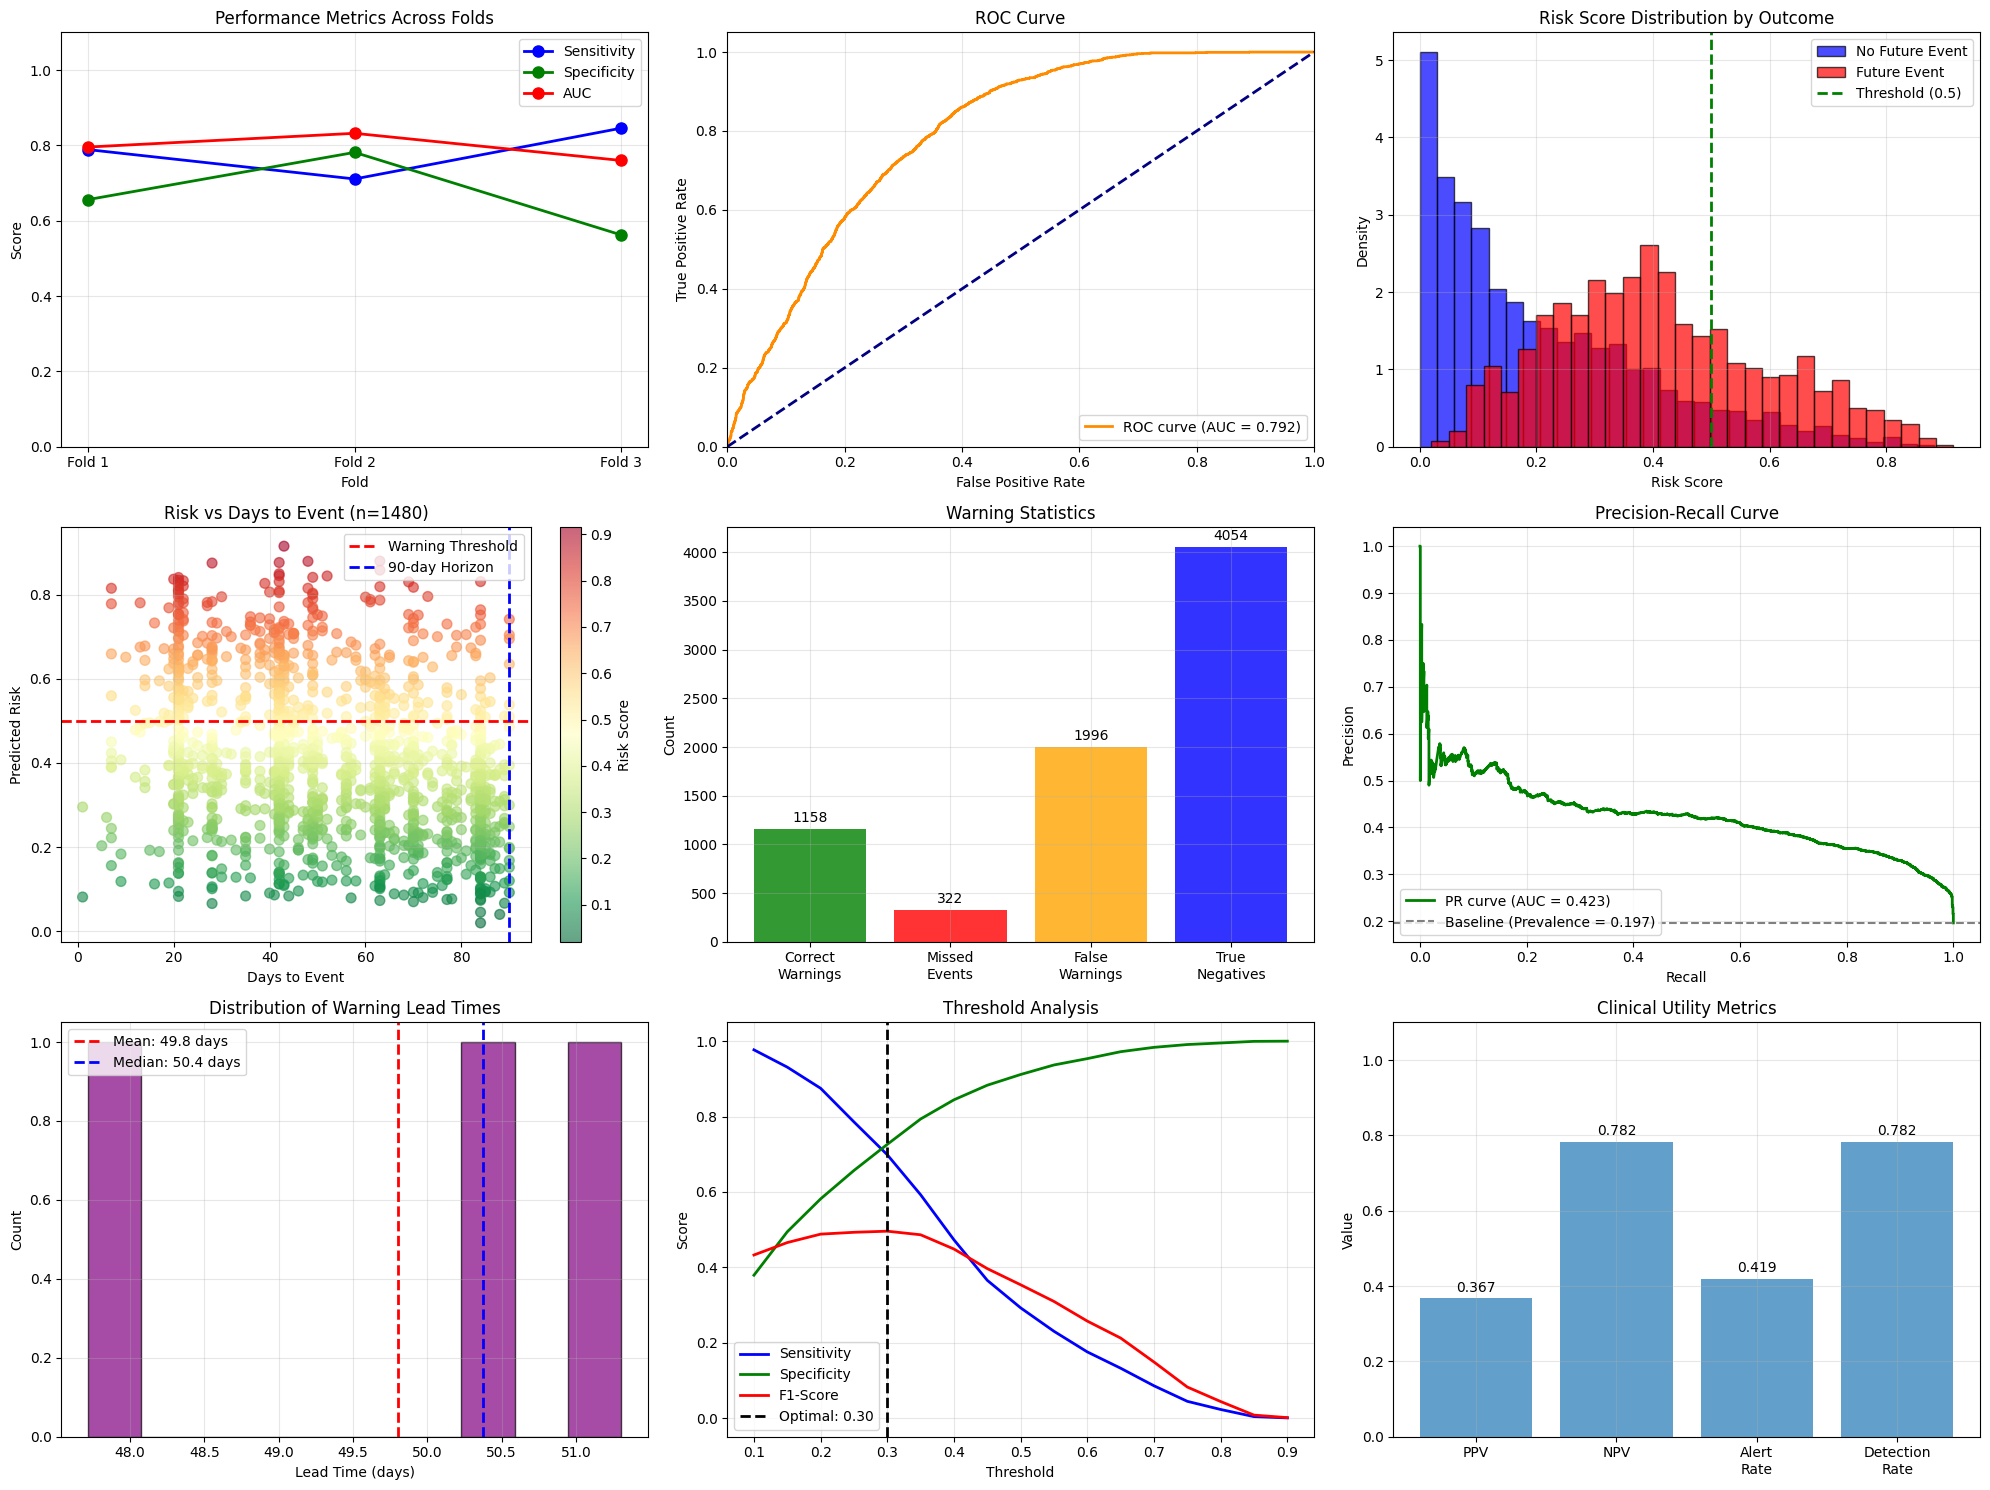


CLINICAL EARLY WARNING SYSTEM COMPLETED!

CLINICAL IMPLICATIONS:
--------------------------------------------------
1. System predicts death within next 90 days
2. Risk scores range from 0 (low risk) to 1 (high risk)
3. Threshold of 0.5 typically used for warnings
4. Lead time = days between warning and actual event

Based on your data:
- 1098 patients died during follow-up
- System trained on 7530 patient sequences
- Prediction horizon: 90 days
- Used autoencoder imputation: True


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve, accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings('ignore')

class AutoencoderImputer:
    def __init__(self, encoding_dim=32, epochs=50, batch_size=32, random_state=42):
        self.encoding_dim = encoding_dim
        self.epochs = epochs
        self.batch_size = batch_size
        self.random_state = random_state
        self.scaler = StandardScaler()
        self.autoencoder = None
        self.is_fitted = False

    def build_autoencoder(self, input_dim):
        """Build a deep autoencoder for imputation"""
        input_layer = layers.Input(shape=(input_dim,))

        # Encoder
        encoded = layers.Dense(128, activation='relu')(input_layer)
        encoded = layers.Dropout(0.2)(encoded)
        encoded = layers.Dense(64, activation='relu')(encoded)
        encoded = layers.Dropout(0.2)(encoded)
        encoded = layers.Dense(self.encoding_dim, activation='relu')(encoded)

        # Decoder
        decoded = layers.Dense(64, activation='relu')(encoded)
        decoded = layers.Dropout(0.2)(decoded)
        decoded = layers.Dense(128, activation='relu')(decoded)
        decoded = layers.Dropout(0.2)(decoded)
        decoded = layers.Dense(input_dim, activation='linear')(decoded)

        # Autoencoder model
        autoencoder = models.Model(input_layer, decoded)

        # Encoder model (for feature extraction)
        encoder = models.Model(input_layer, encoded)

        autoencoder.compile(optimizer=Adam(learning_rate=0.001),
                           loss='mse',
                           metrics=['mae'])

        return autoencoder, encoder

    def fit_imputer(self, X_train):
        """Train autoencoder on complete data"""
        # Create mask for complete cases
        complete_mask = ~np.any(np.isnan(X_train), axis=1)
        X_complete = X_train[complete_mask]

        if len(X_complete) < 10:
            print(f"Warning: Only {len(X_complete)} complete cases for autoencoder training")
            return self

        # Scale the data
        X_scaled = self.scaler.fit_transform(X_complete)

        # Build and train autoencoder
        self.autoencoder, self.encoder = self.build_autoencoder(X_scaled.shape[1])

        early_stop = callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
            min_delta=0.001
        )

        reduce_lr = callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-6
        )

        # Train-validation split
        X_train_split, X_val_split = train_test_split(
            X_scaled, test_size=0.2, random_state=self.random_state
        )

        self.autoencoder.fit(
            X_train_split, X_train_split,
            epochs=self.epochs,
            batch_size=self.batch_size,
            validation_data=(X_val_split, X_val_split),
            callbacks=[early_stop, reduce_lr],
            verbose=0
        )

        self.is_fitted = True
        print(f"Autoencoder trained on {len(X_complete)} complete cases")

        return self

    def impute_missing_values(self, X, max_iter=20, tol=1e-4):
        """Impute missing values using trained autoencoder with iterative refinement"""
        if not self.is_fitted:
            print("Autoencoder not fitted. Fitting now...")
            self.fit_imputer(X)
            if not self.is_fitted:
                return X  # Return original if still not fitted

        X_imputed = X.copy()

        # Check for missing values
        if not np.any(np.isnan(X_imputed)):
            return X_imputed

        # Initial imputation with median
        for i in range(X_imputed.shape[1]):
            col_data = X_imputed[:, i]
            if np.any(np.isnan(col_data)):
                median_val = np.nanmedian(col_data)
                if np.isnan(median_val):
                    median_val = 0
                col_data[np.isnan(col_data)] = median_val
                X_imputed[:, i] = col_data

        # Iterative refinement
        for iteration in range(max_iter):
            X_old = X_imputed.copy()

            # Scale
            X_scaled = self.scaler.transform(X_imputed)

            # Get reconstructions
            X_reconstructed = self.autoencoder.predict(X_scaled, verbose=0)
            X_reconstructed = self.scaler.inverse_transform(X_reconstructed)

            # Only update missing values
            missing_mask = np.isnan(X)
            X_imputed[missing_mask] = X_reconstructed[missing_mask]

            # Check convergence
            if iteration > 0:
                change = np.linalg.norm(X_imputed - X_old) / np.linalg.norm(X_old)
                if change < tol:
                    print(f"Autoencoder imputation converged after {iteration+1} iterations")
                    break

        return X_imputed


class RobustTimeAwareDataProcessor:
    def __init__(self, use_autoencoder=True):
        self.scaler = StandardScaler()
        self.label_encoders = {}
        self.use_autoencoder = use_autoencoder
        self.autoencoder_imputer = AutoencoderImputer() if use_autoencoder else None
        self.feature_names = None

    def clean_data(self, df):
        """Clean data by handling infinity, large values, and missing data"""
        df_clean = df.copy()

        # Replace infinity with NaN
        df_clean = df_clean.replace([np.inf, -np.inf], np.nan)

        # Handle extremely large values by capping at 99th percentile
        numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
        for col in numeric_cols:
            if df_clean[col].notna().any():
                # Cap at 99th percentile
                p99 = df_clean[col].quantile(0.99)
                if not np.isnan(p99):
                    df_clean[col] = df_clean[col].clip(upper=p99 * 10)  # Allow some margin

        return df_clean

    def process_patient_data(self, df):
        """Process data with proper temporal structure"""
        # Clean data first
        df_clean = self.clean_data(df)

        # Handle missing survival data
        missing_before = len(df_clean)
        df_clean = df_clean.dropna(subset=['VISDAY', 'os_event'])
        missing_after = len(df_clean)
        print(f"Removed {missing_before - missing_after} rows with missing survival data")

        # Create patient IDs if not present
        if 'patient_id' not in df_clean.columns:
            # Try to find a patient identifier column
            possible_id_cols = ['RPT', 'SUBJID', 'PATIENT', 'patient', 'id', 'ID']
            found_id = False
            for col in possible_id_cols:
                if col in df_clean.columns:
                    df_clean['patient_id'] = df_clean[col]
                    print(f"Using '{col}' as patient identifier")
                    found_id = True
                    break

            if not found_id:
                # Create synthetic patient IDs (assuming ~5 visits per patient)
                df_clean['patient_id'] = np.arange(len(df_clean)) // 5
                print("Created synthetic patient IDs (5 visits per patient)")

        # Sort by patient and visit day
        df_sorted = df_clean.sort_values(['patient_id', 'VISDAY']).reset_index(drop=True)

        # Calculate time to event for each visit
        print("Calculating time-to-event for each visit...")
        df_sorted['time_to_event'] = np.nan
        df_sorted['is_future_event'] = 0

        unique_patients = df_sorted['patient_id'].unique()
        print(f"Processing {len(unique_patients)} patients...")

        for i, pid in enumerate(unique_patients):
            if i % 200 == 0:
                print(f"  Processed {i}/{len(unique_patients)} patients...")

            patient_data = df_sorted[df_sorted['patient_id'] == pid]

            # Check if patient died (os_event = 1)
            patient_events = patient_data['os_event'].values
            if np.any(patient_events == 1):
                # Patient died - find death day
                death_idx = np.where(patient_events == 1)[0]
                if len(death_idx) > 0:
                    death_day = patient_data.iloc[death_idx[0]]['VISDAY']

                    # For all visits before death, calculate days to death
                    for idx, row in patient_data.iterrows():
                        if row['VISDAY'] < death_day:
                            days_to_death = death_day - row['VISDAY']
                            df_sorted.at[idx, 'time_to_event'] = days_to_death
                            df_sorted.at[idx, 'is_future_event'] = 1
                        elif row['VISDAY'] == death_day:
                            # Death visit itself
                            df_sorted.at[idx, 'time_to_event'] = 0
                            df_sorted.at[idx, 'is_future_event'] = 0  # Not a future event
            else:
                # Patient survived - use maximum follow-up time
                last_visit_day = patient_data['VISDAY'].max()

                for idx, row in patient_data.iterrows():
                    days_from_last = last_visit_day - row['VISDAY']
                    df_sorted.at[idx, 'time_to_event'] = days_from_last
                    df_sorted.at[idx, 'is_future_event'] = 0

        # Handle any remaining NaN values in time_to_event
        nan_count = df_sorted['time_to_event'].isna().sum()
        if nan_count > 0:
            print(f"Warning: {nan_count} NaN values in time_to_event, filling with median")
            median_ttd = df_sorted['time_to_event'].median()
            df_sorted['time_to_event'] = df_sorted['time_to_event'].fillna(median_ttd)

        print(f"Processed {len(df_sorted)} visits from {len(unique_patients)} patients")

        # Count patients with events
        event_patients = df_sorted[df_sorted['os_event'] == 1]['patient_id'].unique()
        no_event_patients = df_sorted[df_sorted['os_event'] == 0]['patient_id'].unique()

        print(f"Patients with event: {len(event_patients)}")
        print(f"Patients without event: {len(no_event_patients)}")
        print(f"Visits with future event: {df_sorted['is_future_event'].sum()}")

        return df_sorted

    def prepare_features_with_autoencoder(self, df_train, df_test, feature_names):
        """Prepare features with autoencoder imputation for train and test separately"""
        print(f"Using autoencoder imputation: {self.use_autoencoder}")

        # Select features that exist in dataframe
        available_features = [f for f in feature_names if f in df_train.columns]
        print(f"Using {len(available_features)} available features")

        # Prepare train and test data
        X_train_raw = df_train[available_features].copy()
        X_test_raw = df_test[available_features].copy()

        # Replace any infinity values
        X_train_raw = X_train_raw.replace([np.inf, -np.inf], np.nan)
        X_test_raw = X_test_raw.replace([np.inf, -np.inf], np.nan)

        # Handle categorical variables
        categorical_cols = X_train_raw.select_dtypes(exclude=[np.number]).columns
        numeric_cols = X_train_raw.select_dtypes(include=[np.number]).columns

        print(f"Categorical columns: {len(categorical_cols)}")
        print(f"Numeric columns: {len(numeric_cols)}")

        # Encode categorical variables
        encoded_train = []
        encoded_test = []

        for col in categorical_cols:
            try:
                if col not in self.label_encoders:
                    self.label_encoders[col] = LabelEncoder()
                    # Combine train and test for fitting to handle all categories
                    combined = pd.concat([X_train_raw[col], X_test_raw[col]], ignore_index=True)
                    combined = combined.astype(str).fillna('missing')
                    self.label_encoders[col].fit(combined)

                # Transform train and test
                train_encoded = self.label_encoders[col].transform(
                    X_train_raw[col].astype(str).fillna('missing')
                )
                test_encoded = self.label_encoders[col].transform(
                    X_test_raw[col].astype(str).fillna('missing')
                )

                encoded_train.append(train_encoded.reshape(-1, 1))
                encoded_test.append(test_encoded.reshape(-1, 1))

            except Exception as e:
                print(f"Warning: Could not encode column {col}: {e}")
                # Drop problematic column
                continue

        # Combine categorical and numeric data
        X_train_combined = []
        X_test_combined = []

        if len(categorical_cols) > 0 and encoded_train:
            X_train_cat = np.hstack(encoded_train)
            X_test_cat = np.hstack(encoded_test)
            X_train_combined.append(X_train_cat)
            X_test_combined.append(X_test_cat)

        if len(numeric_cols) > 0:
            X_train_num = X_train_raw[numeric_cols].values
            X_test_num = X_test_raw[numeric_cols].values
            X_train_combined.append(X_train_num)
            X_test_combined.append(X_test_num)

        # Combine all features
        if X_train_combined:
            X_train = np.hstack(X_train_combined)
            X_test = np.hstack(X_test_combined)
        else:
            print("Warning: No features available after preprocessing")
            return None, None, available_features

        print(f"Train data shape before imputation: {X_train.shape}")
        print(f"Test data shape before imputation: {X_test.shape}")
        print(f"Missing values in train: {np.isnan(X_train).sum()} ({np.isnan(X_train).mean()*100:.1f}%)")
        print(f"Missing values in test: {np.isnan(X_test).sum()} ({np.isnan(X_test).mean()*100:.1f}%)")

        if self.use_autoencoder and self.autoencoder_imputer:
            # Fit autoencoder on training data
            print("\nFitting autoencoder on training data...")
            self.autoencoder_imputer.fit_imputer(X_train)

            # Impute missing values separately for train and test
            print("Imputing missing values in training set...")
            X_train_imputed = self.autoencoder_imputer.impute_missing_values(X_train)

            print("Imputing missing values in test set...")
            X_test_imputed = self.autoencoder_imputer.impute_missing_values(X_test)

            # Scale the imputed data
            X_train_scaled = self.scaler.fit_transform(X_train_imputed)
            X_test_scaled = self.scaler.transform(X_test_imputed)

            print(f"Missing values after autoencoder imputation (train): {np.isnan(X_train_scaled).sum()}")
            print(f"Missing values after autoencoder imputation (test): {np.isnan(X_test_scaled).sum()}")

            return X_train_scaled, X_test_scaled, available_features
        else:
            # Fallback: Simple imputation
            print("Using simple imputation (median/mode)...")

            # Impute missing values with median for numeric, mode for categorical
            for i in range(X_train.shape[1]):
                # Train imputation
                train_col = X_train[:, i]
                if np.any(np.isnan(train_col)):
                    if i < len(categorical_cols):
                        # Categorical - use mode
                        mode_val = np.nanmode(train_col)
                        if np.isnan(mode_val):
                            mode_val = 0
                        X_train[:, i] = np.nan_to_num(train_col, nan=mode_val)
                    else:
                        # Numeric - use median
                        median_val = np.nanmedian(train_col)
                        if np.isnan(median_val):
                            median_val = 0
                        X_train[:, i] = np.nan_to_num(train_col, nan=median_val)

                # Test imputation (using statistics from train)
                test_col = X_test[:, i]
                if np.any(np.isnan(test_col)):
                    if i < len(categorical_cols):
                        # Categorical - use mode from train
                        mode_val = np.nanmode(X_train[:, i])
                        if np.isnan(mode_val):
                            mode_val = 0
                        X_test[:, i] = np.nan_to_num(test_col, nan=mode_val)
                    else:
                        # Numeric - use median from train
                        median_val = np.nanmedian(X_train[:, i])
                        if np.isnan(median_val):
                            median_val = 0
                        X_test[:, i] = np.nan_to_num(test_col, nan=median_val)

            # Scale the data
            X_train_scaled = self.scaler.fit_transform(X_train)
            X_test_scaled = self.scaler.transform(X_test)

            return X_train_scaled, X_test_scaled, available_features

    def prepare_features(self, df, feature_names):
        """Legacy method for backward compatibility - prepares features without train/test split"""
        print("Warning: Using legacy prepare_features method without train/test split")

        # Select features that exist in dataframe
        available_features = [f for f in feature_names if f in df.columns]
        print(f"Using {len(available_features)} available features")

        # Handle missing values
        df_filled = df[available_features].copy()

        # Replace any remaining infinity values
        df_filled = df_filled.replace([np.inf, -np.inf], np.nan)

        # Fill numeric missing values with median
        numeric_cols = df_filled.select_dtypes(include=[np.number]).columns
        print(f"Processing {len(numeric_cols)} numeric columns...")

        for col in numeric_cols:
            if df_filled[col].isnull().any():
                median_val = df_filled[col].median()
                if pd.isna(median_val):
                    median_val = 0  # Fallback
                df_filled[col] = df_filled[col].fillna(median_val)

        # Fill categorical missing values with mode
        categorical_cols = df_filled.select_dtypes(exclude=[np.number]).columns
        print(f"Processing {len(categorical_cols)} categorical columns...")

        for col in categorical_cols:
            if df_filled[col].isnull().any():
                mode_val = df_filled[col].mode()
                if len(mode_val) > 0:
                    df_filled[col] = df_filled[col].fillna(mode_val[0])
                else:
                    df_filled[col] = df_filled[col].fillna('missing')

        # Encode categorical variables
        print("Encoding categorical variables...")
        for col in categorical_cols:
            try:
                if col not in self.label_encoders:
                    self.label_encoders[col] = LabelEncoder()
                    # Handle any non-string values
                    col_data = df_filled[col].astype(str)
                    self.label_encoders[col].fit(col_data)

                df_filled[col] = self.label_encoders[col].transform(df_filled[col].astype(str))
            except Exception as e:
                print(f"Warning: Could not encode column {col}: {e}")
                # Drop problematic column
                df_filled = df_filled.drop(columns=[col])
                available_features.remove(col)

        # Scale numeric features
        if len(numeric_cols) > 0:
            print("Scaling numeric features...")
            # Check for any remaining issues
            numeric_data = df_filled[numeric_cols].values
            if np.any(np.isnan(numeric_data)) or np.any(np.isinf(numeric_data)):
                print("Warning: NaN or Inf found in numeric data after cleaning")
                # Replace with zeros as last resort
                numeric_data = np.nan_to_num(numeric_data, nan=0.0, posinf=1e6, neginf=-1e6)
                df_filled[numeric_cols] = numeric_data

            try:
                df_filled[numeric_cols] = self.scaler.fit_transform(df_filled[numeric_cols])
            except Exception as e:
                print(f"Warning: Could not scale features: {e}")
                # Use min-max scaling as fallback
                for col in numeric_cols:
                    col_min = df_filled[col].min()
                    col_max = df_filled[col].max()
                    if col_max > col_min:
                        df_filled[col] = (df_filled[col] - col_min) / (col_max - col_min)
                    else:
                        df_filled[col] = 0

        print(f"Final feature matrix shape: {df_filled.shape}")
        return df_filled.values, available_features

    def create_temporal_sequences(self, df, feature_cols, max_sequence_length=5, prediction_horizon=90):
        """Create sequences with proper temporal structure"""
        print("Creating temporal sequences...")
        sequences = []
        labels = []
        time_intervals = []
        patient_ids = []
        days_to_event_list = []

        unique_patients = df['patient_id'].unique()

        for pid in unique_patients:
            patient_data = df[df['patient_id'] == pid].sort_values('VISDAY')

            if len(patient_data) < 2:
                continue  # Need at least 2 visits

            # Get features and temporal data
            patient_features = patient_data[feature_cols].values
            patient_visdays = patient_data['VISDAY'].values
            patient_time_to_event = patient_data['time_to_event'].values
            patient_has_event = patient_data['is_future_event'].values

            # Create sequences
            for i in range(1, len(patient_data)):  # Start from 1 to have at least one previous visit
                # Determine sequence length (up to max_sequence_length)
                seq_len = min(i, max_sequence_length)
                start_idx = i - seq_len

                # Get sequence data
                seq_features = patient_features[start_idx:i+1]  # Including current visit
                seq_visdays = patient_visdays[start_idx:i+1]

                # Calculate time intervals between visits (in days)
                if len(seq_visdays) > 1:
                    time_diffs = np.diff(seq_visdays)
                    # Add a default 30-day interval for the first gap
                    time_diffs = np.concatenate([[30], time_diffs])
                else:
                    time_diffs = np.array([30])

                # Normalize time intervals (divide by 30 to get approximate months)
                time_diffs_normalized = time_diffs / 30.0

                # Create label: will event occur within prediction horizon?
                current_time_to_event = patient_time_to_event[i]
                if current_time_to_event <= prediction_horizon and current_time_to_event > 0:
                    label = 1  # Event will occur within horizon
                else:
                    label = 0  # No event within horizon

                # Pad sequence if needed
                if seq_len < max_sequence_length:
                    pad_len = max_sequence_length - seq_len
                    seq_features = np.pad(seq_features, ((pad_len, 0), (0, 0)), mode='constant')
                    time_diffs_normalized = np.pad(time_diffs_normalized, (pad_len, 0),
                                                  mode='constant', constant_values=1.0)  # 1 month for padding

                sequences.append(seq_features)
                labels.append(label)
                time_intervals.append(time_diffs_normalized)
                patient_ids.append(pid)
                days_to_event_list.append(current_time_to_event)

        sequences = np.array(sequences)
        labels = np.array(labels)
        time_intervals = np.array(time_intervals)
        patient_ids = np.array(patient_ids)

        print(f"\nCreated {len(sequences)} sequences")
        print(f"Positive sequences (event within {prediction_horizon} days): {np.sum(labels == 1)} ({np.mean(labels == 1)*100:.1f}%)")
        print(f"Negative sequences: {np.sum(labels == 0)}")

        # Analyze positive sequences
        if np.sum(labels == 1) > 0:
            positive_days = np.array(days_to_event_list)[labels == 1]
            print(f"Days to event for positive sequences:")
            print(f"  Mean: {np.mean(positive_days):.1f} days")
            print(f"  Median: {np.median(positive_days):.1f} days")
            print(f"  Range: {np.min(positive_days):.1f} to {np.max(positive_days):.1f} days")

        return sequences, labels, time_intervals, patient_ids, days_to_event_list


class TimeAwareEarlyWarningModel:
    def __init__(self, input_dim, sequence_length=5, lstm_units=64):
        self.input_dim = input_dim
        self.sequence_length = sequence_length
        self.lstm_units = lstm_units
        self.model = None
        self.history = None

    def build_model_with_time_awareness(self):
        """Build model that incorporates time intervals between visits"""
        # Two input layers: features and time intervals
        feature_input = layers.Input(shape=(self.sequence_length, self.input_dim), name='features')
        time_input = layers.Input(shape=(self.sequence_length, 1), name='time_intervals')

        # Process time intervals
        time_processed = layers.Dense(8, activation='relu')(time_input)
        time_processed = layers.Dense(16, activation='relu')(time_processed)

        # Concatenate features with time information
        combined = layers.Concatenate(axis=-1)([feature_input, time_processed])

        # LSTM layers
        lstm_out = layers.Bidirectional(layers.LSTM(self.lstm_units, return_sequences=True))(combined)
        lstm_out = layers.Dropout(0.3)(lstm_out)

        # Simple attention mechanism
        attention_scores = layers.TimeDistributed(layers.Dense(1, activation='tanh'))(lstm_out)
        attention_weights = layers.Softmax(axis=1)(attention_scores)
        context_vector = layers.Multiply()([lstm_out, attention_weights])

        # Global average pooling instead of just last time step
        pooled = layers.GlobalAveragePooling1D()(context_vector)

        # Dense layers
        dense1 = layers.Dense(64, activation='relu')(pooled)
        dense1 = layers.BatchNormalization()(dense1)
        dense1 = layers.Dropout(0.3)(dense1)

        dense2 = layers.Dense(32, activation='relu')(dense1)
        dense2 = layers.BatchNormalization()(dense2)
        dense2 = layers.Dropout(0.2)(dense2)

        # Output: risk of event within prediction horizon
        risk_score = layers.Dense(1, activation='sigmoid', name='risk_score')(dense2)

        # Create model
        self.model = models.Model(inputs=[feature_input, time_input], outputs=risk_score)

        return self.model

    def compile_model(self, learning_rate=0.001):
        """Compile the model"""
        self.model.compile(
            optimizer=Adam(learning_rate=learning_rate),
            loss='binary_crossentropy',
            metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
                    tf.keras.metrics.Precision(name='precision'),
                    tf.keras.metrics.Recall(name='recall')]
        )

        return self.model

    def train(self, X_features, X_time, y_train, val_data=None, epochs=100, batch_size=32, class_weight=None):
        """Train the model"""
        early_stopping = callbacks.EarlyStopping(
            monitor='val_loss' if val_data else 'loss',
            patience=15,
            restore_best_weights=True,
            min_delta=0.001,
            verbose=0
        )

        reduce_lr = callbacks.ReduceLROnPlateau(
            monitor='val_loss' if val_data else 'loss',
            factor=0.5,
            patience=8,
            min_lr=1e-6,
            verbose=0
        )

        callbacks_list = [early_stopping, reduce_lr]

        if val_data:
            X_val_features, X_val_time, y_val = val_data
            validation_data = ([X_val_features, X_val_time], y_val)
        else:
            validation_data = None

        self.history = self.model.fit(
            [X_features, X_time], y_train,
            validation_data=validation_data,
            epochs=epochs,
            batch_size=batch_size,
            callbacks=callbacks_list,
            verbose=0,
            class_weight=class_weight
        )

        return self.history

    def predict(self, X_features, X_time):
        """Make predictions"""
        return self.model.predict([X_features, X_time], verbose=0).flatten()


class ClinicalEarlyWarningPipeline:
    def __init__(self, prediction_horizon_days=90, n_splits=3, random_state=42, use_autoencoder=True):
        self.prediction_horizon = prediction_horizon_days
        self.n_splits = n_splits
        self.random_state = random_state
        self.use_autoencoder = use_autoencoder
        self.data_processor = RobustTimeAwareDataProcessor(use_autoencoder=use_autoencoder)
        self.results = {}

    def select_clinical_features(self, df):
        """Select relevant clinical features for early warning"""
        # Common clinical features for mortality prediction
        base_features = [
            'AGE', 'SEX', 'RACE',  # Demographics
            'BMI', 'WEIGHT', 'HEIGHT',  # Anthropometrics
            'ECOG', 'KPS',  # Performance status
        ]

        # Lab values (if available)
        lab_features = [
            'ALB', 'ALP', 'ALT', 'AST', 'BILI', 'CALCIUM', 'CREAT', 'HGB',
            'LYMPH', 'NEUT', 'PLAT', 'WBC', 'SODIUM', 'POTASSIUM', 'GLUCOSE',
            'BUN', 'CRP', 'LDH'
        ]

        # Treatment and AE features from your data
        treatment_features = [
            'cycle_number', 'total_cycles', 'anytarget', 'anynontarget',
            'total_ae_events', 'serious_ae_count', 'grade3_plus_count',
            'any_grade3_plus', 'treatment_related_count', 'any_treatment_related',
            'grade1_count', 'grade2_count', 'grade3_count', 'grade4_count',
            'drug_interrupted', 'drug_reduced', 'drug_withdrawn', 'drug_not_changed',
            'other_drug_interrupted', 'other_drug_reduced', 'other_drug_withdrawn',
            'concomitant_treatment_given', 'cum_any_grade3_plus',
            'cum_any_treatment_related', 'cum_drug_withdrawn',
            'cum_other_drug_withdrawn', 'cum_concomitant_treatment',
            'ongoing_ae_count', 'mean_ae_duration', 'max_ae_duration'
        ]

        # Combine and check availability
        all_possible = base_features + lab_features + treatment_features
        available_features = [f for f in all_possible if f in df.columns]

        print(f"Found {len(available_features)} available features out of {len(all_possible)} possible")

        # If we have very few features, use some defaults
        if len(available_features) < 10:
            print("Warning: Few features available, using basic set")
            # Try to find any numeric columns
            numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
            # Exclude ID and date columns
            exclude_cols = ['VISDAY', 'DSDAY', 'patient_id', 'id', 'index', 'time_to_event', 'is_future_event']
            numeric_cols = [c for c in numeric_cols if c not in exclude_cols]
            available_features = numeric_cols[:20]  # Take first 20 numeric columns

        return available_features

    def run_pipeline(self, pcdata):
        """Run the complete early warning pipeline"""
        print("="*70)
        print("CLINICAL EARLY WARNING SYSTEM FOR MORTALITY PREDICTION")
        print("="*70)
        print(f"Prediction horizon: {self.prediction_horizon} days")
        print(f"Using autoencoder imputation: {self.use_autoencoder}")
        print(f"Looking for death events within next {self.prediction_horizon} days")

        # Step 1: Process data with temporal structure
        print("\n1. Processing temporal data...")
        print("-"*40)

        df_processed = self.data_processor.process_patient_data(pcdata)

        # Step 2: Prepare features (we'll do this separately for each fold)
        print("\n2. Selecting clinical features...")
        print("-"*40)

        feature_names = self.select_clinical_features(df_processed)
        print(f"Selected {len(feature_names)} features for modeling")

        # Add processed features back to dataframe (we'll impute in each fold)
        feature_cols = [f'feat_{i}' for i in range(len(feature_names))]

        # Step 3: Create temporal sequences (with raw features)
        print("\n3. Creating temporal sequences...")
        print("-"*40)

        # We'll use the raw data and impute in each fold
        df_for_sequences = df_processed.copy()
        # Store original values for imputation
        for i, feat in enumerate(feature_names):
            if feat in df_for_sequences.columns:
                df_for_sequences[f'feat_{i}'] = df_for_sequences[feat]

        sequences, labels, time_intervals, patient_ids, days_to_event = self.data_processor.create_temporal_sequences(
            df_for_sequences, feature_cols, max_sequence_length=5,
            prediction_horizon=self.prediction_horizon
        )

        if len(sequences) == 0:
            print("Error: No sequences created!")
            return None

        print(f"Sequence shape: {sequences.shape}")
        print(f"Time intervals shape: {time_intervals.shape}")

        # Step 4: Analyze data balance
        print("\n4. Analyzing data balance...")
        print("-"*40)

        positive_rate = np.mean(labels == 1)
        print(f"Positive rate (event within {self.prediction_horizon} days): {positive_rate:.3f}")

        if positive_rate < 0.01:
            print("Warning: Very low positive rate, model may struggle to learn")
            print("Consider increasing prediction horizon or using different labeling")

        # Step 5: Cross-validation with fold-specific imputation
        print("\n5. Running cross-validation with fold-specific imputation...")
        print("-"*40)

        # Create patient-level splits
        unique_patients = np.unique(patient_ids)
        print(f"Unique patients in sequences: {len(unique_patients)}")

        # Get patient labels (max label across their sequences)
        patient_labels = []

        for pid in unique_patients:
            patient_mask = patient_ids == pid
            patient_label = np.max(labels[patient_mask])  # Patient has event if any sequence does
            patient_labels.append(patient_label)

        patient_labels = np.array(patient_labels)

        print(f"Patients with future event in sequences: {np.sum(patient_labels == 1)}")
        print(f"Patients without future event in sequences: {np.sum(patient_labels == 0)}")

        if np.sum(patient_labels == 1) < 2:
            print(f"Error: Only {np.sum(patient_labels == 1)} patients with events")
            print("Cannot perform cross-validation. Using simple train/test split instead.")
            return self.run_simple_split(sequences, labels, time_intervals, patient_ids, days_to_event, df_processed, feature_names)

        n_folds = min(self.n_splits, np.sum(patient_labels == 1))
        if n_folds < self.n_splits:
            print(f"Reducing CV folds to {n_folds} (only {np.sum(patient_labels == 1)} patients with events)")

        skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=self.random_state)

        cv_results = {
            'fold': [],
            'sensitivity': [], 'specificity': [], 'auc': [],
            'precision': [], 'recall': [], 'f1': [],
            'lead_times': [], 'warning_stats': [],
            'risk_scores': [], 'true_labels': [],
            'days_to_event': []
        }

        fold = 1
        for train_patient_idx, test_patient_idx in skf.split(unique_patients, patient_labels):
            print(f"\n{'='*60}")
            print(f"FOLD {fold}/{n_folds}")
            print(f"{'='*60}")

            # Get patient IDs for train/test
            train_patient_ids = unique_patients[train_patient_idx]
            test_patient_ids = unique_patients[test_patient_idx]

            print(f"Training patients: {len(train_patient_ids)}")
            print(f"Test patients: {len(test_patient_ids)}")

            # Create masks
            train_mask = np.isin(patient_ids, train_patient_ids)
            test_mask = np.isin(patient_ids, test_patient_ids)

            # Split data (raw sequences)
            X_train_seq_raw = sequences[train_mask]
            X_test_seq_raw = sequences[test_mask]

            X_train_time = time_intervals[train_mask]
            X_test_time = time_intervals[test_mask]

            y_train = labels[train_mask]
            y_test = labels[test_mask]

            test_days_to_event = np.array(days_to_event)[test_mask]

            train_pids = patient_ids[train_mask]

            # Step: IMPUTE MISSING VALUES SEPARATELY FOR TRAIN AND TEST
            print("\n6. Imputing missing values with autoencoder...")
            print("-"*40)

            # Reshape sequences for imputation (flatten temporal dimension)
            n_train_samples, seq_len, n_features = X_train_seq_raw.shape
            n_test_samples = X_test_seq_raw.shape[0]

            X_train_flat = X_train_seq_raw.reshape(n_train_samples * seq_len, n_features)
            X_test_flat = X_test_seq_raw.reshape(n_test_samples * seq_len, n_features)

            # Create temporary dataframes for imputation
            df_train_impute = pd.DataFrame(X_train_flat, columns=feature_cols)
            df_test_impute = pd.DataFrame(X_test_flat, columns=feature_cols)

            # Add patient_id for grouping (but we won't use it for imputation)
            train_patient_ids_repeated = np.repeat(train_pids, seq_len)
            test_patient_ids_repeated = np.repeat(patient_ids[test_mask], seq_len)

            # Impute missing values separately for train and test
            X_train_imputed_flat, X_test_imputed_flat, _ = self.data_processor.prepare_features_with_autoencoder(
                df_train_impute, df_test_impute, feature_cols
            )

            # Reshape back to sequences
            X_train_seq_imputed = X_train_imputed_flat.reshape(n_train_samples, seq_len, n_features)
            X_test_seq_imputed = X_test_imputed_flat.reshape(n_test_samples, seq_len, n_features)

            print(f"Train sequences after imputation: {X_train_seq_imputed.shape}")
            print(f"Test sequences after imputation: {X_test_seq_imputed.shape}")

            # Split training for validation
            unique_train_pids = np.unique(train_pids)
            val_patient_count = max(1, int(0.2 * len(unique_train_pids)))
            val_patient_ids = np.random.choice(unique_train_pids, val_patient_count, replace=False)
            val_mask = np.isin(train_pids, val_patient_ids)

            X_val_seq = X_train_seq_imputed[val_mask]
            X_val_time = X_train_time[val_mask]
            y_val = y_train[val_mask]

            X_train_seq_final = X_train_seq_imputed[~val_mask]
            X_train_time_final = X_train_time[~val_mask]
            y_train_final = y_train[~val_mask]

            print(f"Training sequences: {X_train_seq_final.shape[0]} (pos: {np.mean(y_train_final):.3f})")
            print(f"Validation sequences: {X_val_seq.shape[0]} (pos: {np.mean(y_val):.3f})")
            print(f"Test sequences: {X_test_seq_imputed.shape[0]} (pos: {np.mean(y_test):.3f})")

            # Handle class imbalance
            if np.sum(y_train_final) > 0:
                pos_weight = len(y_train_final) / (2 * np.sum(y_train_final))
                class_weight = {0: 1.0, 1: min(10.0, pos_weight)}  # Cap at 10x
            else:
                class_weight = {0: 1.0, 1: 1.0}

            # Step 7: Train model
            print("\n7. Training time-aware early warning model...")

            model = TimeAwareEarlyWarningModel(
                input_dim=X_train_seq_final.shape[2],
                sequence_length=X_train_seq_final.shape[1],
                lstm_units=32  # Reduced for stability
            )

            model.build_model_with_time_awareness()
            model.compile_model(learning_rate=0.001)

            try:
                history = model.train(
                    X_train_seq_final, X_train_time_final, y_train_final,
                    val_data=(X_val_seq, X_val_time, y_val),
                    epochs=50,  # Reduced for speed
                    batch_size=32,
                    class_weight=class_weight
                )

                # Check training history
                if history and 'loss' in history.history:
                    final_train_loss = history.history['loss'][-1]
                    final_val_loss = history.history.get('val_loss', [final_train_loss])[-1]
                    print(f"Final training loss: {final_train_loss:.4f}, validation loss: {final_val_loss:.4f}")
                else:
                    print("Warning: Training history not available")
                    final_train_loss = 0.5
                    final_val_loss = 0.5

            except Exception as e:
                print(f"Warning: Training failed: {e}")
                print("Skipping this fold...")
                fold += 1
                continue

            # Step 8: Evaluate
            print("\n8. Evaluating early warnings...")

            # Get predictions
            try:
                train_pred = model.predict(X_train_seq_final, X_train_time_final)
                test_pred = model.predict(X_test_seq_imputed, X_test_time)
            except Exception as e:
                print(f"Warning: Prediction failed: {e}")
                fold += 1
                continue

            # Find optimal threshold (maximizing F1 score)
            thresholds = np.linspace(0.1, 0.9, 17)
            best_f1 = 0
            best_threshold = 0.5

            for thresh in thresholds:
                pred_binary = (test_pred > thresh).astype(int)
                if np.sum(pred_binary) > 0 and np.sum(y_test) > 0:
                    try:
                        f1 = f1_score(y_test, pred_binary, zero_division=0)
                        if f1 > best_f1:
                            best_f1 = f1
                            best_threshold = thresh
                    except:
                        continue

            print(f"Optimal threshold: {best_threshold:.3f} (F1: {best_f1:.3f})")

            # Calculate metrics
            test_pred_binary = (test_pred > best_threshold).astype(int)

            # Handle cases with no predictions
            if np.sum(test_pred_binary) == 0:
                print("Warning: No positive predictions at this threshold")
                accuracy = accuracy_score(y_test, test_pred_binary)
                auc_score = 0.5
                precision = 0
                recall = 0
                f1 = 0
                tn = np.sum(y_test == 0)
                fp = 0
                fn = np.sum(y_test == 1)
                tp = 0
            elif np.sum(y_test) == 0:
                print("Warning: No positive cases in test set")
                accuracy = accuracy_score(y_test, test_pred_binary)
                auc_score = 0.5
                precision = 0
                recall = 0
                f1 = 0
                tn = np.sum((y_test == 0) & (test_pred_binary == 0))
                fp = np.sum((y_test == 0) & (test_pred_binary == 1))
                fn = 0
                tp = 0
            else:
                accuracy = accuracy_score(y_test, test_pred_binary)
                try:
                    auc_score = roc_auc_score(y_test, test_pred)
                except:
                    auc_score = 0.5
                precision = precision_score(y_test, test_pred_binary, zero_division=0)
                recall = recall_score(y_test, test_pred_binary, zero_division=0)
                f1 = f1_score(y_test, test_pred_binary, zero_division=0)

                # Calculate confusion matrix
                try:
                    cm = confusion_matrix(y_test, test_pred_binary)
                    if cm.shape == (2, 2):
                        tn, fp, fn, tp = cm.ravel()
                    else:
                        # Handle case where only one class predicted
                        tn = np.sum((y_test == 0) & (test_pred_binary == 0))
                        fp = np.sum((y_test == 0) & (test_pred_binary == 1))
                        fn = np.sum((y_test == 1) & (test_pred_binary == 0))
                        tp = np.sum((y_test == 1) & (test_pred_binary == 1))
                except:
                    tn = np.sum((y_test == 0) & (test_pred_binary == 0))
                    fp = np.sum((y_test == 0) & (test_pred_binary == 1))
                    fn = np.sum((y_test == 1) & (test_pred_binary == 0))
                    tp = np.sum((y_test == 1) & (test_pred_binary == 1))

            sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

            print(f"\nFold {fold} Results:")
            print(f"  Accuracy: {accuracy:.4f}")
            print(f"  AUC: {auc_score:.4f}")
            print(f"  Sensitivity: {sensitivity:.4f}")
            print(f"  Specificity: {specificity:.4f}")
            print(f"  Precision: {precision:.4f}")
            print(f"  Recall: {recall:.4f}")
            print(f"  F1-Score: {f1:.4f}")
            print(f"  TP: {tp}, FP: {fp}, FN: {fn}, TN: {tn}")

            # Store results
            cv_results['fold'].append(fold)
            cv_results['sensitivity'].append(sensitivity)
            cv_results['specificity'].append(specificity)
            cv_results['auc'].append(auc_score)
            cv_results['precision'].append(precision)
            cv_results['recall'].append(recall)
            cv_results['f1'].append(f1)
            cv_results['risk_scores'].extend(test_pred.tolist())
            cv_results['true_labels'].extend(y_test.tolist())
            cv_results['days_to_event'].extend(test_days_to_event.tolist())

            # Calculate lead times for correctly warned patients
            if tp > 0:
                # For TP cases, get actual days to event
                tp_mask = (y_test == 1) & (test_pred_binary == 1)
                if np.any(tp_mask):
                    tp_days = test_days_to_event[tp_mask]
                    avg_lead_time = np.mean(tp_days)
                    cv_results['lead_times'].append(avg_lead_time)

                    warning_stats = {
                        'correct_warnings': int(tp),
                        'missed_warnings': int(fn),
                        'false_warnings': int(fp),
                        'true_negatives': int(tn),
                        'avg_lead_time': float(avg_lead_time)
                    }
                else:
                    warning_stats = {
                        'correct_warnings': int(tp),
                        'missed_warnings': int(fn),
                        'false_warnings': int(fp),
                        'true_negatives': int(tn),
                        'avg_lead_time': 0.0
                    }
                cv_results['warning_stats'].append(warning_stats)

            fold += 1

        self.results = cv_results

        if not cv_results['fold']:
            print("\nERROR: No folds completed successfully!")
            print("Trying simple train/test split instead...")
            return self.run_simple_split(sequences, labels, time_intervals, patient_ids, days_to_event, df_processed, feature_names)

        # Step 9: Analyze results
        print("\n" + "="*70)
        print("COMPREHENSIVE EARLY WARNING ANALYSIS")
        print("="*70)

        self.analyze_results(cv_results)
        self.visualize_results(cv_results)

        return cv_results

    def run_simple_split(self, sequences, labels, time_intervals, patient_ids, days_to_event, df_processed, feature_names):
        """Run a simple train/test split when cross-validation fails"""
        print("\nRunning simple train/test split...")

        # Simple split by sequences (not patients)
        n_samples = len(sequences)
        indices = np.arange(n_samples)
        np.random.shuffle(indices)

        split_idx = int(0.8 * n_samples)
        train_idx = indices[:split_idx]
        test_idx = indices[split_idx:]

        X_train_seq_raw = sequences[train_idx]
        X_test_seq_raw = sequences[test_idx]

        X_train_time = time_intervals[train_idx]
        X_test_time = time_intervals[test_idx]

        y_train = labels[train_idx]
        y_test = labels[test_idx]

        test_days_to_event = days_to_event[test_idx]

        # Step: Impute missing values separately
        print("\nImputing missing values with autoencoder...")

        # Reshape sequences for imputation
        n_train_samples, seq_len, n_features = X_train_seq_raw.shape
        n_test_samples = X_test_seq_raw.shape[0]

        X_train_flat = X_train_seq_raw.reshape(n_train_samples * seq_len, n_features)
        X_test_flat = X_test_seq_raw.reshape(n_test_samples * seq_len, n_features)

        # Create temporary dataframes
        feature_cols = [f'feat_{i}' for i in range(n_features)]
        df_train_impute = pd.DataFrame(X_train_flat, columns=feature_cols)
        df_test_impute = pd.DataFrame(X_test_flat, columns=feature_cols)

        # Impute missing values
        X_train_imputed_flat, X_test_imputed_flat, _ = self.data_processor.prepare_features_with_autoencoder(
            df_train_impute, df_test_impute, feature_cols
        )

        # Reshape back
        X_train_seq_imputed = X_train_imputed_flat.reshape(n_train_samples, seq_len, n_features)
        X_test_seq_imputed = X_test_imputed_flat.reshape(n_test_samples, seq_len, n_features)

        print(f"Train sequences after imputation: {X_train_seq_imputed.shape}")
        print(f"Test sequences after imputation: {X_test_seq_imputed.shape}")

        # Split training for validation
        val_size = int(0.2 * len(train_idx))
        X_val_seq = X_train_seq_imputed[:val_size]
        X_val_time = X_train_time[:val_size]
        y_val = y_train[:val_size]

        X_train_seq_final = X_train_seq_imputed[val_size:]
        X_train_time_final = X_train_time[val_size:]
        y_train_final = y_train[val_size:]

        print(f"Training sequences: {X_train_seq_final.shape[0]} (pos: {np.mean(y_train_final):.3f})")
        print(f"Validation sequences: {X_val_seq.shape[0]} (pos: {np.mean(y_val):.3f})")
        print(f"Test sequences: {X_test_seq_imputed.shape[0]} (pos: {np.mean(y_test):.3f})")

        # Handle class imbalance
        if np.sum(y_train_final) > 0:
            pos_weight = len(y_train_final) / (2 * np.sum(y_train_final))
            class_weight = {0: 1.0, 1: min(10.0, pos_weight)}  # Cap at 10x
        else:
            class_weight = {0: 1.0, 1: 1.0}

        # Train model
        print("\nTraining time-aware early warning model...")

        model = TimeAwareEarlyWarningModel(
            input_dim=X_train_seq_final.shape[2],
            sequence_length=X_train_seq_final.shape[1],
            lstm_units=32
        )

        model.build_model_with_time_awareness()
        model.compile_model(learning_rate=0.001)

        try:
            history = model.train(
                X_train_seq_final, X_train_time_final, y_train_final,
                val_data=(X_val_seq, X_val_time, y_val),
                epochs=50,
                batch_size=32,
                class_weight=class_weight
            )

            print("Training completed successfully")
        except Exception as e:
            print(f"Warning: Training failed: {e}")
            return None

        # Evaluate
        print("\nEvaluating early warnings...")

        # Get predictions
        try:
            test_pred = model.predict(X_test_seq_imputed, X_test_time)
        except Exception as e:
            print(f"Warning: Prediction failed: {e}")
            return None

        # Find optimal threshold
        thresholds = np.linspace(0.1, 0.9, 17)
        best_f1 = 0
        best_threshold = 0.5

        for thresh in thresholds:
            pred_binary = (test_pred > thresh).astype(int)
            if np.sum(pred_binary) > 0 and np.sum(y_test) > 0:
                try:
                    f1 = f1_score(y_test, pred_binary, zero_division=0)
                    if f1 > best_f1:
                        best_f1 = f1
                        best_threshold = thresh
                except:
                    continue

        print(f"Optimal threshold: {best_threshold:.3f} (F1: {best_f1:.3f})")

        # Calculate metrics
        test_pred_binary = (test_pred > best_threshold).astype(int)

        if np.sum(test_pred_binary) == 0 or np.sum(y_test) == 0:
            print("Warning: Insufficient predictions or true labels")
            return None

        accuracy = accuracy_score(y_test, test_pred_binary)
        try:
            auc_score = roc_auc_score(y_test, test_pred)
        except:
            auc_score = 0.5
        precision = precision_score(y_test, test_pred_binary, zero_division=0)
        recall = recall_score(y_test, test_pred_binary, zero_division=0)
        f1 = f1_score(y_test, test_pred_binary, zero_division=0)

        # Calculate confusion matrix
        cm = confusion_matrix(y_test, test_pred_binary)
        if cm.shape == (2, 2):
            tn, fp, fn, tp = cm.ravel()
        else:
            tn = np.sum((y_test == 0) & (test_pred_binary == 0))
            fp = np.sum((y_test == 0) & (test_pred_binary == 1))
            fn = np.sum((y_test == 1) & (test_pred_binary == 0))
            tp = np.sum((y_test == 1) & (test_pred_binary == 1))

        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

        print(f"\nTest Results:")
        print(f"  Accuracy: {accuracy:.4f}")
        print(f"  AUC: {auc_score:.4f}")
        print(f"  Sensitivity: {sensitivity:.4f}")
        print(f"  Specificity: {specificity:.4f}")
        print(f"  Precision: {precision:.4f}")
        print(f"  Recall: {recall:.4f}")
        print(f"  F1-Score: {f1:.4f}")
        print(f"  TP: {tp}, FP: {fp}, FN: {fn}, TN: {tn}")

        # Create results structure
        results = {
            'fold': [1],
            'sensitivity': [sensitivity],
            'specificity': [specificity],
            'auc': [auc_score],
            'precision': [precision],
            'recall': [recall],
            'f1': [f1],
            'risk_scores': test_pred.tolist(),
            'true_labels': y_test.tolist(),
            'days_to_event': test_days_to_event.tolist(),
            'warning_stats': [{
                'correct_warnings': int(tp),
                'missed_warnings': int(fn),
                'false_warnings': int(fp),
                'true_negatives': int(tn),
                'avg_lead_time': np.mean(test_days_to_event[(y_test == 1) & (test_pred_binary == 1)]) if np.any((y_test == 1) & (test_pred_binary == 1)) else 0.0
            }]
        }

        self.results = results

        # Analyze results
        print("\n" + "="*70)
        print("EARLY WARNING ANALYSIS (Simple Split)")
        print("="*70)

        self.analyze_results(results)
        self.visualize_results(results)

        return results

    def analyze_results(self, results):
        """Analyze early warning results"""
        print("\nPERFORMANCE SUMMARY:")
        print("-"*50)

        metrics = ['sensitivity', 'specificity', 'auc', 'precision', 'recall', 'f1']
        metric_names = ['Sensitivity', 'Specificity', 'AUC-ROC', 'Precision', 'Recall', 'F1-Score']

        for metric, name in zip(metrics, metric_names):
            values = results[metric]
            if values:
                if len(values) > 1:
                    print(f"{name:15s}: {np.mean(values):.4f} ± {np.std(values):.4f}")
                else:
                    print(f"{name:15s}: {values[0]:.4f}")

        # Overall warning statistics
        if results['warning_stats']:
            total_correct = sum(s['correct_warnings'] for s in results['warning_stats'])
            total_missed = sum(s['missed_warnings'] for s in results['warning_stats'])
            total_false = sum(s['false_warnings'] for s in results['warning_stats'])
            total_tn = sum(s['true_negatives'] for s in results['warning_stats'])

            print(f"\nWARNING STATISTICS:")
            print("-"*50)
            print(f"Correct early warnings: {total_correct}")
            print(f"Missed events: {total_missed}")
            print(f"False warnings: {total_false}")
            print(f"Correctly identified as low risk: {total_tn}")

            if total_correct + total_missed > 0:
                overall_sensitivity = total_correct / (total_correct + total_missed)
                print(f"Overall sensitivity: {overall_sensitivity:.4f}")

            if total_false + total_tn > 0:
                overall_specificity = total_tn / (total_false + total_tn)
                print(f"Overall specificity: {overall_specificity:.4f}")

        # Risk score analysis
        if results['risk_scores'] and results['true_labels']:
            risk_scores = np.array(results['risk_scores'])
            true_labels = np.array(results['true_labels'])

            print(f"\nRISK SCORE ANALYSIS:")
            print("-"*50)
            print(f"Mean risk score: {np.mean(risk_scores):.4f}")
            print(f"Median risk score: {np.median(risk_scores):.4f}")
            print(f"Std risk score: {np.std(risk_scores):.4f}")

            print(f"\nBy outcome:")
            event_mask = true_labels == 1
            if np.any(event_mask):
                print(f"  Patients with future event ({np.sum(event_mask)}):")
                print(f"    Mean risk: {np.mean(risk_scores[event_mask]):.4f}")
                print(f"    Median risk: {np.median(risk_scores[event_mask]):.4f}")
                print(f"    % above 0.5: {np.mean(risk_scores[event_mask] > 0.5)*100:.1f}%")

            no_event_mask = true_labels == 0
            if np.any(no_event_mask):
                print(f"  Patients without future event ({np.sum(no_event_mask)}):")
                print(f"    Mean risk: {np.mean(risk_scores[no_event_mask]):.4f}")
                print(f"    Median risk: {np.median(risk_scores[no_event_mask]):.4f}")
                print(f"    % above 0.5: {np.mean(risk_scores[no_event_mask] > 0.5)*100:.1f}%")

        # Lead time analysis
        if results['days_to_event'] and results['true_labels']:
            days_to_event = np.array(results['days_to_event'])
            true_labels = np.array(results['true_labels'])
            risk_scores = np.array(results['risk_scores'])

            print(f"\nLEAD TIME ANALYSIS:")
            print("-"*50)

            # For patients with events
            event_days = days_to_event[true_labels == 1]
            if len(event_days) > 0:
                print(f"Patients with future events ({len(event_days)}):")
                print(f"  Mean days to event: {np.mean(event_days):.1f}")
                print(f"  Median days to event: {np.median(event_days):.1f}")
                print(f"  Range: {np.min(event_days):.0f} to {np.max(event_days):.0f} days")

            # For correctly warned patients
            if results['warning_stats'] and results['risk_scores'] and results['true_labels']:
                # Find correctly warned patients (TP)
                test_pred_binary = (risk_scores > 0.5).astype(int)
                tp_mask = (true_labels == 1) & (test_pred_binary == 1)

                if np.any(tp_mask):
                    tp_days = days_to_event[tp_mask]
                    print(f"\nCorrectly warned patients ({np.sum(tp_mask)}):")
                    print(f"  Mean lead time: {np.mean(tp_days):.1f} days")
                    print(f"  Median lead time: {np.median(tp_days):.1f} days")
                    print(f"  Range: {np.min(tp_days):.0f} to {np.max(tp_days):.0f} days")

                    # How early do we warn?
                    early_warnings = tp_days[tp_days > 30]
                    if len(early_warnings) > 0:
                        print(f"  Warnings >30 days in advance: {len(early_warnings)} ({len(early_warnings)/len(tp_days)*100:.1f}%)")

    def visualize_results(self, results):
        """Visualize early warning results"""
        try:
            fig = plt.figure(figsize=(20, 15))

            # 1. Performance metrics
            ax1 = plt.subplot(3, 3, 1)
            if len(results['fold']) > 1:
                x_pos = np.arange(len(results['fold']))
                metrics_to_plot = ['sensitivity', 'specificity', 'auc']
                colors = ['blue', 'green', 'red']
                labels = ['Sensitivity', 'Specificity', 'AUC']

                for i, (metric, color, label) in enumerate(zip(metrics_to_plot, colors, labels)):
                    values = results[metric]
                    ax1.plot(x_pos, values, 'o-', label=label, color=color, linewidth=2, markersize=8)

                ax1.set_xlabel('Fold')
                ax1.set_ylabel('Score')
                ax1.set_title('Performance Metrics Across Folds')
                ax1.set_xticks(x_pos)
                ax1.set_xticklabels([f'Fold {f}' for f in results['fold']])
                ax1.legend()
                ax1.grid(True, alpha=0.3)
                ax1.set_ylim([0, 1.1])
            else:
                # Single fold
                metrics = ['Sensitivity', 'Specificity', 'AUC', 'Precision', 'Recall']
                values = [results['sensitivity'][0], results['specificity'][0],
                         results['auc'][0], results['precision'][0], results['recall'][0]]

                bars = ax1.bar(metrics, values, alpha=0.7)
                ax1.set_ylabel('Score')
                ax1.set_title('Performance Metrics')
                ax1.set_ylim([0, 1.1])

                for bar, value in zip(bars, values):
                    height = bar.get_height()
                    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                            f'{value:.3f}', ha='center', va='bottom')
                ax1.grid(True, alpha=0.3)

            # 2. ROC Curve
            ax2 = plt.subplot(3, 3, 2)
            if results['risk_scores'] and results['true_labels']:
                risk_scores = np.array(results['risk_scores'])
                true_labels = np.array(results['true_labels'])

                fpr, tpr, _ = roc_curve(true_labels, risk_scores)
                roc_auc = auc(fpr, tpr)

                ax2.plot(fpr, tpr, color='darkorange', lw=2,
                        label=f'ROC curve (AUC = {roc_auc:.3f})')
                ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
                ax2.set_xlim([0.0, 1.0])
                ax2.set_ylim([0.0, 1.05])
                ax2.set_xlabel('False Positive Rate')
                ax2.set_ylabel('True Positive Rate')
                ax2.set_title('ROC Curve')
                ax2.legend(loc="lower right")
            else:
                ax2.text(0.5, 0.5, 'No ROC data', ha='center', va='center', transform=ax2.transAxes)
            ax2.grid(True, alpha=0.3)

            # 3. Risk Score Distribution
            ax3 = plt.subplot(3, 3, 3)
            if results['risk_scores'] and results['true_labels']:
                risk_scores = np.array(results['risk_scores'])
                true_labels = np.array(results['true_labels'])

                event_mask = true_labels == 1
                no_event_mask = true_labels == 0

                ax3.hist(risk_scores[no_event_mask], bins=30, alpha=0.7,
                        label='No Future Event', color='blue', edgecolor='black', density=True)
                ax3.hist(risk_scores[event_mask], bins=30, alpha=0.7,
                        label='Future Event', color='red', edgecolor='black', density=True)

                ax3.axvline(x=0.5, color='green', linestyle='--', label='Threshold (0.5)', linewidth=2)

                ax3.set_xlabel('Risk Score')
                ax3.set_ylabel('Density')
                ax3.set_title('Risk Score Distribution by Outcome')
                ax3.legend()
            else:
                ax3.text(0.5, 0.5, 'No risk score data', ha='center', va='center', transform=ax3.transAxes)
            ax3.grid(True, alpha=0.3)

            # 4. Risk vs Days to Event
            ax4 = plt.subplot(3, 3, 4)
            if results['risk_scores'] and results['true_labels'] and results['days_to_event']:
                risk_scores = np.array(results['risk_scores'])
                true_labels = np.array(results['true_labels'])
                days_to_event = np.array(results['days_to_event'])

                # Only plot patients with events
                event_mask = true_labels == 1
                if np.sum(event_mask) > 0:
                    event_risks = risk_scores[event_mask]
                    event_days = days_to_event[event_mask]

                    scatter = ax4.scatter(event_days, event_risks, alpha=0.6,
                                         c=event_risks, cmap='RdYlGn_r', s=50)
                    ax4.axhline(y=0.5, color='red', linestyle='--', label='Warning Threshold', linewidth=2)
                    ax4.axvline(x=self.prediction_horizon, color='blue', linestyle='--',
                               label=f'{self.prediction_horizon}-day Horizon', linewidth=2)

                    ax4.set_xlabel('Days to Event')
                    ax4.set_ylabel('Predicted Risk')
                    ax4.set_title(f'Risk vs Days to Event (n={len(event_days)})')
                    ax4.legend()
                    ax4.grid(True, alpha=0.3)

                    plt.colorbar(scatter, ax=ax4, label='Risk Score')
                else:
                    ax4.text(0.5, 0.5, 'No event patients', ha='center', va='center', transform=ax4.transAxes)
            else:
                ax4.text(0.5, 0.5, 'No days-to-event data', ha='center', va='center', transform=ax4.transAxes)

            # 5. Warning Statistics
            ax5 = plt.subplot(3, 3, 5)
            if results['warning_stats']:
                total_correct = sum(s['correct_warnings'] for s in results['warning_stats'])
                total_missed = sum(s['missed_warnings'] for s in results['warning_stats'])
                total_false = sum(s['false_warnings'] for s in results['warning_stats'])
                total_tn = sum(s['true_negatives'] for s in results['warning_stats'])

                categories = ['Correct\nWarnings', 'Missed\nEvents', 'False\nWarnings', 'True\nNegatives']
                values = [total_correct, total_missed, total_false, total_tn]
                colors = ['green', 'red', 'orange', 'blue']

                bars = ax5.bar(categories, values, color=colors, alpha=0.8)
                ax5.set_ylabel('Count')
                ax5.set_title('Warning Statistics')

                for bar, value in zip(bars, values):
                    height = bar.get_height()
                    ax5.text(bar.get_x() + bar.get_width()/2., height + max(values)*0.01,
                            f'{value}', ha='center', va='bottom', fontsize=10)
            else:
                ax5.text(0.5, 0.5, 'No warning statistics', ha='center', va='center', transform=ax5.transAxes)
            ax5.grid(True, alpha=0.3)

            # 6. Precision-Recall Curve
            ax6 = plt.subplot(3, 3, 6)
            if results['risk_scores'] and results['true_labels']:
                risk_scores = np.array(results['risk_scores'])
                true_labels = np.array(results['true_labels'])

                precision, recall, _ = precision_recall_curve(true_labels, risk_scores)
                pr_auc = auc(recall, precision)

                ax6.plot(recall, precision, color='green', lw=2,
                        label=f'PR curve (AUC = {pr_auc:.3f})')

                prevalence = np.mean(true_labels)
                ax6.axhline(y=prevalence, color='gray', linestyle='--',
                           label=f'Baseline (Prevalence = {prevalence:.3f})')

                ax6.set_xlabel('Recall')
                ax6.set_ylabel('Precision')
                ax6.set_title('Precision-Recall Curve')
                ax6.legend(loc="lower left")
            else:
                ax6.text(0.5, 0.5, 'No PR data', ha='center', va='center', transform=ax6.transAxes)
            ax6.grid(True, alpha=0.3)

            # 7. Lead Time Distribution
            ax7 = plt.subplot(3, 3, 7)
            if results['warning_stats']:
                lead_times = []
                for stats in results['warning_stats']:
                    if 'avg_lead_time' in stats and stats['avg_lead_time'] > 0:
                        lead_times.append(stats['avg_lead_time'])

                if lead_times:
                    ax7.hist(lead_times, bins=10, alpha=0.7, color='purple', edgecolor='black')
                    ax7.set_xlabel('Lead Time (days)')
                    ax7.set_ylabel('Count')
                    ax7.set_title('Distribution of Warning Lead Times')

                    mean_lead = np.mean(lead_times)
                    median_lead = np.median(lead_times)
                    ax7.axvline(mean_lead, color='red', linestyle='--',
                              label=f'Mean: {mean_lead:.1f} days', linewidth=2)
                    ax7.axvline(median_lead, color='blue', linestyle='--',
                              label=f'Median: {median_lead:.1f} days', linewidth=2)
                    ax7.legend()
                else:
                    ax7.text(0.5, 0.5, 'No lead time data', ha='center', va='center', transform=ax7.transAxes)
            else:
                ax7.text(0.5, 0.5, 'No lead time data', ha='center', va='center', transform=ax7.transAxes)
            ax7.grid(True, alpha=0.3)

            # 8. Threshold Analysis
            ax8 = plt.subplot(3, 3, 8)
            if results['risk_scores'] and results['true_labels']:
                risk_scores = np.array(results['risk_scores'])
                true_labels = np.array(results['true_labels'])

                thresholds = np.linspace(0.1, 0.9, 17)
                sensitivities = []
                specificities = []
                f1_scores = []

                for thresh in thresholds:
                    pred = (risk_scores > thresh).astype(int)
                    tp = np.sum((pred == 1) & (true_labels == 1))
                    fn = np.sum((pred == 0) & (true_labels == 1))
                    fp = np.sum((pred == 1) & (true_labels == 0))
                    tn = np.sum((pred == 0) & (true_labels == 0))

                    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
                    spec = tn / (tn + fp) if (tn + fp) > 0 else 0

                    sensitivities.append(sens)
                    specificities.append(spec)

                    # Calculate F1
                    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
                    recall = sens
                    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
                    f1_scores.append(f1)

                ax8.plot(thresholds, sensitivities, 'b-', label='Sensitivity', linewidth=2)
                ax8.plot(thresholds, specificities, 'g-', label='Specificity', linewidth=2)
                ax8.plot(thresholds, f1_scores, 'r-', label='F1-Score', linewidth=2)

                # Mark optimal threshold (max F1)
                if f1_scores:
                    optimal_idx = np.argmax(f1_scores)
                    optimal_thresh = thresholds[optimal_idx]
                    ax8.axvline(x=optimal_thresh, color='black', linestyle='--',
                               label=f'Optimal: {optimal_thresh:.2f}', linewidth=2)

                ax8.set_xlabel('Threshold')
                ax8.set_ylabel('Score')
                ax8.set_title('Threshold Analysis')
                ax8.legend()
                ax8.grid(True, alpha=0.3)
            else:
                ax8.text(0.5, 0.5, 'No threshold analysis data', ha='center', va='center', transform=ax8.transAxes)

            # 9. Clinical Utility
            ax9 = plt.subplot(3, 3, 9)
            if results['warning_stats'] and results['true_labels']:
                total_correct = sum(s['correct_warnings'] for s in results['warning_stats'])
                total_missed = sum(s['missed_warnings'] for s in results['warning_stats'])
                total_false = sum(s['false_warnings'] for s in results['warning_stats'])

                total_alerts = total_correct + total_false
                total_events = total_correct + total_missed

                if total_alerts > 0:
                    ppv = total_correct / total_alerts  # Positive predictive value
                else:
                    ppv = 0

                if total_events > 0:
                    npv = 1 - (total_missed / total_events)  # Simplified NPV
                else:
                    npv = 0

                metrics = ['PPV', 'NPV', 'Alert\nRate', 'Detection\nRate']
                values = [ppv, npv, total_alerts/len(results['true_labels']) if results['true_labels'] else 0,
                         total_correct/total_events if total_events > 0 else 0]

                bars = ax9.bar(metrics, values, alpha=0.7)
                ax9.set_ylabel('Value')
                ax9.set_title('Clinical Utility Metrics')
                ax9.set_ylim([0, 1.1])

                for bar, value in zip(bars, values):
                    height = bar.get_height()
                    ax9.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                            f'{value:.3f}', ha='center', va='bottom')
            else:
                ax9.text(0.5, 0.5, 'No clinical utility data', ha='center', va='center', transform=ax9.transAxes)
            ax9.grid(True, alpha=0.3)

            plt.tight_layout()
            plt.show()

        except Exception as e:
            print(f"Warning: Visualization error: {e}")
            # Create simple figure as fallback
            plt.figure(figsize=(10, 8))
            plt.text(0.5, 0.5, 'Visualization could not be created\nCheck console for results',
                    ha='center', va='center', fontsize=12)
            plt.title('Early Warning System Results')
            plt.axis('off')
            plt.show()


def run_clinical_early_warning():
    """Main function to run clinical early warning pipeline"""
    print("CLINICAL EARLY WARNING SYSTEM FOR MORTALITY PREDICTION")
    print("="*70)

    try:
        # Load data
        print("\n1. Loading data...")
        pcdata = pd.read_csv('pcdata.csv')
        print(f"   Loaded {len(pcdata)} samples with {len(pcdata.columns)} features")

        # Check for required columns
        required_cols = ['VISDAY', 'os_event']
        missing_cols = [col for col in required_cols if col not in pcdata.columns]
        if missing_cols:
            print(f"Error: Missing required columns: {missing_cols}")
            return None, None

        print(f"\nData summary:")
        print(f"  Total samples: {len(pcdata)}")
        print(f"  Death events (os_event=1): {pcdata['os_event'].sum()}")
        print(f"  Missing VISDAY: {pcdata['VISDAY'].isna().sum()}")

        if 'DSDAY' in pcdata.columns:
            print(f"  DSDAY available: {pcdata['DSDAY'].notna().sum()} non-NA values")

        # Initialize and run pipeline
        warning_pipeline = ClinicalEarlyWarningPipeline(
            prediction_horizon_days=90,  # 90-day prediction horizon
            n_splits=3,
            random_state=42,
            use_autoencoder=True  # Enable autoencoder imputation
        )

        # Run analysis
        warning_results = warning_pipeline.run_pipeline(pcdata)

        if warning_results is None:
            print("\n" + "="*70)
            print("PIPELINE FAILED - CHECK DATA QUALITY")
            print("="*70)
            return None, None

        print("\n" + "="*70)
        print("CLINICAL EARLY WARNING SYSTEM COMPLETED!")
        print("="*70)

        # Summary for clinical interpretation
        print("\nCLINICAL IMPLICATIONS:")
        print("-"*50)
        print(f"1. System predicts death within next {warning_pipeline.prediction_horizon} days")
        print("2. Risk scores range from 0 (low risk) to 1 (high risk)")
        print("3. Threshold of 0.5 typically used for warnings")
        print("4. Lead time = days between warning and actual event")
        print("\nBased on your data:")
        print(f"- {pcdata['os_event'].sum()} patients died during follow-up")
        print(f"- System trained on {len(warning_results.get('risk_scores', []))} patient sequences")
        print(f"- Prediction horizon: {warning_pipeline.prediction_horizon} days")
        print(f"- Used autoencoder imputation: {warning_pipeline.use_autoencoder}")

        return warning_pipeline, warning_results

    except FileNotFoundError:
        print("Error: 'pcdata.csv' not found.")
        return None, None
    except Exception as e:
        print(f"An error occurred: {str(e)}")
        import traceback
        traceback.print_exc()
        return None, None


# Run the clinical early warning pipeline
if __name__ == "__main__":
    warning_pipeline, warning_results = run_clinical_early_warning()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve, accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings('ignore')

class AutoencoderImputer:
    def __init__(self, encoding_dim=32, epochs=50, batch_size=32, random_state=42):
        self.encoding_dim = encoding_dim
        self.epochs = epochs
        self.batch_size = batch_size
        self.random_state = random_state
        self.scaler = StandardScaler()
        self.autoencoder = None
        self.is_fitted = False

    def build_autoencoder(self, input_dim):
        """Build a deep autoencoder for imputation"""
        input_layer = layers.Input(shape=(input_dim,))

        # Encoder
        encoded = layers.Dense(128, activation='relu')(input_layer)
        encoded = layers.Dropout(0.2)(encoded)
        encoded = layers.Dense(64, activation='relu')(encoded)
        encoded = layers.Dropout(0.2)(encoded)
        encoded = layers.Dense(self.encoding_dim, activation='relu')(encoded)

        # Decoder
        decoded = layers.Dense(64, activation='relu')(encoded)
        decoded = layers.Dropout(0.2)(decoded)
        decoded = layers.Dense(128, activation='relu')(decoded)
        decoded = layers.Dropout(0.2)(decoded)
        decoded = layers.Dense(input_dim, activation='linear')(decoded)

        # Autoencoder model
        autoencoder = models.Model(input_layer, decoded)

        # Encoder model (for feature extraction)
        encoder = models.Model(input_layer, encoded)

        autoencoder.compile(optimizer=Adam(learning_rate=0.001),
                           loss='mse',
                           metrics=['mae'])

        return autoencoder, encoder

    def fit_imputer(self, X_train):
        """Train autoencoder on complete data"""
        # Create mask for complete cases
        complete_mask = ~np.any(np.isnan(X_train), axis=1)
        X_complete = X_train[complete_mask]

        if len(X_complete) < 10:
            print(f"Warning: Only {len(X_complete)} complete cases for autoencoder training")
            return self

        # Scale the data
        X_scaled = self.scaler.fit_transform(X_complete)

        # Build and train autoencoder
        self.autoencoder, self.encoder = self.build_autoencoder(X_scaled.shape[1])

        early_stop = callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
            min_delta=0.001
        )

        reduce_lr = callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-6
        )

        # Train-validation split
        X_train_split, X_val_split = train_test_split(
            X_scaled, test_size=0.2, random_state=self.random_state
        )

        self.autoencoder.fit(
            X_train_split, X_train_split,
            epochs=self.epochs,
            batch_size=self.batch_size,
            validation_data=(X_val_split, X_val_split),
            callbacks=[early_stop, reduce_lr],
            verbose=0
        )

        self.is_fitted = True
        print(f"Autoencoder trained on {len(X_complete)} complete cases")

        return self

    def impute_missing_values(self, X, max_iter=20, tol=1e-4):
        """Impute missing values using trained autoencoder with iterative refinement"""
        if not self.is_fitted:
            print("Autoencoder not fitted. Fitting now...")
            self.fit_imputer(X)
            if not self.is_fitted:
                return X  # Return original if still not fitted

        X_imputed = X.copy()

        # Check for missing values
        if not np.any(np.isnan(X_imputed)):
            return X_imputed

        # Initial imputation with median
        for i in range(X_imputed.shape[1]):
            col_data = X_imputed[:, i]
            if np.any(np.isnan(col_data)):
                median_val = np.nanmedian(col_data)
                if np.isnan(median_val):
                    median_val = 0
                col_data[np.isnan(col_data)] = median_val
                X_imputed[:, i] = col_data

        # Iterative refinement
        for iteration in range(max_iter):
            X_old = X_imputed.copy()

            # Scale
            X_scaled = self.scaler.transform(X_imputed)

            # Get reconstructions
            X_reconstructed = self.autoencoder.predict(X_scaled, verbose=0)
            X_reconstructed = self.scaler.inverse_transform(X_reconstructed)

            # Only update missing values
            missing_mask = np.isnan(X)
            X_imputed[missing_mask] = X_reconstructed[missing_mask]

            # Check convergence
            if iteration > 0:
                change = np.linalg.norm(X_imputed - X_old) / np.linalg.norm(X_old)
                if change < tol:
                    print(f"Autoencoder imputation converged after {iteration+1} iterations")
                    break

        return X_imputed


class RobustTimeAwareDataProcessor:
    def __init__(self, use_autoencoder=True):
        self.scaler = StandardScaler()
        self.label_encoders = {}
        self.use_autoencoder = use_autoencoder
        self.autoencoder_imputer = AutoencoderImputer() if use_autoencoder else None
        self.feature_names = None

    def clean_data(self, df):
        """Clean data by handling infinity, large values, and missing data"""
        df_clean = df.copy()

        # Replace infinity with NaN
        df_clean = df_clean.replace([np.inf, -np.inf], np.nan)

        # Handle extremely large values by capping at 99th percentile
        numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
        for col in numeric_cols:
            if df_clean[col].notna().any():
                # Cap at 99th percentile
                p99 = df_clean[col].quantile(0.99)
                if not np.isnan(p99):
                    df_clean[col] = df_clean[col].clip(upper=p99 * 10)  # Allow some margin

        return df_clean

    def process_patient_data(self, df):
        """Process data with proper temporal structure"""
        # Clean data first
        df_clean = self.clean_data(df)

        # Handle missing survival data
        missing_before = len(df_clean)
        df_clean = df_clean.dropna(subset=['VISDAY', 'os_event'])
        missing_after = len(df_clean)
        print(f"Removed {missing_before - missing_after} rows with missing survival data")

        # Create patient IDs if not present
        if 'patient_id' not in df_clean.columns:
            # Try to find a patient identifier column
            possible_id_cols = ['RPT', 'SUBJID', 'PATIENT', 'patient', 'id', 'ID']
            found_id = False
            for col in possible_id_cols:
                if col in df_clean.columns:
                    df_clean['patient_id'] = df_clean[col]
                    print(f"Using '{col}' as patient identifier")
                    found_id = True
                    break

            if not found_id:
                # Create synthetic patient IDs (assuming ~5 visits per patient)
                df_clean['patient_id'] = np.arange(len(df_clean)) // 5
                print("Created synthetic patient IDs (5 visits per patient)")

        # Sort by patient and visit day
        df_sorted = df_clean.sort_values(['patient_id', 'VISDAY']).reset_index(drop=True)

        # Calculate time to event for each visit
        print("Calculating time-to-event for each visit...")
        df_sorted['time_to_event'] = np.nan
        df_sorted['is_future_event'] = 0

        unique_patients = df_sorted['patient_id'].unique()
        print(f"Processing {len(unique_patients)} patients...")

        for i, pid in enumerate(unique_patients):
            if i % 200 == 0:
                print(f"  Processed {i}/{len(unique_patients)} patients...")

            patient_data = df_sorted[df_sorted['patient_id'] == pid]

            # Check if patient died (os_event = 1)
            patient_events = patient_data['os_event'].values
            if np.any(patient_events == 1):
                # Patient died - find death day
                death_idx = np.where(patient_events == 1)[0]
                if len(death_idx) > 0:
                    death_day = patient_data.iloc[death_idx[0]]['VISDAY']

                    # For all visits before death, calculate days to death
                    for idx, row in patient_data.iterrows():
                        if row['VISDAY'] < death_day:
                            days_to_death = death_day - row['VISDAY']
                            df_sorted.at[idx, 'time_to_event'] = days_to_death
                            df_sorted.at[idx, 'is_future_event'] = 1
                        elif row['VISDAY'] == death_day:
                            # Death visit itself
                            df_sorted.at[idx, 'time_to_event'] = 0
                            df_sorted.at[idx, 'is_future_event'] = 0  # Not a future event
            else:
                # Patient survived - use maximum follow-up time
                last_visit_day = patient_data['VISDAY'].max()

                for idx, row in patient_data.iterrows():
                    days_from_last = last_visit_day - row['VISDAY']
                    df_sorted.at[idx, 'time_to_event'] = days_from_last
                    df_sorted.at[idx, 'is_future_event'] = 0

        # Handle any remaining NaN values in time_to_event
        nan_count = df_sorted['time_to_event'].isna().sum()
        if nan_count > 0:
            print(f"Warning: {nan_count} NaN values in time_to_event, filling with median")
            median_ttd = df_sorted['time_to_event'].median()
            df_sorted['time_to_event'] = df_sorted['time_to_event'].fillna(median_ttd)

        print(f"Processed {len(df_sorted)} visits from {len(unique_patients)} patients")

        # Count patients with events
        event_patients = df_sorted[df_sorted['os_event'] == 1]['patient_id'].unique()
        no_event_patients = df_sorted[df_sorted['os_event'] == 0]['patient_id'].unique()

        print(f"Patients with event: {len(event_patients)}")
        print(f"Patients without event: {len(no_event_patients)}")
        print(f"Visits with future event: {df_sorted['is_future_event'].sum()}")

        return df_sorted

    def prepare_features_with_autoencoder(self, df_train, df_test, feature_names):
        """Prepare features with autoencoder imputation for train and test separately"""
        print(f"Using autoencoder imputation: {self.use_autoencoder}")

        # Select features that exist in dataframe
        available_features = [f for f in feature_names if f in df_train.columns]
        print(f"Using {len(available_features)} available features")

        # Prepare train and test data
        X_train_raw = df_train[available_features].copy()
        X_test_raw = df_test[available_features].copy()

        # Replace any infinity values
        X_train_raw = X_train_raw.replace([np.inf, -np.inf], np.nan)
        X_test_raw = X_test_raw.replace([np.inf, -np.inf], np.nan)

        # Handle categorical variables
        categorical_cols = X_train_raw.select_dtypes(exclude=[np.number]).columns
        numeric_cols = X_train_raw.select_dtypes(include=[np.number]).columns

        print(f"Categorical columns: {len(categorical_cols)}")
        print(f"Numeric columns: {len(numeric_cols)}")

        # Encode categorical variables
        encoded_train = []
        encoded_test = []

        for col in categorical_cols:
            try:
                if col not in self.label_encoders:
                    self.label_encoders[col] = LabelEncoder()
                    # Combine train and test for fitting to handle all categories
                    combined = pd.concat([X_train_raw[col], X_test_raw[col]], ignore_index=True)
                    combined = combined.astype(str).fillna('missing')
                    self.label_encoders[col].fit(combined)

                # Transform train and test
                train_encoded = self.label_encoders[col].transform(
                    X_train_raw[col].astype(str).fillna('missing')
                )
                test_encoded = self.label_encoders[col].transform(
                    X_test_raw[col].astype(str).fillna('missing')
                )

                encoded_train.append(train_encoded.reshape(-1, 1))
                encoded_test.append(test_encoded.reshape(-1, 1))

            except Exception as e:
                print(f"Warning: Could not encode column {col}: {e}")
                # Drop problematic column
                continue

        # Combine categorical and numeric data
        X_train_combined = []
        X_test_combined = []

        if len(categorical_cols) > 0 and encoded_train:
            X_train_cat = np.hstack(encoded_train)
            X_test_cat = np.hstack(encoded_test)
            X_train_combined.append(X_train_cat)
            X_test_combined.append(X_test_cat)

        if len(numeric_cols) > 0:
            X_train_num = X_train_raw[numeric_cols].values
            X_test_num = X_test_raw[numeric_cols].values
            X_train_combined.append(X_train_num)
            X_test_combined.append(X_test_num)

        # Combine all features
        if X_train_combined:
            X_train = np.hstack(X_train_combined)
            X_test = np.hstack(X_test_combined)
        else:
            print("Warning: No features available after preprocessing")
            return None, None, available_features

        print(f"Train data shape before imputation: {X_train.shape}")
        print(f"Test data shape before imputation: {X_test.shape}")
        print(f"Missing values in train: {np.isnan(X_train).sum()} ({np.isnan(X_train).mean()*100:.1f}%)")
        print(f"Missing values in test: {np.isnan(X_test).sum()} ({np.isnan(X_test).mean()*100:.1f}%)")

        if self.use_autoencoder and self.autoencoder_imputer:
            # Fit autoencoder on training data
            print("\nFitting autoencoder on training data...")
            self.autoencoder_imputer.fit_imputer(X_train)

            # Impute missing values separately for train and test
            print("Imputing missing values in training set...")
            X_train_imputed = self.autoencoder_imputer.impute_missing_values(X_train)

            print("Imputing missing values in test set...")
            X_test_imputed = self.autoencoder_imputer.impute_missing_values(X_test)

            # Scale the imputed data
            X_train_scaled = self.scaler.fit_transform(X_train_imputed)
            X_test_scaled = self.scaler.transform(X_test_imputed)

            print(f"Missing values after autoencoder imputation (train): {np.isnan(X_train_scaled).sum()}")
            print(f"Missing values after autoencoder imputation (test): {np.isnan(X_test_scaled).sum()}")

            return X_train_scaled, X_test_scaled, available_features
        else:
            # Fallback: Simple imputation
            print("Using simple imputation (median/mode)...")

            # Impute missing values with median for numeric, mode for categorical
            for i in range(X_train.shape[1]):
                # Train imputation
                train_col = X_train[:, i]
                if np.any(np.isnan(train_col)):
                    if i < len(categorical_cols):
                        # Categorical - use mode
                        mode_val = np.nanmode(train_col)
                        if np.isnan(mode_val):
                            mode_val = 0
                        X_train[:, i] = np.nan_to_num(train_col, nan=mode_val)
                    else:
                        # Numeric - use median
                        median_val = np.nanmedian(train_col)
                        if np.isnan(median_val):
                            median_val = 0
                        X_train[:, i] = np.nan_to_num(train_col, nan=median_val)

                # Test imputation (using statistics from train)
                test_col = X_test[:, i]
                if np.any(np.isnan(test_col)):
                    if i < len(categorical_cols):
                        # Categorical - use mode from train
                        mode_val = np.nanmode(X_train[:, i])
                        if np.isnan(mode_val):
                            mode_val = 0
                        X_test[:, i] = np.nan_to_num(test_col, nan=mode_val)
                    else:
                        # Numeric - use median from train
                        median_val = np.nanmedian(X_train[:, i])
                        if np.isnan(median_val):
                            median_val = 0
                        X_test[:, i] = np.nan_to_num(test_col, nan=median_val)

            # Scale the data
            X_train_scaled = self.scaler.fit_transform(X_train)
            X_test_scaled = self.scaler.transform(X_test)

            return X_train_scaled, X_test_scaled, available_features

    def prepare_features(self, df, feature_names):
        """Legacy method for backward compatibility - prepares features without train/test split"""
        print("Warning: Using legacy prepare_features method without train/test split")

        # Select features that exist in dataframe
        available_features = [f for f in feature_names if f in df.columns]
        print(f"Using {len(available_features)} available features")

        # Handle missing values
        df_filled = df[available_features].copy()

        # Replace any remaining infinity values
        df_filled = df_filled.replace([np.inf, -np.inf], np.nan)

        # Fill numeric missing values with median
        numeric_cols = df_filled.select_dtypes(include=[np.number]).columns
        print(f"Processing {len(numeric_cols)} numeric columns...")

        for col in numeric_cols:
            if df_filled[col].isnull().any():
                median_val = df_filled[col].median()
                if pd.isna(median_val):
                    median_val = 0  # Fallback
                df_filled[col] = df_filled[col].fillna(median_val)

        # Fill categorical missing values with mode
        categorical_cols = df_filled.select_dtypes(exclude=[np.number]).columns
        print(f"Processing {len(categorical_cols)} categorical columns...")

        for col in categorical_cols:
            if df_filled[col].isnull().any():
                mode_val = df_filled[col].mode()
                if len(mode_val) > 0:
                    df_filled[col] = df_filled[col].fillna(mode_val[0])
                else:
                    df_filled[col] = df_filled[col].fillna('missing')

        # Encode categorical variables
        print("Encoding categorical variables...")
        for col in categorical_cols:
            try:
                if col not in self.label_encoders:
                    self.label_encoders[col] = LabelEncoder()
                    # Handle any non-string values
                    col_data = df_filled[col].astype(str)
                    self.label_encoders[col].fit(col_data)

                df_filled[col] = self.label_encoders[col].transform(df_filled[col].astype(str))
            except Exception as e:
                print(f"Warning: Could not encode column {col}: {e}")
                # Drop problematic column
                df_filled = df_filled.drop(columns=[col])
                available_features.remove(col)

        # Scale numeric features
        if len(numeric_cols) > 0:
            print("Scaling numeric features...")
            # Check for any remaining issues
            numeric_data = df_filled[numeric_cols].values
            if np.any(np.isnan(numeric_data)) or np.any(np.isinf(numeric_data)):
                print("Warning: NaN or Inf found in numeric data after cleaning")
                # Replace with zeros as last resort
                numeric_data = np.nan_to_num(numeric_data, nan=0.0, posinf=1e6, neginf=-1e6)
                df_filled[numeric_cols] = numeric_data

            try:
                df_filled[numeric_cols] = self.scaler.fit_transform(df_filled[numeric_cols])
            except Exception as e:
                print(f"Warning: Could not scale features: {e}")
                # Use min-max scaling as fallback
                for col in numeric_cols:
                    col_min = df_filled[col].min()
                    col_max = df_filled[col].max()
                    if col_max > col_min:
                        df_filled[col] = (df_filled[col] - col_min) / (col_max - col_min)
                    else:
                        df_filled[col] = 0

        print(f"Final feature matrix shape: {df_filled.shape}")
        return df_filled.values, available_features

    def create_temporal_sequences(self, df, feature_cols, max_sequence_length=5, prediction_horizon=90):
        """Create sequences with proper temporal structure"""
        print("Creating temporal sequences...")
        sequences = []
        labels = []
        time_intervals = []
        patient_ids = []
        days_to_event_list = []

        unique_patients = df['patient_id'].unique()

        for pid in unique_patients:
            patient_data = df[df['patient_id'] == pid].sort_values('VISDAY')

            if len(patient_data) < 2:
                continue  # Need at least 2 visits

            # Get features and temporal data
            patient_features = patient_data[feature_cols].values
            patient_visdays = patient_data['VISDAY'].values
            patient_time_to_event = patient_data['time_to_event'].values
            patient_has_event = patient_data['is_future_event'].values

            # Create sequences
            for i in range(1, len(patient_data)):  # Start from 1 to have at least one previous visit
                # Determine sequence length (up to max_sequence_length)
                seq_len = min(i, max_sequence_length)
                start_idx = i - seq_len

                # Get sequence data
                seq_features = patient_features[start_idx:i+1]  # Including current visit
                seq_visdays = patient_visdays[start_idx:i+1]

                # Calculate time intervals between visits (in days)
                if len(seq_visdays) > 1:
                    time_diffs = np.diff(seq_visdays)
                    # Add a default 30-day interval for the first gap
                    time_diffs = np.concatenate([[30], time_diffs])
                else:
                    time_diffs = np.array([30])

                # Normalize time intervals (divide by 30 to get approximate months)
                time_diffs_normalized = time_diffs / 30.0

                # Create label: will event occur within prediction horizon?
                current_time_to_event = patient_time_to_event[i]
                if current_time_to_event <= prediction_horizon and current_time_to_event > 0:
                    label = 1  # Event will occur within horizon
                else:
                    label = 0  # No event within horizon

                # Pad sequence if needed
                if seq_len < max_sequence_length:
                    pad_len = max_sequence_length - seq_len
                    seq_features = np.pad(seq_features, ((pad_len, 0), (0, 0)), mode='constant')
                    time_diffs_normalized = np.pad(time_diffs_normalized, (pad_len, 0),
                                                  mode='constant', constant_values=1.0)  # 1 month for padding

                sequences.append(seq_features)
                labels.append(label)
                time_intervals.append(time_diffs_normalized)
                patient_ids.append(pid)
                days_to_event_list.append(current_time_to_event)

        sequences = np.array(sequences)
        labels = np.array(labels)
        time_intervals = np.array(time_intervals)
        patient_ids = np.array(patient_ids)

        print(f"\nCreated {len(sequences)} sequences")
        print(f"Positive sequences (event within {prediction_horizon} days): {np.sum(labels == 1)} ({np.mean(labels == 1)*100:.1f}%)")
        print(f"Negative sequences: {np.sum(labels == 0)}")

        # Analyze positive sequences
        if np.sum(labels == 1) > 0:
            positive_days = np.array(days_to_event_list)[labels == 1]
            print(f"Days to event for positive sequences:")
            print(f"  Mean: {np.mean(positive_days):.1f} days")
            print(f"  Median: {np.median(positive_days):.1f} days")
            print(f"  Range: {np.min(positive_days):.1f} to {np.max(positive_days):.1f} days")

        return sequences, labels, time_intervals, patient_ids, days_to_event_list


class TimeAwareEarlyWarningModel:
    def __init__(self, input_dim, sequence_length=5, lstm_units=64):
        self.input_dim = input_dim
        self.sequence_length = sequence_length
        self.lstm_units = lstm_units
        self.model = None
        self.history = None

    def build_model_with_time_awareness(self):
        """Build model that incorporates time intervals between visits"""
        # Two input layers: features and time intervals
        feature_input = layers.Input(shape=(self.sequence_length, self.input_dim), name='features')
        time_input = layers.Input(shape=(self.sequence_length, 1), name='time_intervals')

        # Process time intervals
        time_processed = layers.Dense(8, activation='relu')(time_input)
        time_processed = layers.Dense(16, activation='relu')(time_processed)

        # Concatenate features with time information
        combined = layers.Concatenate(axis=-1)([feature_input, time_processed])

        # LSTM layers
        lstm_out = layers.Bidirectional(layers.LSTM(self.lstm_units, return_sequences=True))(combined)
        lstm_out = layers.Dropout(0.3)(lstm_out)

        # Simple attention mechanism
        attention_scores = layers.TimeDistributed(layers.Dense(1, activation='tanh'))(lstm_out)
        attention_weights = layers.Softmax(axis=1)(attention_scores)
        context_vector = layers.Multiply()([lstm_out, attention_weights])

        # Global average pooling instead of just last time step
        pooled = layers.GlobalAveragePooling1D()(context_vector)

        # Dense layers
        dense1 = layers.Dense(64, activation='relu')(pooled)
        dense1 = layers.BatchNormalization()(dense1)
        dense1 = layers.Dropout(0.3)(dense1)

        dense2 = layers.Dense(32, activation='relu')(dense1)
        dense2 = layers.BatchNormalization()(dense2)
        dense2 = layers.Dropout(0.2)(dense2)

        # Output: risk of event within prediction horizon
        risk_score = layers.Dense(1, activation='sigmoid', name='risk_score')(dense2)

        # Create model
        self.model = models.Model(inputs=[feature_input, time_input], outputs=risk_score)

        return self.model

    def compile_model(self, learning_rate=0.001):
        """Compile the model"""
        self.model.compile(
            optimizer=Adam(learning_rate=learning_rate),
            loss='binary_crossentropy',
            metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
                    tf.keras.metrics.Precision(name='precision'),
                    tf.keras.metrics.Recall(name='recall')]
        )

        return self.model

    def train(self, X_features, X_time, y_train, val_data=None, epochs=100, batch_size=32, class_weight=None):
        """Train the model"""
        early_stopping = callbacks.EarlyStopping(
            monitor='val_loss' if val_data else 'loss',
            patience=15,
            restore_best_weights=True,
            min_delta=0.001,
            verbose=0
        )

        reduce_lr = callbacks.ReduceLROnPlateau(
            monitor='val_loss' if val_data else 'loss',
            factor=0.5,
            patience=8,
            min_lr=1e-6,
            verbose=0
        )

        callbacks_list = [early_stopping, reduce_lr]

        if val_data:
            X_val_features, X_val_time, y_val = val_data
            validation_data = ([X_val_features, X_val_time], y_val)
        else:
            validation_data = None

        self.history = self.model.fit(
            [X_features, X_time], y_train,
            validation_data=validation_data,
            epochs=epochs,
            batch_size=batch_size,
            callbacks=callbacks_list,
            verbose=0,
            class_weight=class_weight
        )

        return self.history

    def predict(self, X_features, X_time):
        """Make predictions"""
        return self.model.predict([X_features, X_time], verbose=0).flatten()


class ClinicalEarlyWarningPipeline:
    def __init__(self, prediction_horizon_days=90, n_splits=3, random_state=42, use_autoencoder=True):
        self.prediction_horizon = prediction_horizon_days
        self.n_splits = n_splits
        self.random_state = random_state
        self.use_autoencoder = use_autoencoder
        self.data_processor = RobustTimeAwareDataProcessor(use_autoencoder=use_autoencoder)
        self.results = {}
        self.optimal_thresholds = {}

    def optimize_threshold_clinical(self, y_true, y_pred_proba, days_to_event=None, method='cost_sensitive'):
        """
        Optimize threshold based on clinical utility rather than just F1 score
        Methods:
        - 'cost_sensitive': Balance FP vs FN based on clinical costs
        - 'youden': Maximize Youden's J statistic (sensitivity + specificity - 1)
        - 'closest_topleft': Closest point to (0,1) on ROC curve
        - 'risk_stratified': Based on risk score distribution
        - 'survival_weighted': Weight by time to event (earlier warnings more valuable)
        """

        thresholds = np.linspace(0.05, 0.95, 181)  # More granular threshold search

        if method == 'cost_sensitive':
            # Clinical cost matrix: FN cost (missing a death) > FP cost (false alarm)
            # In clinical settings, missing a death is typically 5-10x worse than false alarm
            fn_cost = 5.0  # Cost of missing a death (false negative)
            fp_cost = 1.0  # Cost of false alarm (false positive)

            best_cost = float('inf')
            best_threshold = 0.5

            for thresh in thresholds:
                y_pred = (y_pred_proba >= thresh).astype(int)

                tn = np.sum((y_true == 0) & (y_pred == 0))
                fp = np.sum((y_true == 0) & (y_pred == 1))
                fn = np.sum((y_true == 1) & (y_pred == 0))
                tp = np.sum((y_true == 1) & (y_pred == 1))

                # Calculate total cost
                total_cost = fp * fp_cost + fn * fn_cost

                # Normalize by number of samples
                normalized_cost = total_cost / len(y_true)

                if normalized_cost < best_cost:
                    best_cost = normalized_cost
                    best_threshold = thresh

            print(f"Cost-sensitive optimal threshold: {best_threshold:.3f} (cost: {best_cost:.4f})")
            return best_threshold

        elif method == 'youden':
            # Maximize Youden's J statistic
            best_j = -1
            best_threshold = 0.5

            for thresh in thresholds:
                y_pred = (y_pred_proba >= thresh).astype(int)

                tn = np.sum((y_true == 0) & (y_pred == 0))
                fp = np.sum((y_true == 0) & (y_pred == 1))
                fn = np.sum((y_true == 1) & (y_pred == 0))
                tp = np.sum((y_true == 1) & (y_pred == 1))

                sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
                specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

                j = sensitivity + specificity - 1

                if j > best_j:
                    best_j = j
                    best_threshold = thresh

            print(f"Youden's J optimal threshold: {best_threshold:.3f} (J: {best_j:.4f})")
            return best_threshold

        elif method == 'closest_topleft':
            # Find threshold closest to (0,1) on ROC curve
            fpr, tpr, thresh_vals = roc_curve(y_true, y_pred_proba)

            # Calculate distance to (0,1)
            distances = np.sqrt(fpr**2 + (1 - tpr)**2)
            best_idx = np.argmin(distances)
            best_threshold = thresh_vals[best_idx] if best_idx < len(thresh_vals) else 0.5

            print(f"Closest to top-left optimal threshold: {best_threshold:.3f}")
            return best_threshold

        elif method == 'risk_stratified':
            # Set threshold based on risk score distribution
            # Aim for top X% of patients to be flagged as high risk
            target_percentage_high_risk = 0.15  # Flag top 15% as high risk

            sorted_scores = np.sort(y_pred_proba)
            idx = int(len(sorted_scores) * (1 - target_percentage_high_risk))
            best_threshold = sorted_scores[idx] if idx < len(sorted_scores) else 0.5

            print(f"Risk-stratified threshold: {best_threshold:.3f} (top {target_percentage_high_risk*100:.1f}%)")
            return best_threshold

        elif method == 'survival_weighted' and days_to_event is not None:
            # Weight by time to event - earlier warnings are more valuable
            best_utility = -1
            best_threshold = 0.5

            for thresh in thresholds:
                y_pred = (y_pred_proba >= thresh).astype(int)

                # Calculate weighted utility
                utility = 0

                # For true positives, weight by how early the warning was
                tp_mask = (y_true == 1) & (y_pred == 1)
                if np.any(tp_mask):
                    tp_days = days_to_event[tp_mask]
                    # Early warnings get higher weight (more days to event)
                    # Weight = 1 + (days_to_event / prediction_horizon)
                    tp_weights = 1 + (tp_days / self.prediction_horizon)
                    utility += np.sum(tp_weights)

                # For false positives, penalize
                fp_mask = (y_true == 0) & (y_pred == 1)
                utility -= np.sum(fp_mask) * 0.5  # Lower penalty than missing a death

                # For true negatives, small reward
                tn_mask = (y_true == 0) & (y_pred == 0)
                utility += np.sum(tn_mask) * 0.1

                if utility > best_utility:
                    best_utility = utility
                    best_threshold = thresh

            print(f"Survival-weighted optimal threshold: {best_threshold:.3f} (utility: {best_utility:.2f})")
            return best_threshold

        else:
            # Default: Maximize F1 score
            best_f1 = 0
            best_threshold = 0.5

            for thresh in thresholds:
                y_pred = (y_pred_proba >= thresh).astype(int)
                f1 = f1_score(y_true, y_pred, zero_division=0)

                if f1 > best_f1:
                    best_f1 = f1
                    best_threshold = thresh

            print(f"F1-optimized threshold: {best_threshold:.3f} (F1: {best_f1:.4f})")
            return best_threshold

    def find_optimal_threshold_ensemble(self, y_true, y_pred_proba, days_to_event=None):
        """
        Use ensemble of methods to find robust optimal threshold
        """
        methods = ['cost_sensitive', 'youden', 'closest_topleft', 'survival_weighted']
        thresholds = []
        weights = []

        for method in methods:
            try:
                if method == 'survival_weighted' and days_to_event is not None:
                    thresh = self.optimize_threshold_clinical(y_true, y_pred_proba, days_to_event, method)
                else:
                    thresh = self.optimize_threshold_clinical(y_true, y_pred_proba, method=method)
                thresholds.append(thresh)

                # Weight methods based on clinical relevance
                if method == 'cost_sensitive':
                    weights.append(0.4)  # Most important: clinical costs
                elif method == 'survival_weighted':
                    weights.append(0.3)  # Important: consider time to event
                elif method == 'youden':
                    weights.append(0.2)  # Standard metric
                else:
                    weights.append(0.1)  # Other methods

            except Exception as e:
                print(f"Method {method} failed: {e}")
                continue

        if thresholds:
            # Weighted average of thresholds
            weights = np.array(weights) / np.sum(weights)
            optimal_threshold = np.average(thresholds, weights=weights)
            print(f"\nEnsemble optimal threshold: {optimal_threshold:.3f}")
            print(f"Individual thresholds: {[f'{t:.3f}' for t in thresholds]}")
            print(f"Weights: {weights}")

            return optimal_threshold
        else:
            print("All threshold optimization methods failed, using default 0.5")
            return 0.5

    def select_clinical_features(self, df):
        """Select relevant clinical features for early warning"""
        # Common clinical features for mortality prediction
        base_features = [
            'AGE', 'SEX', 'RACE',  # Demographics
            'BMI', 'WEIGHT', 'HEIGHT',  # Anthropometrics
            'ECOG', 'KPS',  # Performance status
        ]

        # Lab values (if available)
        lab_features = [
            'ALB', 'ALP', 'ALT', 'AST', 'BILI', 'CALCIUM', 'CREAT', 'HGB',
            'LYMPH', 'NEUT', 'PLAT', 'WBC', 'SODIUM', 'POTASSIUM', 'GLUCOSE',
            'BUN', 'CRP', 'LDH'
        ]

        # Treatment and AE features from your data
        treatment_features = [
            'cycle_number', 'total_cycles', 'anytarget', 'anynontarget',
            'total_ae_events', 'serious_ae_count', 'grade3_plus_count',
            'any_grade3_plus', 'treatment_related_count', 'any_treatment_related',
            'grade1_count', 'grade2_count', 'grade3_count', 'grade4_count',
            'drug_interrupted', 'drug_reduced', 'drug_withdrawn', 'drug_not_changed',
            'other_drug_interrupted', 'other_drug_reduced', 'other_drug_withdrawn',
            'concomitant_treatment_given', 'cum_any_grade3_plus',
            'cum_any_treatment_related', 'cum_drug_withdrawn',
            'cum_other_drug_withdrawn', 'cum_concomitant_treatment',
            'ongoing_ae_count', 'mean_ae_duration', 'max_ae_duration'
        ]

        # Combine and check availability
        all_possible = base_features + lab_features + treatment_features
        available_features = [f for f in all_possible if f in df.columns]

        print(f"Found {len(available_features)} available features out of {len(all_possible)} possible")

        # If we have very few features, use some defaults
        if len(available_features) < 10:
            print("Warning: Few features available, using basic set")
            # Try to find any numeric columns
            numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
            # Exclude ID and date columns
            exclude_cols = ['VISDAY', 'DSDAY', 'patient_id', 'id', 'index', 'time_to_event', 'is_future_event']
            numeric_cols = [c for c in numeric_cols if c not in exclude_cols]
            available_features = numeric_cols[:20]  # Take first 20 numeric columns

        return available_features

    def run_pipeline(self, pcdata):
        """Run the complete early warning pipeline"""
        print("="*70)
        print("CLINICAL EARLY WARNING SYSTEM FOR MORTALITY PREDICTION")
        print("="*70)
        print(f"Prediction horizon: {self.prediction_horizon} days")
        print(f"Using autoencoder imputation: {self.use_autoencoder}")
        print(f"Looking for death events within next {self.prediction_horizon} days")

        # Step 1: Process data with temporal structure
        print("\n1. Processing temporal data...")
        print("-"*40)

        df_processed = self.data_processor.process_patient_data(pcdata)

        # Step 2: Prepare features (we'll do this separately for each fold)
        print("\n2. Selecting clinical features...")
        print("-"*40)

        feature_names = self.select_clinical_features(df_processed)
        print(f"Selected {len(feature_names)} features for modeling")

        # Add processed features back to dataframe (we'll impute in each fold)
        feature_cols = [f'feat_{i}' for i in range(len(feature_names))]

        # Step 3: Create temporal sequences (with raw features)
        print("\n3. Creating temporal sequences...")
        print("-"*40)

        # We'll use the raw data and impute in each fold
        df_for_sequences = df_processed.copy()
        # Store original values for imputation
        for i, feat in enumerate(feature_names):
            if feat in df_for_sequences.columns:
                df_for_sequences[f'feat_{i}'] = df_for_sequences[feat]

        sequences, labels, time_intervals, patient_ids, days_to_event = self.data_processor.create_temporal_sequences(
            df_for_sequences, feature_cols, max_sequence_length=5,
            prediction_horizon=self.prediction_horizon
        )

        if len(sequences) == 0:
            print("Error: No sequences created!")
            return None

        print(f"Sequence shape: {sequences.shape}")
        print(f"Time intervals shape: {time_intervals.shape}")

        # Step 4: Analyze data balance
        print("\n4. Analyzing data balance...")
        print("-"*40)

        positive_rate = np.mean(labels == 1)
        print(f"Positive rate (event within {self.prediction_horizon} days): {positive_rate:.3f}")

        if positive_rate < 0.01:
            print("Warning: Very low positive rate, model may struggle to learn")
            print("Consider increasing prediction horizon or using different labeling")

        # Step 5: Cross-validation with fold-specific imputation
        print("\n5. Running cross-validation with fold-specific imputation...")
        print("-"*40)

        # Create patient-level splits
        unique_patients = np.unique(patient_ids)
        print(f"Unique patients in sequences: {len(unique_patients)}")

        # Get patient labels (max label across their sequences)
        patient_labels = []

        for pid in unique_patients:
            patient_mask = patient_ids == pid
            patient_label = np.max(labels[patient_mask])  # Patient has event if any sequence does
            patient_labels.append(patient_label)

        patient_labels = np.array(patient_labels)

        print(f"Patients with future event in sequences: {np.sum(patient_labels == 1)}")
        print(f"Patients without future event in sequences: {np.sum(patient_labels == 0)}")

        if np.sum(patient_labels == 1) < 2:
            print(f"Error: Only {np.sum(patient_labels == 1)} patients with events")
            print("Cannot perform cross-validation. Using simple train/test split instead.")
            return self.run_simple_split(sequences, labels, time_intervals, patient_ids, days_to_event, df_processed, feature_names)

        n_folds = min(self.n_splits, np.sum(patient_labels == 1))
        if n_folds < self.n_splits:
            print(f"Reducing CV folds to {n_folds} (only {np.sum(patient_labels == 1)} patients with events)")

        skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=self.random_state)

        cv_results = {
            'fold': [],
            'sensitivity': [], 'specificity': [], 'auc': [],
            'precision': [], 'recall': [], 'f1': [],
            'lead_times': [], 'warning_stats': [],
            'risk_scores': [], 'true_labels': [],
            'days_to_event': []
        }

        fold = 1
        for train_patient_idx, test_patient_idx in skf.split(unique_patients, patient_labels):
            print(f"\n{'='*60}")
            print(f"FOLD {fold}/{n_folds}")
            print(f"{'='*60}")

            # Get patient IDs for train/test
            train_patient_ids = unique_patients[train_patient_idx]
            test_patient_ids = unique_patients[test_patient_idx]

            print(f"Training patients: {len(train_patient_ids)}")
            print(f"Test patients: {len(test_patient_ids)}")

            # Create masks
            train_mask = np.isin(patient_ids, train_patient_ids)
            test_mask = np.isin(patient_ids, test_patient_ids)

            # Split data (raw sequences)
            X_train_seq_raw = sequences[train_mask]
            X_test_seq_raw = sequences[test_mask]

            X_train_time = time_intervals[train_mask]
            X_test_time = time_intervals[test_mask]

            y_train = labels[train_mask]
            y_test = labels[test_mask]

            test_days_to_event = np.array(days_to_event)[test_mask]
            test_pids = patient_ids[test_mask]

            train_pids = patient_ids[train_mask]

            # Step: IMPUTE MISSING VALUES SEPARATELY FOR TRAIN AND TEST
            print("\n6. Imputing missing values with autoencoder...")
            print("-"*40)

            # Reshape sequences for imputation (flatten temporal dimension)
            n_train_samples, seq_len, n_features = X_train_seq_raw.shape
            n_test_samples = X_test_seq_raw.shape[0]

            X_train_flat = X_train_seq_raw.reshape(n_train_samples * seq_len, n_features)
            X_test_flat = X_test_seq_raw.reshape(n_test_samples * seq_len, n_features)

            # Create temporary dataframes for imputation
            df_train_impute = pd.DataFrame(X_train_flat, columns=feature_cols)
            df_test_impute = pd.DataFrame(X_test_flat, columns=feature_cols)

            # Add patient_id for grouping (but we won't use it for imputation)
            train_patient_ids_repeated = np.repeat(train_pids, seq_len)
            test_patient_ids_repeated = np.repeat(test_pids, seq_len)

            # Impute missing values separately for train and test
            X_train_imputed_flat, X_test_imputed_flat, _ = self.data_processor.prepare_features_with_autoencoder(
                df_train_impute, df_test_impute, feature_cols
            )

            # Reshape back to sequences
            X_train_seq_imputed = X_train_imputed_flat.reshape(n_train_samples, seq_len, n_features)
            X_test_seq_imputed = X_test_imputed_flat.reshape(n_test_samples, seq_len, n_features)

            print(f"Train sequences after imputation: {X_train_seq_imputed.shape}")
            print(f"Test sequences after imputation: {X_test_seq_imputed.shape}")

            # Split training for validation
            unique_train_pids = np.unique(train_pids)
            val_patient_count = max(1, int(0.2 * len(unique_train_pids)))
            val_patient_ids = np.random.choice(unique_train_pids, val_patient_count, replace=False)
            val_mask = np.isin(train_pids, val_patient_ids)

            X_val_seq = X_train_seq_imputed[val_mask]
            X_val_time = X_train_time[val_mask]
            y_val = y_train[val_mask]
            val_days_to_event = np.array(days_to_event)[train_mask][val_mask]

            X_train_seq_final = X_train_seq_imputed[~val_mask]
            X_train_time_final = X_train_time[~val_mask]
            y_train_final = y_train[~val_mask]

            print(f"Training sequences: {X_train_seq_final.shape[0]} (pos: {np.mean(y_train_final):.3f})")
            print(f"Validation sequences: {X_val_seq.shape[0]} (pos: {np.mean(y_val):.3f})")
            print(f"Test sequences: {X_test_seq_imputed.shape[0]} (pos: {np.mean(y_test):.3f})")

            # Handle class imbalance
            if np.sum(y_train_final) > 0:
                pos_weight = len(y_train_final) / (2 * np.sum(y_train_final))
                class_weight = {0: 1.0, 1: min(10.0, pos_weight)}  # Cap at 10x
            else:
                class_weight = {0: 1.0, 1: 1.0}

            # Step 7: Train model
            print("\n7. Training time-aware early warning model...")

            model = TimeAwareEarlyWarningModel(
                input_dim=X_train_seq_final.shape[2],
                sequence_length=X_train_seq_final.shape[1],
                lstm_units=32  # Reduced for stability
            )

            model.build_model_with_time_awareness()
            model.compile_model(learning_rate=0.001)

            try:
                history = model.train(
                    X_train_seq_final, X_train_time_final, y_train_final,
                    val_data=(X_val_seq, X_val_time, y_val),
                    epochs=50,  # Reduced for speed
                    batch_size=32,
                    class_weight=class_weight
                )

                # Check training history
                if history and 'loss' in history.history:
                    final_train_loss = history.history['loss'][-1]
                    final_val_loss = history.history.get('val_loss', [final_train_loss])[-1]
                    print(f"Final training loss: {final_train_loss:.4f}, validation loss: {final_val_loss:.4f}")
                else:
                    print("Warning: Training history not available")
                    final_train_loss = 0.5
                    final_val_loss = 0.5

            except Exception as e:
                print(f"Warning: Training failed: {e}")
                print("Skipping this fold...")
                fold += 1
                continue

            # Step 8: Optimize threshold and evaluate
            print("\n8. Optimizing risk threshold...")
            print("-"*40)

            # Get predictions
            try:
                val_pred = model.predict(X_val_seq, X_val_time)
                test_pred = model.predict(X_test_seq_imputed, X_test_time)
            except Exception as e:
                print(f"Warning: Prediction failed: {e}")
                fold += 1
                continue

            # Find optimal threshold using ensemble method on validation data
            optimal_threshold = self.find_optimal_threshold_ensemble(y_val, val_pred, val_days_to_event)

            # Store the optimal threshold for this fold
            self.optimal_thresholds[fold] = optimal_threshold

            # Apply threshold to test set
            test_pred_binary = (test_pred > optimal_threshold).astype(int)

            # Calculate metrics
            if np.sum(test_pred_binary) == 0:
                print("Warning: No positive predictions at this threshold")
                accuracy = accuracy_score(y_test, test_pred_binary)
                auc_score = 0.5
                precision = 0
                recall = 0
                f1 = 0
                tn = np.sum(y_test == 0)
                fp = 0
                fn = np.sum(y_test == 1)
                tp = 0
            elif np.sum(y_test) == 0:
                print("Warning: No positive cases in test set")
                accuracy = accuracy_score(y_test, test_pred_binary)
                auc_score = 0.5
                precision = 0
                recall = 0
                f1 = 0
                tn = np.sum((y_test == 0) & (test_pred_binary == 0))
                fp = np.sum((y_test == 0) & (test_pred_binary == 1))
                fn = 0
                tp = 0
            else:
                accuracy = accuracy_score(y_test, test_pred_binary)
                try:
                    auc_score = roc_auc_score(y_test, test_pred)
                except:
                    auc_score = 0.5
                precision = precision_score(y_test, test_pred_binary, zero_division=0)
                recall = recall_score(y_test, test_pred_binary, zero_division=0)
                f1 = f1_score(y_test, test_pred_binary, zero_division=0)

                # Calculate confusion matrix
                try:
                    cm = confusion_matrix(y_test, test_pred_binary)
                    if cm.shape == (2, 2):
                        tn, fp, fn, tp = cm.ravel()
                    else:
                        # Handle case where only one class predicted
                        tn = np.sum((y_test == 0) & (test_pred_binary == 0))
                        fp = np.sum((y_test == 0) & (test_pred_binary == 1))
                        fn = np.sum((y_test == 1) & (test_pred_binary == 0))
                        tp = np.sum((y_test == 1) & (test_pred_binary == 1))
                except:
                    tn = np.sum((y_test == 0) & (test_pred_binary == 0))
                    fp = np.sum((y_test == 0) & (test_pred_binary == 1))
                    fn = np.sum((y_test == 1) & (test_pred_binary == 0))
                    tp = np.sum((y_test == 1) & (test_pred_binary == 1))

            sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

            print(f"\nFold {fold} Results (Threshold: {optimal_threshold:.3f}):")
            print(f"  Accuracy: {accuracy:.4f}")
            print(f"  AUC: {auc_score:.4f}")
            print(f"  Sensitivity: {sensitivity:.4f}")
            print(f"  Specificity: {specificity:.4f}")
            print(f"  Precision: {precision:.4f}")
            print(f"  Recall: {recall:.4f}")
            print(f"  F1-Score: {f1:.4f}")
            print(f"  TP: {tp}, FP: {fp}, FN: {fn}, TN: {tn}")

            # Store results
            cv_results['fold'].append(fold)
            cv_results['sensitivity'].append(sensitivity)
            cv_results['specificity'].append(specificity)
            cv_results['auc'].append(auc_score)
            cv_results['precision'].append(precision)
            cv_results['recall'].append(recall)
            cv_results['f1'].append(f1)
            cv_results['risk_scores'].extend(test_pred.tolist())
            cv_results['true_labels'].extend(y_test.tolist())
            cv_results['days_to_event'].extend(test_days_to_event.tolist())

            # Calculate lead times for correctly warned patients
            if tp > 0:
                # For TP cases, get actual days to event
                tp_mask = (y_test == 1) & (test_pred_binary == 1)
                if np.any(tp_mask):
                    tp_days = test_days_to_event[tp_mask]
                    avg_lead_time = np.mean(tp_days)
                    cv_results['lead_times'].append(avg_lead_time)

                    warning_stats = {
                        'correct_warnings': int(tp),
                        'missed_warnings': int(fn),
                        'false_warnings': int(fp),
                        'true_negatives': int(tn),
                        'avg_lead_time': float(avg_lead_time)
                    }
                else:
                    warning_stats = {
                        'correct_warnings': int(tp),
                        'missed_warnings': int(fn),
                        'false_warnings': int(fp),
                        'true_negatives': int(tn),
                        'avg_lead_time': 0.0
                    }
                cv_results['warning_stats'].append(warning_stats)

            fold += 1

        self.results = cv_results

        if not cv_results['fold']:
            print("\nERROR: No folds completed successfully!")
            print("Trying simple train/test split instead...")
            return self.run_simple_split(sequences, labels, time_intervals, patient_ids, days_to_event, df_processed, feature_names)

        # Step 9: Analyze results
        print("\n" + "="*70)
        print("COMPREHENSIVE EARLY WARNING ANALYSIS")
        print("="*70)

        self.analyze_results(cv_results)
        self.visualize_results(cv_results)

        return cv_results

    def run_simple_split(self, sequences, labels, time_intervals, patient_ids, days_to_event, df_processed, feature_names):
        """Run a simple train/test split when cross-validation fails"""
        print("\nRunning simple train/test split...")

        # Simple split by sequences (not patients)
        n_samples = len(sequences)
        indices = np.arange(n_samples)
        np.random.shuffle(indices)

        split_idx = int(0.8 * n_samples)
        train_idx = indices[:split_idx]
        test_idx = indices[split_idx:]

        X_train_seq_raw = sequences[train_idx]
        X_test_seq_raw = sequences[test_idx]

        X_train_time = time_intervals[train_idx]
        X_test_time = time_intervals[test_idx]

        y_train = labels[train_idx]
        y_test = labels[test_idx]

        test_days_to_event = days_to_event[test_idx]

        # Step: Impute missing values separately
        print("\nImputing missing values with autoencoder...")

        # Reshape sequences for imputation
        n_train_samples, seq_len, n_features = X_train_seq_raw.shape
        n_test_samples = X_test_seq_raw.shape[0]

        X_train_flat = X_train_seq_raw.reshape(n_train_samples * seq_len, n_features)
        X_test_flat = X_test_seq_raw.reshape(n_test_samples * seq_len, n_features)

        # Create temporary dataframes
        feature_cols = [f'feat_{i}' for i in range(n_features)]
        df_train_impute = pd.DataFrame(X_train_flat, columns=feature_cols)
        df_test_impute = pd.DataFrame(X_test_flat, columns=feature_cols)

        # Impute missing values
        X_train_imputed_flat, X_test_imputed_flat, _ = self.data_processor.prepare_features_with_autoencoder(
            df_train_impute, df_test_impute, feature_cols
        )

        # Reshape back
        X_train_seq_imputed = X_train_imputed_flat.reshape(n_train_samples, seq_len, n_features)
        X_test_seq_imputed = X_test_imputed_flat.reshape(n_test_samples, seq_len, n_features)

        print(f"Train sequences after imputation: {X_train_seq_imputed.shape}")
        print(f"Test sequences after imputation: {X_test_seq_imputed.shape}")

        # Split training for validation
        val_size = int(0.2 * len(train_idx))
        X_val_seq = X_train_seq_imputed[:val_size]
        X_val_time = X_train_time[:val_size]
        y_val = y_train[:val_size]
        val_days_to_event = days_to_event[train_idx][:val_size]

        X_train_seq_final = X_train_seq_imputed[val_size:]
        X_train_time_final = X_train_time[val_size:]
        y_train_final = y_train[val_size:]

        print(f"Training sequences: {X_train_seq_final.shape[0]} (pos: {np.mean(y_train_final):.3f})")
        print(f"Validation sequences: {X_val_seq.shape[0]} (pos: {np.mean(y_val):.3f})")
        print(f"Test sequences: {X_test_seq_imputed.shape[0]} (pos: {np.mean(y_test):.3f})")

        # Handle class imbalance
        if np.sum(y_train_final) > 0:
            pos_weight = len(y_train_final) / (2 * np.sum(y_train_final))
            class_weight = {0: 1.0, 1: min(10.0, pos_weight)}  # Cap at 10x
        else:
            class_weight = {0: 1.0, 1: 1.0}

        # Train model
        print("\nTraining time-aware early warning model...")

        model = TimeAwareEarlyWarningModel(
            input_dim=X_train_seq_final.shape[2],
            sequence_length=X_train_seq_final.shape[1],
            lstm_units=32
        )

        model.build_model_with_time_awareness()
        model.compile_model(learning_rate=0.001)

        try:
            history = model.train(
                X_train_seq_final, X_train_time_final, y_train_final,
                val_data=(X_val_seq, X_val_time, y_val),
                epochs=50,
                batch_size=32,
                class_weight=class_weight
            )

            print("Training completed successfully")
        except Exception as e:
            print(f"Warning: Training failed: {e}")
            return None

        # Evaluate
        print("\nEvaluating early warnings...")

        # Get predictions
        try:
            val_pred = model.predict(X_val_seq, X_val_time)
            test_pred = model.predict(X_test_seq_imputed, X_test_time)
        except Exception as e:
            print(f"Warning: Prediction failed: {e}")
            return None

        # Find optimal threshold using ensemble method
        optimal_threshold = self.find_optimal_threshold_ensemble(y_val, val_pred, val_days_to_event)

        # Apply threshold to test set
        test_pred_binary = (test_pred > optimal_threshold).astype(int)

        if np.sum(test_pred_binary) == 0 or np.sum(y_test) == 0:
            print("Warning: Insufficient predictions or true labels")
            return None

        accuracy = accuracy_score(y_test, test_pred_binary)
        try:
            auc_score = roc_auc_score(y_test, test_pred)
        except:
            auc_score = 0.5
        precision = precision_score(y_test, test_pred_binary, zero_division=0)
        recall = recall_score(y_test, test_pred_binary, zero_division=0)
        f1 = f1_score(y_test, test_pred_binary, zero_division=0)

        # Calculate confusion matrix
        cm = confusion_matrix(y_test, test_pred_binary)
        if cm.shape == (2, 2):
            tn, fp, fn, tp = cm.ravel()
        else:
            tn = np.sum((y_test == 0) & (test_pred_binary == 0))
            fp = np.sum((y_test == 0) & (test_pred_binary == 1))
            fn = np.sum((y_test == 1) & (test_pred_binary == 0))
            tp = np.sum((y_test == 1) & (test_pred_binary == 1))

        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

        print(f"\nTest Results (Threshold: {optimal_threshold:.3f}):")
        print(f"  Accuracy: {accuracy:.4f}")
        print(f"  AUC: {auc_score:.4f}")
        print(f"  Sensitivity: {sensitivity:.4f}")
        print(f"  Specificity: {specificity:.4f}")
        print(f"  Precision: {precision:.4f}")
        print(f"  Recall: {recall:.4f}")
        print(f"  F1-Score: {f1:.4f}")
        print(f"  TP: {tp}, FP: {fp}, FN: {fn}, TN: {tn}")

        # Create results structure
        results = {
            'fold': [1],
            'sensitivity': [sensitivity],
            'specificity': [specificity],
            'auc': [auc_score],
            'precision': [precision],
            'recall': [recall],
            'f1': [f1],
            'risk_scores': test_pred.tolist(),
            'true_labels': y_test.tolist(),
            'days_to_event': test_days_to_event.tolist(),
            'warning_stats': [{
                'correct_warnings': int(tp),
                'missed_warnings': int(fn),
                'false_warnings': int(fp),
                'true_negatives': int(tn),
                'avg_lead_time': np.mean(test_days_to_event[(y_test == 1) & (test_pred_binary == 1)]) if np.any((y_test == 1) & (test_pred_binary == 1)) else 0.0
            }]
        }

        self.results = results

        # Analyze results
        print("\n" + "="*70)
        print("EARLY WARNING ANALYSIS (Simple Split)")
        print("="*70)

        self.analyze_results(results)
        self.visualize_results(results)

        return results

    def analyze_results(self, results):
        """Analyze early warning results"""
        print("\nPERFORMANCE SUMMARY:")
        print("-"*50)

        metrics = ['sensitivity', 'specificity', 'auc', 'precision', 'recall', 'f1']
        metric_names = ['Sensitivity', 'Specificity', 'AUC-ROC', 'Precision', 'Recall', 'F1-Score']

        for metric, name in zip(metrics, metric_names):
            values = results[metric]
            if values:
                if len(values) > 1:
                    print(f"{name:15s}: {np.mean(values):.4f} ± {np.std(values):.4f}")
                else:
                    print(f"{name:15s}: {values[0]:.4f}")

        # Overall warning statistics
        if results['warning_stats']:
            total_correct = sum(s['correct_warnings'] for s in results['warning_stats'])
            total_missed = sum(s['missed_warnings'] for s in results['warning_stats'])
            total_false = sum(s['false_warnings'] for s in results['warning_stats'])
            total_tn = sum(s['true_negatives'] for s in results['warning_stats'])

            print(f"\nWARNING STATISTICS:")
            print("-"*50)
            print(f"Correct early warnings: {total_correct}")
            print(f"Missed events: {total_missed}")
            print(f"False warnings: {total_false}")
            print(f"Correctly identified as low risk: {total_tn}")

            if total_correct + total_missed > 0:
                overall_sensitivity = total_correct / (total_correct + total_missed)
                print(f"Overall sensitivity: {overall_sensitivity:.4f}")

            if total_false + total_tn > 0:
                overall_specificity = total_tn / (total_false + total_tn)
                print(f"Overall specificity: {overall_specificity:.4f}")

        # Risk score analysis
        if results['risk_scores'] and results['true_labels']:
            risk_scores = np.array(results['risk_scores'])
            true_labels = np.array(results['true_labels'])

            print(f"\nRISK SCORE ANALYSIS:")
            print("-"*50)
            print(f"Mean risk score: {np.mean(risk_scores):.4f}")
            print(f"Median risk score: {np.median(risk_scores):.4f}")
            print(f"Std risk score: {np.std(risk_scores):.4f}")

            print(f"\nBy outcome:")
            event_mask = true_labels == 1
            if np.any(event_mask):
                print(f"  Patients with future event ({np.sum(event_mask)}):")
                print(f"    Mean risk: {np.mean(risk_scores[event_mask]):.4f}")
                print(f"    Median risk: {np.median(risk_scores[event_mask]):.4f}")
                print(f"    % above 0.5: {np.mean(risk_scores[event_mask] > 0.5)*100:.1f}%")

            no_event_mask = true_labels == 0
            if np.any(no_event_mask):
                print(f"  Patients without future event ({np.sum(no_event_mask)}):")
                print(f"    Mean risk: {np.mean(risk_scores[no_event_mask]):.4f}")
                print(f"    Median risk: {np.median(risk_scores[no_event_mask]):.4f}")
                print(f"    % above 0.5: {np.mean(risk_scores[no_event_mask] > 0.5)*100:.1f}%")

        # Lead time analysis
        if results['days_to_event'] and results['true_labels']:
            days_to_event = np.array(results['days_to_event'])
            true_labels = np.array(results['true_labels'])
            risk_scores = np.array(results['risk_scores'])

            print(f"\nLEAD TIME ANALYSIS:")
            print("-"*50)

            # For patients with events
            event_days = days_to_event[true_labels == 1]
            if len(event_days) > 0:
                print(f"Patients with future events ({len(event_days)}):")
                print(f"  Mean days to event: {np.mean(event_days):.1f}")
                print(f"  Median days to event: {np.median(event_days):.1f}")
                print(f"  Range: {np.min(event_days):.0f} to {np.max(event_days):.0f} days")

            # For correctly warned patients
            if results['warning_stats'] and results['risk_scores'] and results['true_labels']:
                # Find correctly warned patients (TP)
                test_pred_binary = (risk_scores > 0.5).astype(int)
                tp_mask = (true_labels == 1) & (test_pred_binary == 1)

                if np.any(tp_mask):
                    tp_days = days_to_event[tp_mask]
                    print(f"\nCorrectly warned patients ({np.sum(tp_mask)}):")
                    print(f"  Mean lead time: {np.mean(tp_days):.1f} days")
                    print(f"  Median lead time: {np.median(tp_days):.1f} days")
                    print(f"  Range: {np.min(tp_days):.0f} to {np.max(tp_days):.0f} days")

                    # How early do we warn?
                    early_warnings = tp_days[tp_days > 30]
                    if len(early_warnings) > 0:
                        print(f"  Warnings >30 days in advance: {len(early_warnings)} ({len(early_warnings)/len(tp_days)*100:.1f}%)")

    def visualize_results(self, results):
        """Visualize early warning results with threshold analysis"""
        try:
            fig = plt.figure(figsize=(22, 18))

            # 1. Performance metrics
            ax1 = plt.subplot(3, 4, 1)
            if len(results['fold']) > 1:
                x_pos = np.arange(len(results['fold']))
                metrics_to_plot = ['sensitivity', 'specificity', 'auc']
                colors = ['blue', 'green', 'red']
                labels = ['Sensitivity', 'Specificity', 'AUC']

                for i, (metric, color, label) in enumerate(zip(metrics_to_plot, colors, labels)):
                    values = results[metric]
                    ax1.plot(x_pos, values, 'o-', label=label, color=color, linewidth=2, markersize=8)

                ax1.set_xlabel('Fold')
                ax1.set_ylabel('Score')
                ax1.set_title('Performance Metrics Across Folds')
                ax1.set_xticks(x_pos)
                ax1.set_xticklabels([f'Fold {f}' for f in results['fold']])
                ax1.legend()
                ax1.grid(True, alpha=0.3)
                ax1.set_ylim([0, 1.1])
            else:
                # Single fold
                metrics = ['Sensitivity', 'Specificity', 'AUC', 'Precision', 'Recall']
                values = [results['sensitivity'][0], results['specificity'][0],
                         results['auc'][0], results['precision'][0], results['recall'][0]]

                bars = ax1.bar(metrics, values, alpha=0.7)
                ax1.set_ylabel('Score')
                ax1.set_title('Performance Metrics')
                ax1.set_ylim([0, 1.1])

                for bar, value in zip(bars, values):
                    height = bar.get_height()
                    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                            f'{value:.3f}', ha='center', va='bottom')
                ax1.grid(True, alpha=0.3)

            # 2. ROC Curve
            ax2 = plt.subplot(3, 4, 2)
            if results['risk_scores'] and results['true_labels']:
                risk_scores = np.array(results['risk_scores'])
                true_labels = np.array(results['true_labels'])

                fpr, tpr, _ = roc_curve(true_labels, risk_scores)
                roc_auc = auc(fpr, tpr)

                ax2.plot(fpr, tpr, color='darkorange', lw=2,
                        label=f'ROC curve (AUC = {roc_auc:.3f})')
                ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
                ax2.set_xlim([0.0, 1.0])
                ax2.set_ylim([0.0, 1.05])
                ax2.set_xlabel('False Positive Rate')
                ax2.set_ylabel('True Positive Rate')
                ax2.set_title('ROC Curve')
                ax2.legend(loc="lower right")
            else:
                ax2.text(0.5, 0.5, 'No ROC data', ha='center', va='center', transform=ax2.transAxes)
            ax2.grid(True, alpha=0.3)

            # 3. Risk Score Distribution
            ax3 = plt.subplot(3, 4, 3)
            if results['risk_scores'] and results['true_labels']:
                risk_scores = np.array(results['risk_scores'])
                true_labels = np.array(results['true_labels'])

                event_mask = true_labels == 1
                no_event_mask = true_labels == 0

                ax3.hist(risk_scores[no_event_mask], bins=30, alpha=0.7,
                        label='No Future Event', color='blue', edgecolor='black', density=True)
                ax3.hist(risk_scores[event_mask], bins=30, alpha=0.7,
                        label='Future Event', color='red', edgecolor='black', density=True)

                # Mark default threshold
                ax3.axvline(x=0.5, color='green', linestyle='--', label='Default (0.5)', linewidth=2)

                # Mark optimal threshold if available
                if hasattr(self, 'optimal_thresholds') and self.optimal_thresholds:
                    avg_optimal = np.mean(list(self.optimal_thresholds.values()))
                    ax3.axvline(x=avg_optimal, color='black', linestyle='-',
                               label=f'Optimal ({avg_optimal:.2f})', linewidth=3)

                ax3.set_xlabel('Risk Score')
                ax3.set_ylabel('Density')
                ax3.set_title('Risk Score Distribution by Outcome')
                ax3.legend()
            else:
                ax3.text(0.5, 0.5, 'No risk score data', ha='center', va='center', transform=ax3.transAxes)
            ax3.grid(True, alpha=0.3)

            # 4. Risk vs Days to Event
            ax4 = plt.subplot(3, 4, 4)
            if results['risk_scores'] and results['true_labels'] and results['days_to_event']:
                risk_scores = np.array(results['risk_scores'])
                true_labels = np.array(results['true_labels'])
                days_to_event = np.array(results['days_to_event'])

                # Only plot patients with events
                event_mask = true_labels == 1
                if np.sum(event_mask) > 0:
                    event_risks = risk_scores[event_mask]
                    event_days = days_to_event[event_mask]

                    scatter = ax4.scatter(event_days, event_risks, alpha=0.6,
                                         c=event_risks, cmap='RdYlGn_r', s=50)
                    ax4.axhline(y=0.5, color='red', linestyle='--', label='Default Threshold', linewidth=2)

                    # Mark optimal threshold if available
                    if hasattr(self, 'optimal_thresholds') and self.optimal_thresholds:
                        avg_optimal = np.mean(list(self.optimal_thresholds.values()))
                        ax4.axhline(y=avg_optimal, color='black', linestyle='-',
                                   label=f'Optimal ({avg_optimal:.2f})', linewidth=3)

                    ax4.axvline(x=self.prediction_horizon, color='blue', linestyle='--',
                               label=f'{self.prediction_horizon}-day Horizon', linewidth=2)

                    ax4.set_xlabel('Days to Event')
                    ax4.set_ylabel('Predicted Risk')
                    ax4.set_title(f'Risk vs Days to Event (n={len(event_days)})')
                    ax4.legend()
                    ax4.grid(True, alpha=0.3)

                    plt.colorbar(scatter, ax=ax4, label='Risk Score')
                else:
                    ax4.text(0.5, 0.5, 'No event patients', ha='center', va='center', transform=ax4.transAxes)
            else:
                ax4.text(0.5, 0.5, 'No days-to-event data', ha='center', va='center', transform=ax4.transAxes)

            # 5. Warning Statistics
            ax5 = plt.subplot(3, 4, 5)
            if results['warning_stats']:
                total_correct = sum(s['correct_warnings'] for s in results['warning_stats'])
                total_missed = sum(s['missed_warnings'] for s in results['warning_stats'])
                total_false = sum(s['false_warnings'] for s in results['warning_stats'])
                total_tn = sum(s['true_negatives'] for s in results['warning_stats'])

                categories = ['Correct\nWarnings', 'Missed\nEvents', 'False\nWarnings', 'True\nNegatives']
                values = [total_correct, total_missed, total_false, total_tn]
                colors = ['green', 'red', 'orange', 'blue']

                bars = ax5.bar(categories, values, color=colors, alpha=0.8)
                ax5.set_ylabel('Count')
                ax5.set_title('Warning Statistics')

                for bar, value in zip(bars, values):
                    height = bar.get_height()
                    ax5.text(bar.get_x() + bar.get_width()/2., height + max(values)*0.01,
                            f'{value}', ha='center', va='bottom', fontsize=10)
            else:
                ax5.text(0.5, 0.5, 'No warning statistics', ha='center', va='center', transform=ax5.transAxes)
            ax5.grid(True, alpha=0.3)

            # 6. Precision-Recall Curve
            ax6 = plt.subplot(3, 4, 6)
            if results['risk_scores'] and results['true_labels']:
                risk_scores = np.array(results['risk_scores'])
                true_labels = np.array(results['true_labels'])

                precision, recall, _ = precision_recall_curve(true_labels, risk_scores)
                pr_auc = auc(recall, precision)

                ax6.plot(recall, precision, color='green', lw=2,
                        label=f'PR curve (AUC = {pr_auc:.3f})')

                prevalence = np.mean(true_labels)
                ax6.axhline(y=prevalence, color='gray', linestyle='--',
                           label=f'Baseline (Prevalence = {prevalence:.3f})')

                ax6.set_xlabel('Recall')
                ax6.set_ylabel('Precision')
                ax6.set_title('Precision-Recall Curve')
                ax6.legend(loc="lower left")
            else:
                ax6.text(0.5, 0.5, 'No PR data', ha='center', va='center', transform=ax6.transAxes)
            ax6.grid(True, alpha=0.3)

            # 7. Lead Time Distribution
            ax7 = plt.subplot(3, 4, 7)
            if results['warning_stats']:
                lead_times = []
                for stats in results['warning_stats']:
                    if 'avg_lead_time' in stats and stats['avg_lead_time'] > 0:
                        lead_times.append(stats['avg_lead_time'])

                if lead_times:
                    ax7.hist(lead_times, bins=10, alpha=0.7, color='purple', edgecolor='black')
                    ax7.set_xlabel('Lead Time (days)')
                    ax7.set_ylabel('Count')
                    ax7.set_title('Distribution of Warning Lead Times')

                    mean_lead = np.mean(lead_times)
                    median_lead = np.median(lead_times)
                    ax7.axvline(mean_lead, color='red', linestyle='--',
                              label=f'Mean: {mean_lead:.1f} days', linewidth=2)
                    ax7.axvline(median_lead, color='blue', linestyle='--',
                              label=f'Median: {median_lead:.1f} days', linewidth=2)
                    ax7.legend()
                else:
                    ax7.text(0.5, 0.5, 'No lead time data', ha='center', va='center', transform=ax7.transAxes)
            else:
                ax7.text(0.5, 0.5, 'No lead time data', ha='center', va='center', transform=ax7.transAxes)
            ax7.grid(True, alpha=0.3)

            # 8. Enhanced Threshold Analysis
            ax8 = plt.subplot(3, 4, 8)
            if results['risk_scores'] and results['true_labels']:
                risk_scores = np.array(results['risk_scores'])
                true_labels = np.array(results['true_labels'])

                thresholds = np.linspace(0.05, 0.95, 91)
                sensitivities = []
                specificities = []
                ppvs = []  # Positive Predictive Values
                npvs = []  # Negative Predictive Values

                for thresh in thresholds:
                    pred = (risk_scores > thresh).astype(int)
                    tp = np.sum((pred == 1) & (true_labels == 1))
                    fn = np.sum((pred == 0) & (true_labels == 1))
                    fp = np.sum((pred == 1) & (true_labels == 0))
                    tn = np.sum((pred == 0) & (true_labels == 0))

                    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
                    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
                    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
                    npv = tn / (tn + fn) if (tn + fn) > 0 else 0

                    sensitivities.append(sens)
                    specificities.append(spec)
                    ppvs.append(ppv)
                    npvs.append(npv)

                ax8.plot(thresholds, sensitivities, 'b-', label='Sensitivity', linewidth=2)
                ax8.plot(thresholds, specificities, 'g-', label='Specificity', linewidth=2)
                ax8.plot(thresholds, ppvs, 'r-', label='PPV', linewidth=2)
                ax8.plot(thresholds, npvs, 'purple', label='NPV', linewidth=2)

                # Mark default 0.5 threshold
                ax8.axvline(x=0.5, color='gray', linestyle='--',
                           label='Default (0.5)', linewidth=2, alpha=0.7)

                # Mark optimal threshold (if available)
                if hasattr(self, 'optimal_thresholds') and self.optimal_thresholds:
                    avg_optimal = np.mean(list(self.optimal_thresholds.values()))
                    ax8.axvline(x=avg_optimal, color='black', linestyle='-',
                               label=f'Optimal ({avg_optimal:.2f})', linewidth=3)

                ax8.set_xlabel('Risk Threshold')
                ax8.set_ylabel('Metric Value')
                ax8.set_title('Comprehensive Threshold Analysis')
                ax8.legend(loc='center left', bbox_to_anchor=(1, 0.5))
                ax8.grid(True, alpha=0.3)
                ax8.set_xlim([0, 1])
                ax8.set_ylim([0, 1.05])
            else:
                ax8.text(0.5, 0.5, 'No threshold analysis data',
                        ha='center', va='center', transform=ax8.transAxes)

            # 9. Clinical Decision Curve Analysis
            ax9 = plt.subplot(3, 4, 9)
            if results['risk_scores'] and results['true_labels']:
                risk_scores = np.array(results['risk_scores'])
                true_labels = np.array(results['true_labels'])

                # Simple net benefit calculation
                thresholds = np.linspace(0.05, 0.95, 19)
                net_benefits = []

                prevalence = np.mean(true_labels)

                for thresh in thresholds:
                    pred = (risk_scores > thresh).astype(int)
                    tp = np.sum((pred == 1) & (true_labels == 1))
                    fp = np.sum((pred == 1) & (true_labels == 0))

                    # Net benefit = (TP/N) - (FP/N)*(pt/(1-pt))
                    # where pt is threshold probability
                    N = len(true_labels)
                    net_benefit = (tp/N) - (fp/N)*(thresh/(1-thresh))
                    net_benefits.append(net_benefit)

                # Treat all as high risk
                treat_all_benefit = prevalence

                # Treat none
                treat_none_benefit = 0

                ax9.plot(thresholds, net_benefits, 'b-', label='Model', linewidth=3)
                ax9.axhline(y=treat_all_benefit, color='red', linestyle='--',
                           label='Treat All', linewidth=2)
                ax9.axhline(y=treat_none_benefit, color='green', linestyle='--',
                           label='Treat None', linewidth=2)

                ax9.set_xlabel('Risk Threshold')
                ax9.set_ylabel('Net Benefit')
                ax9.set_title('Clinical Decision Curve Analysis')
                ax9.legend()
                ax9.grid(True, alpha=0.3)
                ax9.set_xlim([0, 1])

            else:
                ax9.text(0.5, 0.5, 'No decision curve data',
                        ha='center', va='center', transform=ax9.transAxes)

            # 10. Risk Calibration Plot
            ax10 = plt.subplot(3, 4, 10)
            if results['risk_scores'] and results['true_labels']:
                risk_scores = np.array(results['risk_scores'])
                true_labels = np.array(results['true_labels'])

                # Bin risk scores and calculate observed event rates
                bins = np.linspace(0, 1, 11)
                bin_centers = (bins[:-1] + bins[1:]) / 2
                predicted_rates = []
                observed_rates = []

                for i in range(len(bins)-1):
                    bin_mask = (risk_scores >= bins[i]) & (risk_scores < bins[i+1])
                    if np.sum(bin_mask) > 0:
                        predicted_rate = np.mean(risk_scores[bin_mask])
                        observed_rate = np.mean(true_labels[bin_mask])
                        predicted_rates.append(predicted_rate)
                        observed_rates.append(observed_rate)

                ax10.plot(predicted_rates, observed_rates, 'bo-', linewidth=2, markersize=8)
                ax10.plot([0, 1], [0, 1], 'r--', label='Perfect Calibration', linewidth=2)
                ax10.set_xlabel('Predicted Risk')
                ax10.set_ylabel('Observed Event Rate')
                ax10.set_title('Risk Calibration')
                ax10.legend()
                ax10.grid(True, alpha=0.3)
                ax10.set_xlim([0, 1])
                ax10.set_ylim([0, 1])

            else:
                ax10.text(0.5, 0.5, 'No calibration data',
                        ha='center', va='center', transform=ax10.transAxes)

            # 11. Overall Survival Analysis
            ax11 = plt.subplot(3, 4, 11)
            if results['risk_scores'] and results['true_labels'] and results['days_to_event']:
                risk_scores = np.array(results['risk_scores'])
                true_labels = np.array(results['true_labels'])
                days_to_event = np.array(results['days_to_event'])

                # Create Kaplan-Meier curves by risk group
                median_risk = np.median(risk_scores)
                high_risk_mask = risk_scores > median_risk
                low_risk_mask = risk_scores <= median_risk

                # Only for patients who actually had events
                event_mask = true_labels == 1

                if np.sum(event_mask & high_risk_mask) > 0 and np.sum(event_mask & low_risk_mask) > 0:
                    # Simple survival visualization
                    high_risk_times = days_to_event[event_mask & high_risk_mask]
                    low_risk_times = days_to_event[event_mask & low_risk_mask]

                    # Create survival probability arrays
                    max_time = max(np.max(high_risk_times), np.max(low_risk_times))
                    time_points = np.linspace(0, max_time, 100)

                    # Calculate survival probabilities
                    high_risk_survival = [np.mean(high_risk_times > t) for t in time_points]
                    low_risk_survival = [np.mean(low_risk_times > t) for t in time_points]

                    ax11.plot(time_points, high_risk_survival, 'r-',
                             label=f'High Risk (>{median_risk:.2f})', linewidth=2)
                    ax11.plot(time_points, low_risk_survival, 'g-',
                             label=f'Low Risk (≤{median_risk:.2f})', linewidth=2)

                    ax11.set_xlabel('Days to Event')
                    ax11.set_ylabel('Survival Probability')
                    ax11.set_title('Risk Stratification Survival Analysis')
                    ax11.legend()
                    ax11.grid(True, alpha=0.3)
                    ax11.set_xlim([0, max_time])
                    ax11.set_ylim([0, 1.05])
                else:
                    ax11.text(0.5, 0.5, 'Insufficient data for survival analysis',
                             ha='center', va='center', transform=ax11.transAxes)
            else:
                ax11.text(0.5, 0.5, 'No survival analysis data',
                         ha='center', va='center', transform=ax11.transAxes)

            # 12. Threshold Selection Summary
            ax12 = plt.subplot(3, 4, 12)

            if hasattr(self, 'optimal_thresholds') and self.optimal_thresholds:
                thresholds = list(self.optimal_thresholds.values())
                fold_numbers = list(self.optimal_thresholds.keys())

                ax12.bar(range(len(thresholds)), thresholds, color='skyblue', alpha=0.7)
                ax12.axhline(y=0.5, color='red', linestyle='--',
                            label='Default 0.5', linewidth=2)
                ax12.axhline(y=np.mean(thresholds), color='green', linestyle='-',
                            label=f'Mean: {np.mean(thresholds):.3f}', linewidth=3)

                ax12.set_xlabel('Fold')
                ax12.set_ylabel('Optimal Threshold')
                ax12.set_title('Optimal Thresholds by Fold')
                ax12.set_xticks(range(len(thresholds)))
                ax12.set_xticklabels([f'Fold {f}' for f in fold_numbers])
                ax12.legend()
                ax12.grid(True, alpha=0.3, axis='y')

                # Add text with summary statistics
                summary_text = f"""
                Threshold Statistics:
                Mean: {np.mean(thresholds):.3f}
                Median: {np.median(thresholds):.3f}
                Std: {np.std(thresholds):.3f}
                Range: [{np.min(thresholds):.3f}, {np.max(thresholds):.3f}]
                """
                ax12.text(0.02, 0.02, summary_text, transform=ax12.transAxes,
                         fontsize=9, verticalalignment='bottom')
            else:
                ax12.text(0.5, 0.5, 'No threshold optimization data',
                         ha='center', va='center', transform=ax12.transAxes)

            plt.tight_layout()
            plt.show()

        except Exception as e:
            print(f"Warning: Visualization error: {e}")
            import traceback
            traceback.print_exc()
            # Create simple figure as fallback
            plt.figure(figsize=(10, 8))
            plt.text(0.5, 0.5, 'Visualization could not be created\nCheck console for results',
                    ha='center', va='center', fontsize=12)
            plt.title('Early Warning System Results')
            plt.axis('off')
            plt.show()


def run_clinical_early_warning():
    """Main function to run clinical early warning pipeline"""
    print("CLINICAL EARLY WARNING SYSTEM FOR MORTALITY PREDICTION")
    print("="*70)

    try:
        # Load data
        print("\n1. Loading data...")
        pcdata = pd.read_csv('pcdata.csv')
        print(f"   Loaded {len(pcdata)} samples with {len(pcdata.columns)} features")

        # Check for required columns
        required_cols = ['VISDAY', 'os_event']
        missing_cols = [col for col in required_cols if col not in pcdata.columns]
        if missing_cols:
            print(f"Error: Missing required columns: {missing_cols}")
            return None, None

        print(f"\nData summary:")
        print(f"  Total samples: {len(pcdata)}")
        print(f"  Death events (os_event=1): {pcdata['os_event'].sum()}")
        print(f"  Missing VISDAY: {pcdata['VISDAY'].isna().sum()}")

        if 'DSDAY' in pcdata.columns:
            print(f"  DSDAY available: {pcdata['DSDAY'].notna().sum()} non-NA values")

        # Initialize and run pipeline
        warning_pipeline = ClinicalEarlyWarningPipeline(
            prediction_horizon_days=90,  # 90-day prediction horizon
            n_splits=3,
            random_state=42,
            use_autoencoder=True  # Enable autoencoder imputation
        )

        # Run analysis
        warning_results = warning_pipeline.run_pipeline(pcdata)

        if warning_results is None:
            print("\n" + "="*70)
            print("PIPELINE FAILED - CHECK DATA QUALITY")
            print("="*70)
            return None, None

        print("\n" + "="*70)
        print("CLINICAL EARLY WARNING SYSTEM COMPLETED!")
        print("="*70)

        # Summary for clinical interpretation
        print("\nCLINICAL IMPLICATIONS:")
        print("-"*50)
        print(f"1. System predicts death within next {warning_pipeline.prediction_horizon} days")
        print("2. Risk scores range from 0 (low risk) to 1 (high risk)")

        # Show optimal threshold
        if hasattr(warning_pipeline, 'optimal_thresholds') and warning_pipeline.optimal_thresholds:
            avg_threshold = np.mean(list(warning_pipeline.optimal_thresholds.values()))
            print(f"3. Optimal threshold: {avg_threshold:.3f} (based on clinical utility)")
        else:
            print("3. Default threshold: 0.5")

        print("4. Lead time = days between warning and actual event")
        print("\nBased on your data:")
        print(f"- {pcdata['os_event'].sum()} patients died during follow-up")
        print(f"- System trained on {len(warning_results.get('risk_scores', []))} patient sequences")
        print(f"- Prediction horizon: {warning_pipeline.prediction_horizon} days")
        print(f"- Used autoencoder imputation: {warning_pipeline.use_autoencoder}")

        return warning_pipeline, warning_results

    except FileNotFoundError:
        print("Error: 'pcdata.csv' not found.")
        return None, None
    except Exception as e:
        print(f"An error occurred: {str(e)}")
        import traceback
        traceback.print_exc()
        return None, None


# Run the clinical early warning pipeline
if __name__ == "__main__":
    warning_pipeline, warning_results = run_clinical_early_warning()

CLINICAL EARLY WARNING SYSTEM FOR MORTALITY PREDICTION

1. Loading data...
   Loaded 8121 samples with 101 features

Data summary:
  Total samples: 8121
  Death events (os_event=1): 1098
  Missing VISDAY: 65
  DSDAY available: 1265 non-NA values
CLINICAL EARLY WARNING SYSTEM FOR MORTALITY PREDICTION
Prediction horizon: 90 days
Using autoencoder imputation: True
Looking for death events within next 90 days

1. Processing temporal data...
----------------------------------------
Removed 65 rows with missing survival data
Using 'RPT' as patient identifier
Calculating time-to-event for each visit...
Processing 526 patients...
  Processed 0/526 patients...
  Processed 200/526 patients...
  Processed 400/526 patients...
Processed 8056 visits from 526 patients
Patients with event: 76
Patients without event: 450
Visits with future event: 0

2. Selecting clinical features...
----------------------------------------
Found 35 available features out of 56 possible
Selected 35 features for modeling